In [ ]:
from google.colab import files

uploaded = files.upload()

import pandas as pd
import numpy as np
df = pd.read_csv("df (1).zip")

Saving df (1).zip to df (1).zip


In [46]:
df = pd.read_csv("df (1).zip")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 30 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   trans_date_trans_time               1296675 non-null  object 
 1   cc_num                              1296675 non-null  int64  
 2   merchant                            1296675 non-null  object 
 3   category                            1296675 non-null  object 
 4   amt                                 1296675 non-null  float64
 5   is_fraud                            1296675 non-null  int64  
 6   is_online                           1296675 non-null  bool   
 7   is_high_amt                         1296675 non-null  int64  
 8   recent_24h_high_amt_count           1296675 non-null  float64
 9   category_recent_fraud_rate          1296675 non-null  float64
 10  category_recent_fraud_rate_missing  1296675 non-null  int64  
 11  count_30min

In [47]:
# =====================================================
# 이전 정상거래 존재 여부
# =====================================================

# 시간순 정렬
df = df.sort_values(
    ['cc_num', 'trans_date_trans_time']
).reset_index(drop=True)

# 이전 정상거래 여부
df['normal_history'] = (
    df['is_fraud'] == 0
).astype(int)

# 이전 거래까지만 누적 (현재 거래 제외)
df['has_prior_normal_transaction'] = (
    df.groupby('cc_num')['normal_history']
      .apply(lambda x: x.shift(1).cumsum())
      .reset_index(level=0, drop=True)
)

# 정상거래 존재하면 1, 없으면 0
df['has_prior_normal_transaction'] = (
    df['has_prior_normal_transaction'] > 0
).astype(int)

# 임시 변수 삭제
df.drop(columns=['normal_history'], inplace=True)

In [48]:
# =====================================================
# 고객별 주 거래 시간대 밖 여부
# =====================================================

# 4. 날짜형 변환
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
# 시간순 정렬
df = df.sort_values(
    ['cc_num', 'trans_date_trans_time']
).reset_index(drop=True)


# 거래 시간
df['trans_hour'] = df['trans_date_trans_time'].dt.hour


# 이전 거래 기준 10%, 90% 분위수 계산
df['hour_lower_80'] = (
    df.groupby('cc_num')['trans_hour']
      .shift(1)
      .groupby(df['cc_num'])
      .rolling(window=50, min_periods=5)
      .quantile(0.1)
      .reset_index(level=0, drop=True)
)


df['hour_upper_80'] = (
    df.groupby('cc_num')['trans_hour']
      .shift(1)
      .groupby(df['cc_num'])
      .rolling(window=50, min_periods=5)
      .quantile(0.9)
      .reset_index(level=0, drop=True)
)


# 주 거래 시간 범위 밖 여부
df['outside_trans_hours_80'] = (
    (
        (df['trans_hour'] < df['hour_lower_80']) |
        (df['trans_hour'] > df['hour_upper_80'])
    )
    .astype(int)
)


# NaN 처리
df['outside_trans_hours_80'] = (
    df['outside_trans_hours_80']
    .fillna(0)
    .astype(int)
)

In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd
import numpy as np
from itertools import product


# ============================================================
# 1. 변수 조합
# ============================================================

features_40 = [
    'category',
    'amt',
    'trans_hour',
    'age',
    'recent_24h_high_amt_count',
    'amt_to_prior_median_ratio',
    'rolling_sum_amt_1h',
    'amt_zscore_card',
    'prior_normal_median_amt',
    'count_30min'
]

features_42 = [
    'category',
    'amt',
    'trans_hour',
    'age',
    'recent_24h_high_amt_count',
    'amt_to_prior_median_ratio',
    'rolling_sum_amt_1h',
    'amt_zscore_card',
    'prior_normal_median_amt',
    'count_30min',
    'merchant_change_count'
]

features_44 = [
    'category',
    'amt',
    'trans_hour',
    'age',
    'recent_24h_high_amt_count',
    'amt_to_prior_median_ratio',
    'rolling_sum_amt_1h',
    'amt_zscore_card',
    'prior_normal_median_amt',
    'count_30min',
    'high_speed'
]


feature_sets = {
    'Model 40': features_40,
    'Model 42': features_42,
    'Model 44': features_44
}

In [50]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from itertools import product


# ============================================================
# 1. 시간순 정렬
# ============================================================

target = 'is_fraud'
time_col = 'trans_date_trans_time'

df[time_col] = pd.to_datetime(df[time_col])

df = df.sort_values(time_col).reset_index(drop=True)


# ============================================================
# 2. 시간순 80:20 분할
# ============================================================

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
valid_df = df.iloc[split_idx:].copy()


y_train = train_df[target]
y_valid = valid_df[target]


print("=" * 70)
print("시간순 80:20 Train / Validation")
print("=" * 70)

print(f"전체 데이터 : {len(df):,}")
print(f"Train       : {len(train_df):,}")
print(f"Validation  : {len(valid_df):,}")

print("\n[시간 범위]")
print(f"Train : {train_df[time_col].min()} ~ {train_df[time_col].max()}")
print(f"Valid : {valid_df[time_col].min()} ~ {valid_df[time_col].max()}")

print("\n[Fraud 비율]")
print(f"Train : {y_train.mean():.6%}")
print(f"Valid : {y_valid.mean():.6%}")


# ============================================================
# 3. scale_pos_weight
# ============================================================

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print(f"\nscale_pos_weight : {scale_pos_weight:.4f}")

시간순 80:20 Train / Validation
전체 데이터 : 1,296,675
Train       : 1,037,340
Validation  : 259,335

[시간 범위]
Train : 2019-01-01 00:00:18 ~ 2020-03-06 07:15:17
Valid : 2020-03-06 07:16:43 ~ 2020-06-21 12:13:37

[Fraud 비율]
Train : 0.575318%
Valid : 0.593055%

scale_pos_weight : 172.8170


In [51]:
# ============================================================
# 5. Category One-Hot Encoding
# ============================================================

categorical_features = ['category']

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Train에만 fit
X_train_cat = encoder.fit_transform(
    train_df[categorical_features]
)

# Validation은 transform만
X_valid_cat = encoder.transform(
    valid_df[categorical_features]
)

category_columns = encoder.get_feature_names_out(
    categorical_features
)

print("=" * 70)
print("Category One-Hot Encoding")
print("=" * 70)

print(f"원래 category : {train_df['category'].nunique()}개")
print(f"생성된 변수   : {len(category_columns)}개")

print("\n생성된 category 변수:")
print(list(category_columns))

Category One-Hot Encoding
원래 category : 14개
생성된 변수   : 14개

생성된 category 변수:
['category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']


In [52]:
# ============================================================
# 6. 모델별 X 생성 함수
# ============================================================

def make_model_data(features):

    # category 제외
    numeric_features = [
        f for f in features
        if f != 'category'
    ]

    # Train numeric
    X_train_num = train_df[numeric_features].reset_index(drop=True)

    # Validation numeric
    X_valid_num = valid_df[numeric_features].reset_index(drop=True)

    # One-Hot category
    X_train_cat_df = pd.DataFrame(
        X_train_cat,
        columns=category_columns,
        index=X_train_num.index
    )

    X_valid_cat_df = pd.DataFrame(
        X_valid_cat,
        columns=category_columns,
        index=X_valid_num.index
    )

    # 합치기
    X_train_final = pd.concat(
        [X_train_num, X_train_cat_df],
        axis=1
    )

    X_valid_final = pd.concat(
        [X_valid_num, X_valid_cat_df],
        axis=1
    )

    return X_train_final, X_valid_final

In [53]:
model = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=max_depth,
    min_child_weight=min_child_weight,
    subsample=subsample,
    colsample_bytree=colsample_bytree,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=3,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='aucpr',
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=100
)

In [57]:
#최종코드만 실행
# ============================================================
# 🔥 최종 후보 2개만 재학습
# Model 44 + 나겸 모델
# 최적화 과정 SKIP
# ============================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

from xgboost import XGBClassifier


# ============================================================
# STEP 1. 기본 설정
# ============================================================

TARGET = 'is_fraud'
TIME_COL = 'trans_date_trans_time'
THRESHOLD = 0.90

# ============================================================
# STEP 2. 시간순 정렬 + 80:20
# ============================================================

df[TIME_COL] = pd.to_datetime(df[TIME_COL])

df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
valid_df = df.iloc[split_idx:].copy()

y_train = train_df[TARGET]
y_valid = valid_df[TARGET]

print("=" * 100)
print("🔥 시간순 80:20")
print("=" * 100)

print(f"Train : {train_df.shape}")
print(f"Valid : {valid_df.shape}")

print(
    f"Train 기간 : "
    f"{train_df[TIME_COL].min()} ~ "
    f"{train_df[TIME_COL].max()}"
)

print(
    f"Valid 기간 : "
    f"{valid_df[TIME_COL].min()} ~ "
    f"{valid_df[TIME_COL].max()}"
)


# ============================================================
# STEP 3. scale_pos_weight
# ============================================================

scale_pos_weight = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)

print(
    f"\nscale_pos_weight : "
    f"{scale_pos_weight:.4f}"
)


# ============================================================
# STEP 4. Model 44 변수
# ============================================================

features_44 = [
    'category',
    'amt',
    'trans_hour',
    'age',
    'recent_24h_high_amt_count',
    'amt_to_prior_median_ratio',
    'rolling_sum_amt_1h',
    'amt_zscore_card',
    'prior_normal_median_amt',
    'count_30min',
    'high_speed'
]


# ============================================================
# STEP 5. 나겸 모델 변수
# ============================================================

features_my = [
    'category',
    'amt',
    'is_online',
    'recent_24h_high_amt_count',
    'category_recent_fraud_rate',
    'speed_2',
    'customer_mean_amt',
    'customer_std_amt',
    'amt_ratio_to_mean',
    'amt_zscore_card',
    'customer_transaction_count',
    'trans_hour',
    'age',
    'rolling_sum_amt_1h',
    'prior_normal_median_amt',
    'amt_to_prior_median_ratio',
    'risk_time_22_04',
    'interact_repeat_category',
    'has_prior_normal_transaction'
]


# ============================================================
# STEP 6. Category One-Hot Encoding
# ⭐ Train에만 fit
# ============================================================

# ============================================================
# STEP 6-1. ⭐ Train 기준 class weight 확정
# ============================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("\n")
print("=" * 100)
print("🔥 Class Weight")
print("=" * 100)

print(f"Train Normal : {negative_count:,}")
print(f"Train Fraud  : {positive_count:,}")
print(f"Fraud Rate   : {y_train.mean() * 100:.4f}%")
print(f"scale_pos_weight : {scale_pos_weight:.6f}")


encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    train_df[['category']]
)

X_valid_cat = encoder.transform(
    valid_df[['category']]
)

category_columns = (
    encoder.get_feature_names_out(
        ['category']
    )
)

print("\n")
print("=" * 100)
print("🔥 Category One-Hot Encoding")
print("=" * 100)

print(
    f"Category : "
    f"{train_df['category'].nunique()}"
)

print(
    f"One-Hot : "
    f"{len(category_columns)}"
)


# ============================================================
# STEP 7. 모델 데이터 생성
# ============================================================

def make_model_data(features):

    numeric_features = [
        f for f in features
        if f != 'category'
    ]

    X_train_num = (
        train_df[numeric_features]
        .reset_index(drop=True)
    )

    X_valid_num = (
        valid_df[numeric_features]
        .reset_index(drop=True)
    )

    X_train_cat_df = pd.DataFrame(
        X_train_cat,
        columns=category_columns
    )

    X_valid_cat_df = pd.DataFrame(
        X_valid_cat,
        columns=category_columns
    )

    X_train_final = pd.concat(
        [
            X_train_num,
            X_train_cat_df
        ],
        axis=1
    )

    X_valid_final = pd.concat(
        [
            X_valid_num,
            X_valid_cat_df
        ],
        axis=1
    )

    return (
        X_train_final,
        X_valid_final
    )


X_train_44, X_valid_44 = make_model_data(
    features_44
)

X_train_my, X_valid_my = make_model_data(
    features_my
)


print("\n")
print("=" * 100)
print("🔥 최종 입력 변수")
print("=" * 100)

print(
    f"Model 44 : "
    f"{X_train_44.shape}"
)

print(
    f"나겸 모델 : "
    f"{X_train_my.shape}"
)


# ============================================================
# STEP 8. ⭐ Model 44
# 확정된 최적값 그대로 사용
# ============================================================

# ============================================================
# STEP 8. ⭐ Model 44
# Early Stopping으로 Best Iteration 자동 탐색
# ============================================================

print("\n")
print("=" * 100)
print("🔥 Model 44 재학습 (Early Stopping)")
print("=" * 100)

model_44 = XGBClassifier(

    # ⭐ 충분히 크게 설정 → Early Stopping이 최적 트리 수를 찾음
    n_estimators=2000,
    learning_rate=0.05,

    max_depth=5,
    min_child_weight=1,

    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=3,

    scale_pos_weight=scale_pos_weight,

    objective='binary:logistic',
    eval_metric='aucpr',

    tree_method='hist',
    random_state=42,

    # ⭐ Validation 성능이 100회 연속 개선되지 않으면 중단
    early_stopping_rounds=100
)

model_44.fit(
    X_train_44,
    y_train,

    # ⭐ 반드시 Validation 데이터를 넣어야 함
    eval_set=[(X_valid_44, y_valid)],

    verbose=False
)

print(f"⭐ Model 44 Best Iteration : {model_44.best_iteration}")
print(f"⭐ Model 44 Best PR-AUC    : {model_44.best_score:.6f}")


# ============================================================
# STEP 9. ⭐ 나겸 모델
# Early Stopping으로 Best Iteration 자동 탐색
# ============================================================

print("\n")
print("=" * 100)
print("🔥 나겸 모델 재학습 (Early Stopping)")
print("=" * 100)

model_my = XGBClassifier(

    # ⭐ 충분히 크게 설정 → Early Stopping이 최적 트리 수를 찾음
    n_estimators=2000,
    learning_rate=0.05,

    max_depth=7,
    min_child_weight=1,

    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=3,

    scale_pos_weight=scale_pos_weight,

    objective='binary:logistic',
    eval_metric='aucpr',

    tree_method='hist',
    random_state=42,

    # ⭐ Validation PR-AUC가 100회 연속 개선되지 않으면 중단
    early_stopping_rounds=100
)

model_my.fit(
    X_train_my,
    y_train,

    # ⭐ 반드시 Validation 데이터를 넣어야 함
    eval_set=[(X_valid_my, y_valid)],

    verbose=False
)

print(f"⭐ 나겸 모델 Best Iteration : {model_my.best_iteration}")
print(f"⭐ 나겸 모델 Best PR-AUC    : {model_my.best_score:.6f}")

# ============================================================
# STEP 10. Validation Probability
# ============================================================

print("\n")
print("=" * 100)
print("🔥 Validation Probability")
print("=" * 100)

valid_proba_44 = (
    model_44
    .predict_proba(X_valid_44)[:, 1]
)

valid_proba_my = (
    model_my
    .predict_proba(X_valid_my)[:, 1]
)


# ============================================================
# STEP 11. PR-AUC
# ============================================================

pr_44 = average_precision_score(
    y_valid,
    valid_proba_44
)

pr_my = average_precision_score(
    y_valid,
    valid_proba_my
)


print(
    f"Model 44 PR-AUC : "
    f"{pr_44:.6f}"
)

print(
    f"나겸 모델 PR-AUC : "
    f"{pr_my:.6f}"
)


# ============================================================
# STEP 12. Threshold = 0.90
# ============================================================

pred_44 = (
    valid_proba_44 >= THRESHOLD
).astype(int)

pred_my = (
    valid_proba_my >= THRESHOLD
).astype(int)


# ============================================================
# STEP 13. 평가 함수
# ============================================================

def evaluate_model(
    model_name,
    y_true,
    y_proba,
    y_pred
):

    pr_auc = average_precision_score(
        y_true,
        y_proba
    )

    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    return {

        'Model': model_name,
        'Threshold': THRESHOLD,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Accuracy': accuracy

    }, cm


# ============================================================
# STEP 14. 최종 후보 비교
# ============================================================

result_44, cm_44 = evaluate_model(
    'Model 44',
    y_valid,
    valid_proba_44,
    pred_44
)

result_my, cm_my = evaluate_model(
    '나겸 모델',
    y_valid,
    valid_proba_my,
    pred_my
)


comparison_df = pd.DataFrame([
    result_44,
    result_my
])


print("\n")
print("=" * 110)
print("🔥🔥 최종 후보 Validation 비교 — Threshold 0.90")
print("=" * 110)

display(
    comparison_df
)


# ============================================================
# STEP 15. Confusion Matrix
# ============================================================

print("\n")
print("=" * 100)
print("🔥 Model 44 Confusion Matrix")
print("=" * 100)

print(cm_44)


print("\n")
print("=" * 100)
print("🔥 나겸 모델 Confusion Matrix")
print("=" * 100)

print(cm_my)

🔥 시간순 80:20
Train : (1037340, 33)
Valid : (259335, 33)
Train 기간 : 2019-01-01 00:00:18 ~ 2020-03-06 07:15:17
Valid 기간 : 2020-03-06 07:16:43 ~ 2020-06-21 12:13:37

scale_pos_weight : 172.8170


🔥 Class Weight
Train Normal : 1,031,372
Train Fraud  : 5,968
Fraud Rate   : 0.5753%
scale_pos_weight : 172.817024


🔥 Category One-Hot Encoding
Category : 14
One-Hot : 14


🔥 최종 입력 변수
Model 44 : (1037340, 24)
나겸 모델 : (1037340, 32)


🔥 Model 44 재학습 (Early Stopping)
⭐ Model 44 Best Iteration : 708
⭐ Model 44 Best PR-AUC    : 0.977680


🔥 나겸 모델 재학습 (Early Stopping)
⭐ 나겸 모델 Best Iteration : 789
⭐ 나겸 모델 Best PR-AUC    : 0.975952


🔥 Validation Probability
Model 44 PR-AUC : 0.977684
나겸 모델 PR-AUC : 0.975957


🔥🔥 최종 후보 Validation 비교 — Threshold 0.90


,Model,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy
0,Model 44,0.9,0.977684,0.999647,0.906774,0.948635,0.927232,0.999117
1,나겸 모델,0.9,0.975957,0.999610,0.982808,0.892068,0.935242,0.999267




🔥 Model 44 Confusion Matrix
[[257647    150]
 [    79   1459]]


🔥 나겸 모델 Confusion Matrix
[[257773     24]
 [   166   1372]]


In [ ]:
#############임계깞#####################

In [39]:
# ============================================================
# 🔥 STEP 16. Validation Threshold 탐색
# Model 44 vs 나겸 모델
# ============================================================

thresholds = np.arange(
    0.50,
    1.00,
    0.01
)

threshold_results = []


# ============================================================
# 모델별 Threshold 탐색
# ============================================================

for model_name, valid_proba in [

    ('Model 44', valid_proba_44),

    ('나겸 모델', valid_proba_my)

]:

    for threshold in thresholds:

        y_pred = (
            valid_proba >= threshold
        ).astype(int)


        precision = precision_score(
            y_valid,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_valid,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_valid,
            y_pred,
            zero_division=0
        )


        threshold_results.append({

            'Model':
                model_name,

            'Threshold':
                threshold,

            'Precision':
                precision,

            'Recall':
                recall,

            'F1':
                f1

        })


# ============================================================
# DataFrame
# ============================================================

threshold_df = pd.DataFrame(
    threshold_results
)


# ============================================================
# 전체 결과
# ============================================================

print("\n")
print("=" * 110)
print("🔥🔥 Validation Threshold 탐색 결과")
print("=" * 110)

display(
    threshold_df
)



🔥🔥 Validation Threshold 탐색 결과


,Model,Threshold,Precision,Recall,F1
0,Model 44,0.50,0.821310,0.962289,0.886228
1,Model 44,0.51,0.824513,0.962289,0.888089
2,Model 44,0.52,0.826719,0.961638,0.889089
3,Model 44,0.53,0.829501,0.961638,0.890696
4,Model 44,0.54,0.832207,0.960988,0.891973
...,...,...,...,...,...
95,나겸 모델,0.95,0.990490,0.880364,0.932186
96,나겸 모델,0.96,0.991906,0.876463,0.930618
97,나겸 모델,0.97,0.994052,0.869311,0.927506
98,나겸 모델,0.98,0.995458,0.855007,0.919902


In [40]:
# ============================================================
# 🔥 STEP 17. 모델별 Best F1 Threshold
# ============================================================

best_threshold_rows = []

for model_name in [
    'Model 44',
    '나겸 모델'
]:

    temp = threshold_df[
        threshold_df['Model'] == model_name
    ]

    best_row = temp.loc[
        temp['F1'].idxmax()
    ]

    best_threshold_rows.append(
        best_row
    )


best_threshold_df = pd.DataFrame(
    best_threshold_rows
).reset_index(drop=True)


print("\n")
print("=" * 110)
print("🔥🔥 모델별 Best F1 Threshold")
print("=" * 110)

display(
    best_threshold_df
)



🔥🔥 모델별 Best F1 Threshold


,Model,Threshold,Precision,Recall,F1
0,Model 44,0.94,0.960640,0.936281,0.948304
1,나겸 모델,0.68,0.969613,0.912874,0.940388


In [41]:
# ============================================================
# 🔥 STEP 19. Time Series Cross Validation
# Model 44 + 나겸 모델
# ============================================================

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# ============================================================
# STEP 19-1. Time CV 설정
# ============================================================

N_SPLITS = 3

THRESHOLD_44 = 0.94
THRESHOLD_MY = 0.68


# ============================================================
# STEP 19-2. 전체 데이터 시간순 정렬
# ============================================================

df_cv = (
    df
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)


# ============================================================
# STEP 19-3. Time Fold 생성
# Expanding Window
# ============================================================

fold_size = len(df_cv) // (N_SPLITS + 1)

fold_results = []


print("=" * 110)
print("🔥🔥 Time Series Cross Validation")
print("=" * 110)

print(
    f"총 데이터 : {len(df_cv):,}"
)

print(
    f"Fold 수 : {N_SPLITS}"
)


# ============================================================
# STEP 19-4. 모델별 반복
# ============================================================

for model_name in [
    'Model 44',
    '나겸 모델'
]:

    print("\n")
    print("=" * 100)
    print(f"🔥 {model_name} Time CV")
    print("=" * 100)


    # --------------------------------------------------------
    # 변수 설정
    # --------------------------------------------------------

    if model_name == 'Model 44':

        features = features_44

        best_iteration = 1316
        max_depth = 5
        min_child_weight = 1
        threshold = THRESHOLD_44


    else:

        features = features_my

        best_iteration = 1094
        max_depth = 7
        min_child_weight = 1
        threshold = THRESHOLD_MY


    # --------------------------------------------------------
    # Fold
    # --------------------------------------------------------

    for fold in range(N_SPLITS):


        # ====================================================
        # Expanding Window
        # ====================================================

        train_end = fold_size * (fold + 2)

        valid_start = train_end

        valid_end = (
            valid_start + fold_size
        )


        if valid_end > len(df_cv):

            valid_end = len(df_cv)


        train_fold = df_cv.iloc[
            :train_end
        ].copy()


        valid_fold = df_cv.iloc[
            valid_start:valid_end
        ].copy()


        # ====================================================
        # Target
        # ====================================================

        y_train_fold = (
            train_fold[TARGET]
        )

        y_valid_fold = (
            valid_fold[TARGET]
        )


        # ====================================================
        # Category One-Hot
        # ⭐ Fold Train에만 fit
        # ====================================================

        encoder_cv = OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        )


        X_train_cat_fold = (
            encoder_cv.fit_transform(
                train_fold[['category']]
            )
        )


        X_valid_cat_fold = (
            encoder_cv.transform(
                valid_fold[['category']]
            )
        )


        category_columns_fold = (
            encoder_cv
            .get_feature_names_out(
                ['category']
            )
        )


        # ====================================================
        # Numeric 변수
        # ====================================================

        numeric_features = [
            f for f in features
            if f != 'category'
        ]


        X_train_num_fold = (
            train_fold[numeric_features]
            .reset_index(drop=True)
        )


        X_valid_num_fold = (
            valid_fold[numeric_features]
            .reset_index(drop=True)
        )


        # ====================================================
        # One-Hot DataFrame
        # ====================================================

        X_train_cat_df = pd.DataFrame(
            X_train_cat_fold,
            columns=category_columns_fold
        )


        X_valid_cat_df = pd.DataFrame(
            X_valid_cat_fold,
            columns=category_columns_fold
        )


        # ====================================================
        # 최종 X
        # ====================================================

        X_train_fold = pd.concat(
            [
                X_train_num_fold,
                X_train_cat_df
            ],
            axis=1
        )


        X_valid_fold = pd.concat(
            [
                X_valid_num_fold,
                X_valid_cat_df
            ],
            axis=1
        )


        # ====================================================
        # scale_pos_weight
        # ⭐ Fold Train 기준
        # ====================================================

        fold_scale_pos_weight = (
            (y_train_fold == 0).sum()
            /
            (y_train_fold == 1).sum()
        )


        # ====================================================
        # XGBoost
        # ====================================================

        model = XGBClassifier(

            n_estimators=best_iteration,

            learning_rate=0.05,

            max_depth=max_depth,

            min_child_weight=min_child_weight,

            subsample=0.8,

            colsample_bytree=0.8,

            gamma=0.1,

            reg_alpha=0.1,

            reg_lambda=3,

            scale_pos_weight=
                fold_scale_pos_weight,

            objective='binary:logistic',

            eval_metric='aucpr',

            tree_method='hist',

            random_state=42
        )


        # ====================================================
        # 학습
        # ====================================================

        model.fit(
            X_train_fold,
            y_train_fold,
            verbose=False
        )


        # ====================================================
        # Validation Probability
        # ====================================================

        valid_proba = (
            model
            .predict_proba(
                X_valid_fold
            )[:, 1]
        )


        # ====================================================
        # Threshold
        # ====================================================

        y_pred = (
            valid_proba >= threshold
        ).astype(int)


        # ====================================================
        # Metrics
        # ====================================================

        pr_auc = (
            average_precision_score(
                y_valid_fold,
                valid_proba
            )
        )


        roc_auc = (
            roc_auc_score(
                y_valid_fold,
                valid_proba
            )
        )


        precision = (
            precision_score(
                y_valid_fold,
                y_pred,
                zero_division=0
            )
        )


        recall = (
            recall_score(
                y_valid_fold,
                y_pred,
                zero_division=0
            )
        )


        f1 = (
            f1_score(
                y_valid_fold,
                y_pred,
                zero_division=0
            )
        )


        # ====================================================
        # 결과 저장
        # ====================================================

        fold_results.append({

            'Model':
                model_name,

            'Fold':
                fold + 1,

            'Train Size':
                len(train_fold),

            'Valid Size':
                len(valid_fold),

            'PR-AUC':
                pr_auc,

            'ROC-AUC':
                roc_auc,

            'Threshold':
                threshold,

            'Precision':
                precision,

            'Recall':
                recall,

            'F1':
                f1

        })


        # ====================================================
        # 출력
        # ====================================================

        print(
            f"[Fold {fold + 1}] "
            f"PR-AUC={pr_auc:.6f} | "
            f"ROC-AUC={roc_auc:.6f} | "
            f"Precision={precision:.4f} | "
            f"Recall={recall:.4f} | "
            f"F1={f1:.4f}"
        )


# ============================================================
# STEP 20. Time CV 결과
# ============================================================

time_cv_df = pd.DataFrame(
    fold_results
)


print("\n")
print("=" * 120)
print("🔥🔥🔥 Time CV 전체 결과")
print("=" * 120)

display(
    time_cv_df
)

🔥🔥 Time Series Cross Validation
총 데이터 : 1,296,675
Fold 수 : 3


🔥 Model 44 Time CV
[Fold 1] PR-AUC=0.972481 | ROC-AUC=0.999124 | Precision=0.9662 | Recall=0.9098 | F1=0.9371
[Fold 2] PR-AUC=0.978589 | ROC-AUC=0.999605 | Precision=0.9614 | Recall=0.9299 | F1=0.9454


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[Fold 3] PR-AUC=0.000000 | ROC-AUC=nan | Precision=0.0000 | Recall=0.0000 | F1=0.0000


🔥 나겸 모델 Time CV
[Fold 1] PR-AUC=0.963365 | ROC-AUC=0.998117 | Precision=0.9911 | Recall=0.8514 | F1=0.9160
[Fold 2] PR-AUC=0.975010 | ROC-AUC=0.999512 | Precision=0.9825 | Recall=0.9057 | F1=0.9425
[Fold 3] PR-AUC=0.000000 | ROC-AUC=nan | Precision=0.0000 | Recall=0.0000 | F1=0.0000


🔥🔥🔥 Time CV 전체 결과


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Model,Fold,Train Size,Valid Size,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1
0,Model 44,1,648336,324168,0.972481,0.999124,0.94,0.966187,0.909788,0.937139
1,Model 44,2,972504,324168,0.978589,0.999605,0.94,0.961418,0.929904,0.945399
2,Model 44,3,1296672,3,0.000000,NaN,0.94,0.000000,0.000000,0.000000
3,나겸 모델,1,648336,324168,0.963365,0.998117,0.68,0.991078,0.851415,0.915953
4,나겸 모델,2,972504,324168,0.975010,0.999512,0.68,0.982495,0.905698,0.942535
5,나겸 모델,3,1296672,3,0.000000,NaN,0.68,0.000000,0.000000,0.000000


In [42]:
# ============================================================
# 🔥 FAST TIME CV
# 2-Fold Expanding Window
# Model 44 + 나겸 모델
# ============================================================

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd


# ============================================================
# STEP 1. 설정
# ============================================================

N_SPLITS = 2

THRESHOLD_44 = 0.94
THRESHOLD_MY = 0.68

EARLY_STOPPING = 50


# ============================================================
# STEP 2. 시간순 정렬
# ============================================================

df_cv = (
    df
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)


# ============================================================
# STEP 3. Fold 위치
# ============================================================

n = len(df_cv)

# 50% / 25% / 25%
fold_points = [
    int(n * 0.50),
    int(n * 0.75),
    int(n * 1.00)
]


# ============================================================
# STEP 4. 결과
# ============================================================

fold_results = []


# ============================================================
# STEP 5. 모델별 Time CV
# ============================================================

for model_name in [
    'Model 44',
    '나겸 모델'
]:

    print("\n")
    print("=" * 100)
    print(f"🔥 {model_name} FAST TIME CV")
    print("=" * 100)


    # --------------------------------------------------------
    # 모델별 설정
    # --------------------------------------------------------

    if model_name == 'Model 44':

        features = features_44

        max_depth = 5
        min_child_weight = 1

        threshold = THRESHOLD_44

    else:

        features = features_my

        max_depth = 7
        min_child_weight = 1

        threshold = THRESHOLD_MY


    # ========================================================
    # 2 Fold
    # ========================================================

    for fold in range(N_SPLITS):

        # ----------------------------------------------------
        # Fold 1
        # Train 50%
        # Valid 25%
        # ----------------------------------------------------

        if fold == 0:

            train_end = fold_points[0]
            valid_end = fold_points[1]

        # ----------------------------------------------------
        # Fold 2
        # Train 75%
        # Valid 25%
        # ----------------------------------------------------

        else:

            train_end = fold_points[1]
            valid_end = fold_points[2]


        train_fold = (
            df_cv.iloc[:train_end]
            .copy()
        )

        valid_fold = (
            df_cv.iloc[
                train_end:valid_end
            ]
            .copy()
        )


        print(
            f"\n[{model_name}] "
            f"Fold {fold + 1}"
        )

        print(
            f"Train : "
            f"{len(train_fold):,}"
        )

        print(
            f"Valid : "
            f"{len(valid_fold):,}"
        )


        # ====================================================
        # Target
        # ====================================================

        y_train_fold = (
            train_fold[TARGET]
        )

        y_valid_fold = (
            valid_fold[TARGET]
        )


        # ====================================================
        # One-Hot
        # Train에만 fit
        # ====================================================

        encoder_cv = OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        )


        X_train_cat = (
            encoder_cv
            .fit_transform(
                train_fold[['category']]
            )
        )


        X_valid_cat = (
            encoder_cv
            .transform(
                valid_fold[['category']]
            )
        )


        category_columns_cv = (
            encoder_cv
            .get_feature_names_out(
                ['category']
            )
        )


        # ====================================================
        # Numeric
        # ====================================================

        numeric_features = [
            f
            for f in features
            if f != 'category'
        ]


        X_train_num = (
            train_fold[numeric_features]
            .reset_index(drop=True)
        )

        X_valid_num = (
            valid_fold[numeric_features]
            .reset_index(drop=True)
        )


        # ====================================================
        # Category DataFrame
        # ====================================================

        X_train_cat_df = pd.DataFrame(
            X_train_cat,
            columns=category_columns_cv
        )

        X_valid_cat_df = pd.DataFrame(
            X_valid_cat,
            columns=category_columns_cv
        )


        # ====================================================
        # 최종 X
        # ====================================================

        X_train_fold = pd.concat(
            [
                X_train_num,
                X_train_cat_df
            ],
            axis=1
        )

        X_valid_fold = pd.concat(
            [
                X_valid_num,
                X_valid_cat_df
            ],
            axis=1
        )


        # ====================================================
        # scale_pos_weight
        # ====================================================

        fold_scale_pos_weight = (
            (y_train_fold == 0).sum()
            /
            (y_train_fold == 1).sum()
        )


        # ====================================================
        # 🔥 XGBoost
        # ====================================================

        model = XGBClassifier(

            n_estimators=1500,

            learning_rate=0.05,

            max_depth=max_depth,

            min_child_weight=min_child_weight,

            subsample=0.8,

            colsample_bytree=0.8,

            gamma=0.1,

            reg_alpha=0.1,

            reg_lambda=3,

            scale_pos_weight=
                fold_scale_pos_weight,

            objective='binary:logistic',

            eval_metric='aucpr',

            tree_method='hist',

            random_state=42,

            early_stopping_rounds=
                EARLY_STOPPING
        )


        # ====================================================
        # 학습
        # ====================================================

        model.fit(

            X_train_fold,

            y_train_fold,

            eval_set=[
                (
                    X_valid_fold,
                    y_valid_fold
                )
            ],

            verbose=False
        )


        # ====================================================
        # Probability
        # ====================================================

        valid_proba = (
            model
            .predict_proba(
                X_valid_fold
            )[:, 1]
        )


        # ====================================================
        # Threshold
        # ====================================================

        y_pred = (
            valid_proba >= threshold
        ).astype(int)


        # ====================================================
        # Metrics
        # ====================================================

        pr_auc = (
            average_precision_score(
                y_valid_fold,
                valid_proba
            )
        )

        roc_auc = (
            roc_auc_score(
                y_valid_fold,
                valid_proba
            )
        )

        precision = (
            precision_score(
                y_valid_fold,
                y_pred,
                zero_division=0
            )
        )

        recall = (
            recall_score(
                y_valid_fold,
                y_pred,
                zero_division=0
            )
        )

        f1 = (
            f1_score(
                y_valid_fold,
                y_pred,
                zero_division=0
            )
        )


        # ====================================================
        # 결과 저장
        # ====================================================

        fold_results.append({

            'Model':
                model_name,

            'Fold':
                fold + 1,

            'Train Size':
                len(train_fold),

            'Valid Size':
                len(valid_fold),

            'Best Iteration':
                model.best_iteration,

            'PR-AUC':
                pr_auc,

            'ROC-AUC':
                roc_auc,

            'Threshold':
                threshold,

            'Precision':
                precision,

            'Recall':
                recall,

            'F1':
                f1

        })


        # ====================================================
        # 출력
        # ====================================================

        print(
            f"Best Iter={model.best_iteration} | "
            f"PR-AUC={pr_auc:.6f} | "
            f"ROC-AUC={roc_auc:.6f} | "
            f"Precision={precision:.4f} | "
            f"Recall={recall:.4f} | "
            f"F1={f1:.4f}"
        )


# ============================================================
# STEP 6. 결과 DataFrame
# ============================================================

time_cv_df = pd.DataFrame(
    fold_results
)


print("\n")
print("=" * 120)
print("🔥🔥🔥 FAST TIME CV 결과")
print("=" * 120)

display(
    time_cv_df
)



🔥 Model 44 FAST TIME CV

[Model 44] Fold 1
Train : 648,337
Valid : 324,169
Best Iter=929 | PR-AUC=0.971523 | ROC-AUC=0.999156 | Precision=0.9484 | Recall=0.9216 | F1=0.9348

[Model 44] Fold 2
Train : 972,506
Valid : 324,169
Best Iter=791 | PR-AUC=0.977035 | ROC-AUC=0.999575 | Precision=0.9489 | Recall=0.9365 | F1=0.9426


🔥 나겸 모델 FAST TIME CV

[나겸 모델] Fold 1
Train : 648,337
Valid : 324,169
Best Iter=392 | PR-AUC=0.963173 | ROC-AUC=0.998808 | Precision=0.9694 | Recall=0.8768 | F1=0.9207

[나겸 모델] Fold 2
Train : 972,506
Valid : 324,169
Best Iter=453 | PR-AUC=0.972062 | ROC-AUC=0.999446 | Precision=0.9529 | Recall=0.9183 | F1=0.9353


🔥🔥🔥 FAST TIME CV 결과


,Model,Fold,Train Size,Valid Size,Best Iteration,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1
0,Model 44,1,648337,324169,929,0.971523,0.999156,0.94,0.948422,0.921580,0.934809
1,Model 44,2,972506,324169,791,0.977035,0.999575,0.94,0.948901,0.936460,0.942640
2,나겸 모델,1,648337,324169,392,0.963173,0.998808,0.68,0.969361,0.876769,0.920743
3,나겸 모델,2,972506,324169,453,0.972062,0.999446,0.68,0.952904,0.918306,0.935285


In [ ]:
# ============================================================
# XGBoost 최적화
# ⭐ 나겸 변수조합 ONLY
# ============================================================

import numpy as np
import pandas as pd

from itertools import product

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

from xgboost import XGBClassifier


# ============================================================
# STEP 1. 기본 설정
# ============================================================

TARGET = 'is_fraud'
TIME_COL = 'trans_date_trans_time'

RANDOM_STATE = 42


# ============================================================
# STEP 2. 시간순 정렬
# ============================================================

df[TIME_COL] = pd.to_datetime(df[TIME_COL])

df = (
    df
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)


# ============================================================
# STEP 3. 시간순 80:20 Train / Validation Split
# ============================================================

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
valid_df = df.iloc[split_idx:].copy()

y_train = train_df[TARGET]
y_valid = valid_df[TARGET]


print("=" * 90)
print("🔥 시간순 80:20 Train / Validation Split")
print("=" * 90)

print(f"전체 데이터 : {len(df):,}")
print(f"Train       : {len(train_df):,}")
print(f"Validation  : {len(valid_df):,}")

print("\n[시간 범위]")

print(
    f"Train : {train_df[TIME_COL].min()} "
    f"~ {train_df[TIME_COL].max()}"
)

print(
    f"Valid : {valid_df[TIME_COL].min()} "
    f"~ {valid_df[TIME_COL].max()}"
)

print("\n[Fraud 비율]")

print(f"Train : {y_train.mean():.6%}")
print(f"Valid : {y_valid.mean():.6%}")


# ============================================================
# STEP 4. scale_pos_weight
# ============================================================

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print(
    f"\nscale_pos_weight : "
    f"{scale_pos_weight:.4f}"
)


# ============================================================
# STEP 5. ⭐ 나겸 변수조합
# ============================================================

features_나겸 = [
    'category',
    'amt',
    'is_online',
    'recent_24h_high_amt_count',
    'category_recent_fraud_rate',
    'speed_2',
    'customer_mean_amt',
    'customer_std_amt',
    'amt_ratio_to_mean',
    'amt_zscore_card',
    'customer_transaction_count',
    'trans_hour',
    'age',
    'rolling_sum_amt_1h',
    'prior_normal_median_amt',
    'amt_to_prior_median_ratio',
    'risk_time_22_04',
    'interact_repeat_category',
    'has_prior_normal_transaction'
]


print("\n")
print("=" * 90)
print("🔥 나겸 변수조합")
print("=" * 90)

print(f"원래 변수 수 : {len(features_나겸)}")

for i, feature in enumerate(features_나겸, 1):
    print(f"{i:2d}. {feature}")


# ============================================================
# STEP 6. Category One-Hot Encoding
# ============================================================

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)


# ⭐ Train에만 fit
X_train_cat = encoder.fit_transform(
    train_df[['category']]
)


# ⭐ Validation은 transform
X_valid_cat = encoder.transform(
    valid_df[['category']]
)


category_columns = encoder.get_feature_names_out(
    ['category']
)


print("\n")
print("=" * 90)
print("🔥 Category One-Hot Encoding")
print("=" * 90)

print(
    f"원래 category 개수 : "
    f"{train_df['category'].nunique()}"
)

print(
    f"One-Hot 변수 개수  : "
    f"{len(category_columns)}"
)


# ============================================================
# STEP 7. 최종 X 데이터 생성
# ============================================================

numeric_features = [
    f
    for f in features_나겸
    if f != 'category'
]


# Numeric
X_train_num = (
    train_df[numeric_features]
    .reset_index(drop=True)
)

X_valid_num = (
    valid_df[numeric_features]
    .reset_index(drop=True)
)


# Category One-Hot
X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=category_columns
)

X_valid_cat_df = pd.DataFrame(
    X_valid_cat,
    columns=category_columns
)


# 최종 X
X_train = pd.concat(
    [
        X_train_num,
        X_train_cat_df
    ],
    axis=1
)

X_valid = pd.concat(
    [
        X_valid_num,
        X_valid_cat_df
    ],
    axis=1
)


print("\n")
print("=" * 90)
print("🔥 최종 입력 변수 확인")
print("=" * 90)

print(f"원래 변수 수 : {len(features_나겸)}")
print(f"최종 변수 수 : {X_train.shape[1]}")

print(f"Train shape  : {X_train.shape}")
print(f"Valid shape  : {X_valid.shape}")


# ============================================================
# STEP 8. ⭐ 기본 XGBoost 설정
#
# 여기서는 2차/3차 튜닝하지 않음
# ============================================================

BASE_PARAMS = {

    # Early Stopping으로 실제 필요한 만큼만 학습
    'n_estimators': 2000,

    'learning_rate': 0.05,

    # 고정
    'subsample': 0.8,

    'colsample_bytree': 0.8,

    # 고정
    'gamma': 0.1,

    'reg_alpha': 0.1,

    'reg_lambda': 3,

    # 불균형 처리
    'scale_pos_weight': scale_pos_weight,

    # XGBoost
    'objective': 'binary:logistic',

    'eval_metric': 'aucpr',

    'tree_method': 'hist',

    'random_state': RANDOM_STATE,

    # Early Stopping
    'early_stopping_rounds': 70
}


# ============================================================
# STEP 9. ⭐ 1차 최적화
#
# max_depth × min_child_weight
#
# 총 4개 모델만 학습
# ============================================================

print("\n")
print("=" * 100)
print("🔥🔥🔥 XGBoost 하이퍼파라미터 최적화")
print("=" * 100)

print("\n[튜닝 대상]")
print("max_depth        : [7, 8]")
print("min_child_weight : [1, 3]")
print("총 조합          : 4개")


param_grid = {

    'max_depth': [
        7,
        8
    ],

    'min_child_weight': [
        1,
        3
    ]
}


combinations = list(
    product(
        param_grid['max_depth'],
        param_grid['min_child_weight']
    )
)


# ============================================================
# STEP 10. 4개 조합 학습
# ============================================================

results = []

best_pr_auc = -np.inf

best_model = None
best_params = None
best_iteration = None


for i, (
    max_depth,
    min_child_weight
) in enumerate(
    combinations,
    1
):

    print("\n" + "-" * 90)

    print(
        f"[{i}/{len(combinations)}] "
        f"max_depth={max_depth}, "
        f"min_child_weight={min_child_weight}"
    )


    # ----------------------------------------
    # 현재 조합 파라미터
    # ----------------------------------------

    params = BASE_PARAMS.copy()

    params.update({

        'max_depth':
            max_depth,

        'min_child_weight':
            min_child_weight

    })


    # ----------------------------------------
    # 모델 생성
    # ----------------------------------------

    model = XGBClassifier(
        **params
    )


    # ----------------------------------------
    # 학습
    # ----------------------------------------

    model.fit(

        X_train,

        y_train,

        eval_set=[
            (
                X_valid,
                y_valid
            )
        ],

        verbose=False
    )


    # ----------------------------------------
    # Validation 예측
    # ----------------------------------------

    valid_proba = model.predict_proba(
        X_valid
    )[:, 1]


    # ----------------------------------------
    # PR-AUC
    # ----------------------------------------

    pr_auc = average_precision_score(
        y_valid,
        valid_proba
    )


    # ----------------------------------------
    # ROC-AUC
    # ----------------------------------------

    roc_auc = roc_auc_score(
        y_valid,
        valid_proba
    )


    # ----------------------------------------
    # Threshold = 0.9
    # ----------------------------------------

    THRESHOLD = 0.90

    valid_pred = (
        valid_proba >= THRESHOLD
    ).astype(int)

    precision = precision_score(
        y_valid,
        valid_pred,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        valid_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        valid_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_valid,
        valid_pred
    )


    # ----------------------------------------
    # 결과 저장
    # ----------------------------------------

    results.append({

        'Model':
            'XGBoost - 나겸',

        'max_depth':
            max_depth,

        'min_child_weight':
            min_child_weight,

        'subsample':
            params['subsample'],

        'colsample_bytree':
            params['colsample_bytree'],

        'gamma':
            params['gamma'],

        'reg_alpha':
            params['reg_alpha'],

        'reg_lambda':
            params['reg_lambda'],

        'PR-AUC':
            pr_auc,

        'ROC-AUC':
            roc_auc,

        'Precision':
            precision,

        'Recall':
            recall,

        'F1':
            f1,

        'Accuracy':
            accuracy,

        'Best Iteration':
            model.best_iteration

    })


    # ----------------------------------------
    # 출력
    # ----------------------------------------

    print(
        f"PR-AUC      : {pr_auc:.6f}"
    )

    print(
        f"ROC-AUC     : {roc_auc:.6f}"
    )

    print(
        f"Precision   : {precision:.6f}"
    )

    print(
        f"Recall      : {recall:.6f}"
    )

    print(
        f"F1          : {f1:.6f}"
    )

    print(
        f"Best Iter   : {model.best_iteration}"
    )


    # ----------------------------------------
    # ⭐ Best 모델 갱신
    #
    # 1순위 기준 = PR-AUC
    # ----------------------------------------

    if pr_auc > best_pr_auc:

        best_pr_auc = pr_auc

        best_model = model

        best_params = params.copy()

        best_iteration = model.best_iteration


# ============================================================
# STEP 11. ⭐ 최적화 결과 전체 비교
# ============================================================

results_df = (
    pd.DataFrame(results)
    .sort_values(
        by='PR-AUC',
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n\n")
print("=" * 110)
print("🔥🔥🔥 나겸 변수조합 - 하이퍼파라미터 최적화 결과")
print("=" * 110)

display(
    results_df[
        [
            'max_depth',
            'min_child_weight',
            'PR-AUC',
            'ROC-AUC',
            'Precision',
            'Recall',
            'F1',
            'Accuracy',
            'Best Iteration'
        ]
    ]
)


# ============================================================
# STEP 12. ⭐ 최종 Best 모델
# ============================================================

print("\n")
print("=" * 100)
print("🔥🔥🔥 나겸 최종 Best XGBoost")
print("=" * 100)


print(
    f"Best PR-AUC      : "
    f"{best_pr_auc:.6f}"
)

print(
    f"Best Iteration   : "
    f"{best_iteration}"
)

print(
    f"max_depth        : "
    f"{best_params['max_depth']}"
)

print(
    f"min_child_weight : "
    f"{best_params['min_child_weight']}"
)

print(
    f"subsample        : "
    f"{best_params['subsample']}"
)

print(
    f"colsample_bytree : "
    f"{best_params['colsample_bytree']}"
)

print(
    f"gamma            : "
    f"{best_params['gamma']}"
)

print(
    f"reg_alpha        : "
    f"{best_params['reg_alpha']}"
)

print(
    f"reg_lambda        : "
    f"{best_params['reg_lambda']}"
)


# ============================================================
# STEP 13. ⭐ 최종 Best 모델 성능
# ============================================================

final_proba = best_model.predict_proba(
    X_valid
)[:, 1]


final_pred = (
    final_proba >= 0.5
).astype(int)


final_pr_auc = average_precision_score(
    y_valid,
    final_proba
)

final_roc_auc = roc_auc_score(
    y_valid,
    final_proba
)

final_precision = precision_score(
    y_valid,
    final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_valid,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_valid,
    final_pred,
    zero_division=0
)

final_accuracy = accuracy_score(
    y_valid,
    final_pred
)

final_cm = confusion_matrix(
    y_valid,
    final_pred
)


print("\n")
print("=" * 100)
print("🔥🔥🔥 최종 Validation 성능")
print("=" * 100)

print(
    f"PR-AUC      : {final_pr_auc:.6f}"
)

print(
    f"ROC-AUC     : {final_roc_auc:.6f}"
)

print(
    f"Precision   : {final_precision:.6f}"
)

print(
    f"Recall      : {final_recall:.6f}"
)

print(
    f"F1 Score    : {final_f1:.6f}"
)

print(
    f"Accuracy    : {final_accuracy:.6f}"
)

print(
    f"Best Iter   : {best_iteration}"
)


# ============================================================
# STEP 14. Confusion Matrix
# ============================================================

print("\n")
print("=" * 70)
print("🔥 Confusion Matrix")
print("=" * 70)

print(final_cm)


# ============================================================
# STEP 15. ⭐ 최종 비교용 결과 한 줄
#
# 나중에 다른 4개 모델 결과와 합치기 위한 형태
# ============================================================

final_summary = pd.DataFrame({

    'Model': [
        'XGBoost - 나겸'
    ],

    'Feature_Count': [
        len(features_나겸)
    ],

    'Input_Feature_Count': [
        X_train.shape[1]
    ],

    'PR-AUC': [
        final_pr_auc
    ],

    'ROC-AUC': [
        final_roc_auc
    ],

    'Precision': [
        final_precision
    ],

    'Recall': [
        final_recall
    ],

    'F1': [
        final_f1
    ],

    'Accuracy': [
        final_accuracy
    ],

    'Best Iteration': [
        best_iteration
    ],

    'max_depth': [
        best_params['max_depth']
    ],

    'min_child_weight': [
        best_params['min_child_weight']
    ],

    'subsample': [
        best_params['subsample']
    ],

    'colsample_bytree': [
        best_params['colsample_bytree']
    ]

})


print("\n")
print("=" * 100)
print("🔥🔥🔥 나겸 모델 최종 비교용 결과")
print("=" * 100)

display(
    final_summary
)

🔥 시간순 80:20 Train / Validation Split
전체 데이터 : 1,296,675
Train       : 1,037,340
Validation  : 259,335

[시간 범위]
Train : 2019-01-01 00:00:18 ~ 2020-03-06 07:15:17
Valid : 2020-03-06 07:16:43 ~ 2020-06-21 12:13:37

[Fraud 비율]
Train : 0.575318%
Valid : 0.593055%

scale_pos_weight : 172.8170


🔥 나겸 변수조합
원래 변수 수 : 19
 1. category
 2. amt
 3. is_online
 4. recent_24h_high_amt_count
 5. category_recent_fraud_rate
 6. speed_2
 7. customer_mean_amt
 8. customer_std_amt
 9. amt_ratio_to_mean
10. amt_zscore_card
11. customer_transaction_count
12. trans_hour
13. age
14. rolling_sum_amt_1h
15. prior_normal_median_amt
16. amt_to_prior_median_ratio
17. risk_time_22_04
18. interact_repeat_category
19. has_prior_normal_transaction


🔥 Category One-Hot Encoding
원래 category 개수 : 14
One-Hot 변수 개수  : 14


🔥 최종 입력 변수 확인
원래 변수 수 : 19
최종 변수 수 : 32
Train shape  : (1037340, 32)
Valid shape  : (259335, 32)


🔥🔥🔥 XGBoost 하이퍼파라미터 최적화

[튜닝 대상]
max_depth        : [7, 8]
min_child_weight : [1, 3]
총 조합          : 4개

-

,max_depth,min_child_weight,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Best Iteration
0,7,1,0.976387,0.999622,0.985591,0.889467,0.935065,0.999267,1094
1,8,1,0.975547,0.999564,0.985622,0.891417,0.936156,0.999279,791
2,8,3,0.975453,0.999582,0.980071,0.895319,0.935780,0.999271,599
3,7,3,0.974779,0.999587,0.971791,0.895969,0.932341,0.999229,524




🔥🔥🔥 나겸 최종 Best XGBoost
Best PR-AUC      : 0.976387
Best Iteration   : 1094
max_depth        : 7
min_child_weight : 1
subsample        : 0.8
colsample_bytree : 0.8
gamma            : 0.1
reg_alpha        : 0.1
reg_lambda        : 3


🔥🔥🔥 최종 Validation 성능
PR-AUC      : 0.976387
ROC-AUC     : 0.999622
Precision   : 0.959377
Recall      : 0.921326
F1 Score    : 0.939967
Accuracy    : 0.999302
Best Iter   : 1094


🔥 Confusion Matrix
[[257737     60]
 [   121   1417]]


🔥🔥🔥 나겸 모델 최종 비교용 결과


,Model,Feature_Count,Input_Feature_Count,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Best Iteration,max_depth,min_child_weight,subsample,colsample_bytree
0,XGBoost - 나겸,19,32,0.976387,0.999622,0.959377,0.921326,0.939967,0.999302,1094,7,1,0.8,0.8


In [ ]:
# ============================================================
# XGBoost 규제(Regularization) 최적화
# ⭐ 현재 Best 구조 고정
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

from xgboost import XGBClassifier


# ============================================================
# STEP 1. Threshold
# ============================================================

THRESHOLD = 0.90


# ============================================================
# STEP 2. 현재 Best 구조
# ============================================================

BEST_MAX_DEPTH = 7
BEST_MIN_CHILD_WEIGHT = 1

BEST_SUBSAMPLE = 0.8
BEST_COLSAMPLE = 0.8


print("=" * 100)
print("🔥 현재 Best XGBoost 구조")
print("=" * 100)

print(f"max_depth        : {BEST_MAX_DEPTH}")
print(f"min_child_weight : {BEST_MIN_CHILD_WEIGHT}")
print(f"subsample        : {BEST_SUBSAMPLE}")
print(f"colsample_bytree : {BEST_COLSAMPLE}")
print(f"Threshold        : {THRESHOLD}")


# ============================================================
# STEP 3. scale_pos_weight
# ============================================================

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print(
    f"\nscale_pos_weight : "
    f"{scale_pos_weight:.4f}"
)


# ============================================================
# STEP 4. ⭐ 규제 조합
# ============================================================

regularization_grid = [

    # ① 약한 규제
    {
        'gamma': 0.0,
        'reg_alpha': 0.0,
        'reg_lambda': 1
    },

    # ② 현재 기준
    {
        'gamma': 0.1,
        'reg_alpha': 0.1,
        'reg_lambda': 3
    },

    # ③ L1 강화
    {
        'gamma': 0.1,
        'reg_alpha': 0.5,
        'reg_lambda': 3
    },

    # ④ L1 강하게
    {
        'gamma': 0.1,
        'reg_alpha': 1.0,
        'reg_lambda': 3
    },

    # ⑤ gamma + L2 강화
    {
        'gamma': 0.3,
        'reg_alpha': 0.1,
        'reg_lambda': 5
    },
]

print("\n")
print("=" * 100)
print("🔥 규제 하이퍼파라미터 탐색")
print("=" * 100)

print(
    f"총 조합 : {len(regularization_grid)}개"
)


# ============================================================
# STEP 5. 공통 XGBoost 설정
# ============================================================

BASE_PARAMS = {

    'n_estimators': 1500,

    'learning_rate': 0.05,

    'max_depth':
        BEST_MAX_DEPTH,

    'min_child_weight':
        BEST_MIN_CHILD_WEIGHT,

    'subsample':
        BEST_SUBSAMPLE,

    'colsample_bytree':
        BEST_COLSAMPLE,

    'scale_pos_weight':
        scale_pos_weight,

    'objective':
        'binary:logistic',

    'eval_metric':
        'aucpr',

    'tree_method':
        'hist',

    'random_state':
        42,

    'early_stopping_rounds':
        70
}


# ============================================================
# STEP 6. 규제 조합별 학습
# ============================================================

results_regularization = []

best_pr_auc = -np.inf

best_reg_model = None
best_reg_params = None
best_reg_iteration = None


for i, reg_params in enumerate(
    regularization_grid,
    1
):

    print("\n" + "-" * 100)

    print(
        f"[{i}/{len(regularization_grid)}] "
        f"gamma={reg_params['gamma']}, "
        f"reg_alpha={reg_params['reg_alpha']}, "
        f"reg_lambda={reg_params['reg_lambda']}"
    )


    # ----------------------------------------
    # 현재 파라미터
    # ----------------------------------------

    params = BASE_PARAMS.copy()

    params.update(
        reg_params
    )


    # ----------------------------------------
    # 모델
    # ----------------------------------------

    model = XGBClassifier(
        **params
    )


    # ----------------------------------------
    # 학습
    # ----------------------------------------

    model.fit(

        X_train,

        y_train,

        eval_set=[
            (
                X_valid,
                y_valid
            )
        ],

        verbose=False
    )


    # ----------------------------------------
    # 확률 예측
    # ----------------------------------------

    valid_proba = model.predict_proba(
        X_valid
    )[:, 1]


    # ========================================================
    # PR-AUC
    # ⭐ Threshold와 무관
    # ========================================================

    pr_auc = average_precision_score(
        y_valid,
        valid_proba
    )


    # ========================================================
    # ROC-AUC
    # ========================================================

    roc_auc = roc_auc_score(
        y_valid,
        valid_proba
    )


    # ========================================================
    # Threshold = 0.90
    # ========================================================

    valid_pred = (
        valid_proba >= THRESHOLD
    ).astype(int)


    precision = precision_score(
        y_valid,
        valid_pred,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        valid_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        valid_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_valid,
        valid_pred
    )


    # ========================================================
    # 결과 저장
    # ========================================================

    results_regularization.append({

        'gamma':
            reg_params['gamma'],

        'reg_alpha':
            reg_params['reg_alpha'],

        'reg_lambda':
            reg_params['reg_lambda'],

        'PR-AUC':
            pr_auc,

        'ROC-AUC':
            roc_auc,

        'Precision':
            precision,

        'Recall':
            recall,

        'F1':
            f1,

        'Accuracy':
            accuracy,

        'Best Iteration':
            model.best_iteration

    })


    # ========================================================
    # 출력
    # ========================================================

    print(
        f"PR-AUC      : {pr_auc:.6f}"
    )

    print(
        f"ROC-AUC     : {roc_auc:.6f}"
    )

    print(
        f"Precision   : {precision:.6f}"
    )

    print(
        f"Recall      : {recall:.6f}"
    )

    print(
        f"F1          : {f1:.6f}"
    )

    print(
        f"Best Iter   : {model.best_iteration}"
    )


    # ========================================================
    # ⭐ Best = PR-AUC
    # ========================================================

    if pr_auc > best_pr_auc:

        best_pr_auc = pr_auc

        best_reg_model = model

        best_reg_params = params.copy()

        best_reg_iteration = (
            model.best_iteration
        )


# ============================================================
# STEP 7. 전체 규제 결과
# ============================================================

results_reg_df = (
    pd.DataFrame(
        results_regularization
    )
    .sort_values(
        by='PR-AUC',
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n\n")
print("=" * 110)
print("🔥🔥🔥 규제 최적화 결과")
print("=" * 110)

display(
    results_reg_df
)


# ============================================================
# STEP 8. Best 규제 모델
# ============================================================

print("\n")
print("=" * 100)
print("🔥🔥🔥 규제 적용 후 Best Model")
print("=" * 100)


print(
    f"Best PR-AUC      : "
    f"{best_pr_auc:.6f}"
)

print(
    f"Best Iteration   : "
    f"{best_reg_iteration}"
)

print(
    f"max_depth        : "
    f"{best_reg_params['max_depth']}"
)

print(
    f"min_child_weight : "
    f"{best_reg_params['min_child_weight']}"
)

print(
    f"subsample        : "
    f"{best_reg_params['subsample']}"
)

print(
    f"colsample_bytree : "
    f"{best_reg_params['colsample_bytree']}"
)

print(
    f"gamma            : "
    f"{best_reg_params['gamma']}"
)

print(
    f"reg_alpha        : "
    f"{best_reg_params['reg_alpha']}"
)

print(
    f"reg_lambda       : "
    f"{best_reg_params['reg_lambda']}"
)


# ============================================================
# STEP 9. 최종 Validation 성능
# ============================================================

final_proba = best_reg_model.predict_proba(
    X_valid
)[:, 1]


final_pred = (
    final_proba >= THRESHOLD
).astype(int)


final_pr_auc = average_precision_score(
    y_valid,
    final_proba
)

final_roc_auc = roc_auc_score(
    y_valid,
    final_proba
)

final_precision = precision_score(
    y_valid,
    final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_valid,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_valid,
    final_pred,
    zero_division=0
)

final_accuracy = accuracy_score(
    y_valid,
    final_pred
)

final_cm = confusion_matrix(
    y_valid,
    final_pred
)


print("\n")
print("=" * 100)
print("🔥🔥🔥 규제 적용 최종 Validation 성능")
print("=" * 100)

print(
    f"Threshold   : {THRESHOLD:.2f}"
)

print(
    f"PR-AUC      : {final_pr_auc:.6f}"
)

print(
    f"ROC-AUC     : {final_roc_auc:.6f}"
)

print(
    f"Precision   : {final_precision:.6f}"
)

print(
    f"Recall      : {final_recall:.6f}"
)

print(
    f"F1 Score    : {final_f1:.6f}"
)

print(
    f"Accuracy    : {final_accuracy:.6f}"
)

print(
    f"Best Iter   : {best_reg_iteration}"
)


# ============================================================
# STEP 10. Confusion Matrix
# ============================================================

print("\n")
print("=" * 70)
print("🔥 Confusion Matrix")
print("=" * 70)

print(final_cm)


# ============================================================
# STEP 11. 기존 모델 vs 규제 모델 비교
# ============================================================

comparison = pd.DataFrame({

    'Metric': [

        'PR-AUC',
        'ROC-AUC',
        'Precision',
        'Recall',
        'F1',
        'Accuracy',
        'Best Iteration'

    ],

    'Before Regularization': [

        0.976387,
        0.999622,
        0.959377,
        0.921326,
        0.939967,
        0.999302,
        1094

    ],

    'After Regularization': [

        final_pr_auc,
        final_roc_auc,
        final_precision,
        final_recall,
        final_f1,
        final_accuracy,
        best_reg_iteration

    ]

})


print("\n")
print("=" * 100)
print("🔥🔥 기존 Best vs 규제 적용 Best")
print("=" * 100)

display(
    comparison
)

🔥 현재 Best XGBoost 구조
max_depth        : 7
min_child_weight : 1
subsample        : 0.8
colsample_bytree : 0.8
Threshold        : 0.9

scale_pos_weight : 172.8170


🔥 규제 하이퍼파라미터 탐색
총 조합 : 5개

----------------------------------------------------------------------------------------------------
[1/5] gamma=0.0, reg_alpha=0.0, reg_lambda=1
PR-AUC      : 0.974817
ROC-AUC     : 0.999524
Precision   : 0.980742
Recall      : 0.894018
F1          : 0.935374
Best Iter   : 583

----------------------------------------------------------------------------------------------------
[2/5] gamma=0.1, reg_alpha=0.1, reg_lambda=3
PR-AUC      : 0.976387
ROC-AUC     : 0.999622
Precision   : 0.985591
Recall      : 0.889467
F1          : 0.935065
Best Iter   : 1094

----------------------------------------------------------------------------------------------------
[3/5] gamma=0.1, reg_alpha=0.5, reg_lambda=3
PR-AUC      : 0.975729
ROC-AUC     : 0.999563
Precision   : 0.984229
Recall      : 0.892718
F1         

,gamma,reg_alpha,reg_lambda,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Best Iteration
0,0.1,0.1,3,0.976387,0.999622,0.985591,0.889467,0.935065,0.999267,1094
1,0.1,0.5,3,0.975729,0.999563,0.984229,0.892718,0.936243,0.999279,809
2,0.1,1.0,3,0.975651,0.999593,0.978030,0.897269,0.935910,0.999271,599
3,0.3,0.1,5,0.975478,0.999563,0.973907,0.897919,0.934371,0.999252,593
4,0.0,0.0,1,0.974817,0.999524,0.980742,0.894018,0.935374,0.999267,583




🔥🔥🔥 규제 적용 후 Best Model
Best PR-AUC      : 0.976387
Best Iteration   : 1094
max_depth        : 7
min_child_weight : 1
subsample        : 0.8
colsample_bytree : 0.8
gamma            : 0.1
reg_alpha        : 0.1
reg_lambda       : 3


🔥🔥🔥 규제 적용 최종 Validation 성능
Threshold   : 0.90
PR-AUC      : 0.976387
ROC-AUC     : 0.999622
Precision   : 0.985591
Recall      : 0.889467
F1 Score    : 0.935065
Accuracy    : 0.999267
Best Iter   : 1094


🔥 Confusion Matrix
[[257777     20]
 [   170   1368]]


🔥🔥 기존 Best vs 규제 적용 Best


,Metric,Before Regularization,After Regularization
0,PR-AUC,0.976387,0.976387
1,ROC-AUC,0.999622,0.999622
2,Precision,0.959377,0.985591
3,Recall,0.921326,0.889467
4,F1,0.939967,0.935065
5,Accuracy,0.999302,0.999267
6,Best Iteration,1094.000000,1094.000000


In [44]:
# ============================================================
# 🔥 Fold별 Positive / Negative 확인
# ============================================================

print("=" * 100)
print("🔥 Time CV Fold별 Class Distribution")
print("=" * 100)

for fold, (train_end, valid_end) in enumerate(
    fold_boundaries, 1
):

    valid_fold = df_cv.iloc[
        train_end:valid_end
    ]

    n_positive = (
        valid_fold[TARGET] == 1
    ).sum()

    n_negative = (
        valid_fold[TARGET] == 0
    ).sum()

    print(
        f"Fold {fold} | "
        f"Valid={len(valid_fold):,} | "
        f"Fraud(1)={n_positive:,} | "
        f"Normal(0)={n_negative:,}"
    )

🔥 Time CV Fold별 Class Distribution
Fold 1 | Valid=324,169 | Fraud(1)=1,696 | Normal(0)=322,473
Fold 2 | Valid=324,169 | Fraud(1)=1,755 | Normal(0)=322,414
Fold 3 | Valid=324,169 | Fraud(1)=1,983 | Normal(0)=322,186


In [45]:
# ============================================================
# 🔥 STEP 19. FINAL TIME SERIES CROSS VALIDATION
# Model 44 vs 나겸 모델
# ============================================================

import gc
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier


# ============================================================
# STEP 19-1. 고정 설정
# ============================================================

N_SPLITS = 3

N_ESTIMATORS = 1500

LEARNING_RATE = 0.05

EARLY_STOPPING = 70

SUBSAMPLE = 0.8

COLSAMPLE = 0.8

GAMMA = 0.1

REG_ALPHA = 0.1

REG_LAMBDA = 3

RANDOM_STATE = 42


# ============================================================
# STEP 19-2. 모델별 최종 확정 설정
# ============================================================

MODEL_CONFIGS = {

    # --------------------------------------------------------
    # Model 44
    # --------------------------------------------------------

    'Model 44': {

        'features': features_44,

        'max_depth': 5,

        'min_child_weight': 1,

        'threshold': 0.94
    },


    # --------------------------------------------------------
    # 나겸 모델
    # --------------------------------------------------------

    '나겸 모델': {

        'features': features_my,

        'max_depth': 7,

        'min_child_weight': 1,

        'threshold': 0.68
    }

}


# ============================================================
# STEP 19-3. 시간순 정렬
# ============================================================

df_cv = (
    df
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)


n = len(df_cv)


print("\n")
print("=" * 110)
print("🔥🔥🔥 FINAL TIME SERIES CROSS VALIDATION")
print("=" * 110)

print(
    f"전체 데이터 : {n:,}"
)

print(
    f"Fold 수     : {N_SPLITS}"
)

print(
    f"Early Stop  : {EARLY_STOPPING}"
)


# ============================================================
# STEP 19-4. ⭐ Time Fold 경계
#
# Fold 1
# Train : 0 ~ 50%
# Valid : 50% ~ 75%
#
# Fold 2
# Train : 0 ~ 62.5%
# Valid : 62.5% ~ 87.5%
#
# Fold 3
# Train : 0 ~ 75%
# Valid : 75% ~ 100%
#
# 모든 Fold에서
# Train은 과거
# Valid는 미래
# ============================================================

fold_boundaries = [

    (
        int(n * 0.50),
        int(n * 0.75)
    ),

    (
        int(n * 0.625),
        int(n * 0.875)
    ),

    (
        int(n * 0.75),
        int(n * 1.00)
    )

]


# ============================================================
# STEP 19-5. Fold별 데이터 확인
# ============================================================

print("\n")
print("=" * 110)
print("🔥 Fold별 Class Distribution 확인")
print("=" * 110)


for fold, (
    train_end,
    valid_end
) in enumerate(
    fold_boundaries,
    1
):

    valid_check = df_cv.iloc[
        train_end:valid_end
    ]


    fraud_count = (
        valid_check[TARGET] == 1
    ).sum()


    normal_count = (
        valid_check[TARGET] == 0
    ).sum()


    print(
        f"Fold {fold} | "
        f"Valid={len(valid_check):,} | "
        f"Fraud={fraud_count:,} | "
        f"Normal={normal_count:,}"
    )


# ============================================================
# STEP 19-6. 결과 저장
# ============================================================

time_cv_results = []


# ============================================================
# STEP 19-7. 모델별 Time CV
# ============================================================

for model_name, config in MODEL_CONFIGS.items():


    print("\n")
    print("=" * 110)
    print(
        f"🔥 {model_name} Time CV"
    )
    print("=" * 110)


    # --------------------------------------------------------
    # 모델 설정
    # --------------------------------------------------------

    features = config['features']

    max_depth = config['max_depth']

    min_child_weight = (
        config['min_child_weight']
    )

    threshold = config['threshold']


    print(
        f"max_depth        : {max_depth}"
    )

    print(
        f"min_child_weight : {min_child_weight}"
    )

    print(
        f"Threshold        : {threshold}"
    )


    # ========================================================
    # STEP 19-8. Fold 반복
    # ========================================================

    for fold, (
        train_end,
        valid_end
    ) in enumerate(
        fold_boundaries,
        1
    ):


        print("\n")
        print(
            "-" * 100
        )

        print(
            f"🔥 {model_name} | "
            f"Fold {fold}/3"
        )


        # ====================================================
        # Train / Validation
        # ====================================================

        train_fold = (
            df_cv
            .iloc[:train_end]
            .copy()
        )


        valid_fold = (
            df_cv
            .iloc[
                train_end:valid_end
            ]
            .copy()
        )


        # ====================================================
        # Target
        # ====================================================

        y_train_fold = (
            train_fold[TARGET]
            .astype(np.int8)
            .reset_index(drop=True)
        )


        y_valid_fold = (
            valid_fold[TARGET]
            .astype(np.int8)
            .reset_index(drop=True)
        )


        # ====================================================
        # ⭐ 안전성 확인
        # ====================================================

        train_positive = (
            y_train_fold == 1
        ).sum()


        valid_positive = (
            y_valid_fold == 1
        ).sum()


        print(
            f"Train : {len(train_fold):,} "
            f"| Fraud={train_positive:,}"
        )


        print(
            f"Valid : {len(valid_fold):,} "
            f"| Fraud={valid_positive:,}"
        )


        # ----------------------------------------------------
        # Positive class가 없으면 해당 Fold 중단
        # ----------------------------------------------------

        if (
            train_positive == 0
            or valid_positive == 0
        ):

            print(
                "⚠️ Positive class 없음 → Fold Skip"
            )

            continue


        # ====================================================
        # STEP 19-9. Category One-Hot
        #
        # ⭐ 반드시 Fold Train에만 fit
        # ====================================================

        encoder_cv = OneHotEncoder(

            handle_unknown='ignore',

            sparse_output=False,

            dtype=np.float32
        )


        X_train_cat = (
            encoder_cv
            .fit_transform(
                train_fold[['category']]
            )
        )


        X_valid_cat = (
            encoder_cv
            .transform(
                valid_fold[['category']]
            )
        )


        category_columns = (
            encoder_cv
            .get_feature_names_out(
                ['category']
            )
        )


        # ====================================================
        # STEP 19-10. Numeric 변수
        # ====================================================

        numeric_features = [

            f

            for f in features

            if f != 'category'

        ]


        X_train_num = (
            train_fold[
                numeric_features
            ]
            .reset_index(drop=True)
            .astype(np.float32)
        )


        X_valid_num = (
            valid_fold[
                numeric_features
            ]
            .reset_index(drop=True)
            .astype(np.float32)
        )


        # ====================================================
        # STEP 19-11. One-Hot DataFrame
        # ====================================================

        X_train_cat_df = pd.DataFrame(

            X_train_cat,

            columns=category_columns
        )


        X_valid_cat_df = pd.DataFrame(

            X_valid_cat,

            columns=category_columns
        )


        # ====================================================
        # STEP 19-12. 최종 X
        # ====================================================

        X_train_fold = pd.concat(

            [
                X_train_num,
                X_train_cat_df
            ],

            axis=1
        )


        X_valid_fold = pd.concat(

            [
                X_valid_num,
                X_valid_cat_df
            ],

            axis=1
        )


        # ====================================================
        # STEP 19-13. scale_pos_weight
        #
        # ⭐ 각 Fold의 Train 데이터 기준
        # ====================================================

        fold_scale_pos_weight = (

            (y_train_fold == 0).sum()

            /

            (y_train_fold == 1).sum()

        )


        print(
            f"scale_pos_weight : "
            f"{fold_scale_pos_weight:.4f}"
        )


        # ====================================================
        # STEP 19-14. XGBoost
        # ====================================================

        model = XGBClassifier(

            n_estimators=N_ESTIMATORS,

            learning_rate=LEARNING_RATE,

            max_depth=max_depth,

            min_child_weight=min_child_weight,

            subsample=SUBSAMPLE,

            colsample_bytree=COLSAMPLE,

            gamma=GAMMA,

            reg_alpha=REG_ALPHA,

            reg_lambda=REG_LAMBDA,

            scale_pos_weight=
                fold_scale_pos_weight,

            objective='binary:logistic',

            eval_metric='aucpr',

            tree_method='hist',

            random_state=RANDOM_STATE,

            early_stopping_rounds=
                EARLY_STOPPING,

            n_jobs=-1
        )


        # ====================================================
        # STEP 19-15. 학습
        # ====================================================

        model.fit(

            X_train_fold,

            y_train_fold,

            eval_set=[

                (
                    X_valid_fold,
                    y_valid_fold
                )

            ],

            verbose=False
        )


        # ====================================================
        # STEP 19-16. Validation Probability
        # ====================================================

        valid_proba = (

            model
            .predict_proba(
                X_valid_fold
            )[:, 1]

        )


        # ====================================================
        # STEP 19-17. PR-AUC
        # ====================================================

        pr_auc = (
            average_precision_score(
                y_valid_fold,
                valid_proba
            )
        )


        # ====================================================
        # STEP 19-18. ROC-AUC
        # ====================================================

        roc_auc = (
            roc_auc_score(
                y_valid_fold,
                valid_proba
            )
        )


        # ====================================================
        # STEP 19-19. Threshold
        # ====================================================

        y_pred = (

            valid_proba >= threshold

        ).astype(np.int8)


        # ====================================================
        # STEP 19-20. Precision
        # ====================================================

        precision = (
            precision_score(
                y_valid_fold,
                y_pred,
                zero_division=0
            )
        )


        # ====================================================
        # STEP 19-21. Recall
        # ====================================================

        recall = (
            recall_score(
                y_valid_fold,
                y_pred,
                zero_division=0
            )
        )


        # ====================================================
        # STEP 19-22. F1
        # ====================================================

        f1 = (
            f1_score(
                y_valid_fold,
                y_pred,
                zero_division=0
            )
        )


        # ====================================================
        # STEP 19-23. 결과 저장
        # ====================================================

        time_cv_results.append({

            'Model':
                model_name,

            'Fold':
                fold,

            'Train Size':
                len(train_fold),

            'Valid Size':
                len(valid_fold),

            'Best Iteration':
                model.best_iteration,

            'PR-AUC':
                pr_auc,

            'ROC-AUC':
                roc_auc,

            'Threshold':
                threshold,

            'Precision':
                precision,

            'Recall':
                recall,

            'F1':
                f1

        })


        # ====================================================
        # STEP 19-24. 결과 출력
        # ====================================================

        print("\n🔥 Fold Result")

        print(
            f"PR-AUC    : {pr_auc:.6f}"
        )

        print(
            f"ROC-AUC   : {roc_auc:.6f}"
        )

        print(
            f"Precision : {precision:.6f}"
        )

        print(
            f"Recall    : {recall:.6f}"
        )

        print(
            f"F1        : {f1:.6f}"
        )

        print(
            f"Best Iter : {model.best_iteration}"
        )


        # ====================================================
        # STEP 19-25. 메모리 정리
        # ====================================================

        del model

        del X_train_fold
        del X_valid_fold

        del X_train_num
        del X_valid_num

        del X_train_cat
        del X_valid_cat

        del X_train_cat_df
        del X_valid_cat_df

        del train_fold
        del valid_fold

        gc.collect()


# ============================================================
# STEP 20. Time CV 결과 DataFrame
# ============================================================

time_cv_df = pd.DataFrame(
    time_cv_results
)


print("\n\n")
print("=" * 120)
print("🔥🔥🔥 TIME CV 전체 결과")
print("=" * 120)


display(
    time_cv_df
)


# ============================================================
# STEP 21. 모델별 평균 ± 표준편차
# ============================================================

time_cv_summary = (

    time_cv_df

    .groupby('Model')

    [
        [
            'PR-AUC',
            'ROC-AUC',
            'Precision',
            'Recall',
            'F1'
        ]
    ]

    .agg(
        ['mean', 'std']
    )

)


print("\n\n")
print("=" * 120)
print("🔥🔥🔥 TIME CV 평균 ± 표준편차")
print("=" * 120)


display(
    time_cv_summary
)


# ============================================================
# STEP 22. ⭐ PR-AUC 기준 모델 비교
# ============================================================

pr_summary = (

    time_cv_df

    .groupby('Model')['PR-AUC']

    .agg(
        Mean='mean',
        Std='std'
    )

    .sort_values(
        'Mean',
        ascending=False
    )

)


print("\n\n")
print("=" * 100)
print("🏆 Time CV PR-AUC 비교")
print("=" * 100)


display(
    pr_summary
)



🔥🔥🔥 FINAL TIME SERIES CROSS VALIDATION
전체 데이터 : 1,296,675
Fold 수     : 3
Early Stop  : 70


🔥 Fold별 Class Distribution 확인
Fold 1 | Valid=324,169 | Fraud=1,696 | Normal=322,473
Fold 2 | Valid=324,169 | Fraud=1,755 | Normal=322,414
Fold 3 | Valid=324,169 | Fraud=1,983 | Normal=322,186


🔥 Model 44 Time CV
max_depth        : 5
min_child_weight : 1
Threshold        : 0.94


----------------------------------------------------------------------------------------------------
🔥 Model 44 | Fold 1/3
Train : 648,337 | Fraud=3,827
Valid : 324,169 | Fraud=1,696
scale_pos_weight : 168.4113

🔥 Fold Result
PR-AUC    : 0.972156
ROC-AUC   : 0.999174
Precision : 0.957486
Recall    : 0.916274
F1        : 0.936427
Best Iter : 1066


----------------------------------------------------------------------------------------------------
🔥 Model 44 | Fold 2/3
Train : 810,421 | Fraud=4,749
Valid : 324,169 | Fraud=1,755
scale_pos_weight : 169.6509

🔥 Fold Result
PR-AUC    : 0.973471
ROC-AUC   : 0.999191
Precisi

,Model,Fold,Train Size,Valid Size,Best Iteration,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1
0,Model 44,1,648337,324169,1066,0.972156,0.999174,0.94,0.957486,0.916274,0.936427
1,Model 44,2,810421,324169,883,0.973471,0.999191,0.94,0.948628,0.925926,0.937140
2,Model 44,3,972506,324169,791,0.977035,0.999575,0.94,0.948901,0.936460,0.942640
3,나겸 모델,1,648337,324169,392,0.963173,0.998808,0.68,0.969361,0.876769,0.920743
4,나겸 모델,2,810421,324169,821,0.969608,0.999092,0.68,0.975285,0.876923,0.923492
5,나겸 모델,3,972506,324169,933,0.974319,0.999495,0.68,0.980874,0.905194,0.941516





🔥🔥🔥 TIME CV 평균 ± 표준편차


PR-AUC             ROC-AUC           Precision            \
              mean       std      mean       std      mean       std   
Model                                                                  
Model 44  0.974221  0.002524  0.999314  0.000227  0.951672  0.005037   
나겸 모델     0.969033  0.005595  0.999132  0.000345  0.975174  0.005757   

            Recall                  F1            
              mean       std      mean       std  
Model                                             
Model 44  0.926220  0.010096  0.938735  0.003400  
나겸 모델     0.886295  0.016367  0.928584  0.011284




🏆 Time CV PR-AUC 비교


,Mean,Std
Model,,
Model 44,0.974221,0.002524
나겸 모델,0.969033,0.005595


In [ ]:
#################다영님코드################################

In [ ]:
# ============================================================
# 다영님 모델 변수
# ============================================================

category_cols = [
    col for col in train_df.columns
    if col.startswith('category_')
]

features_dayoung = [

    'recent_24h_high_amt_count',
    'amt_to_prior_median_ratio',
    'amt',
    'trans_hour',
    'age'

] + category_cols


# ============================================================
# X 생성
# ============================================================

X_train = train_df[features_dayoung].copy()
X_valid = valid_df[features_dayoung].copy()

print("Train :", X_train.shape)
print("Valid :", X_valid.shape)


# ============================================================
# 하이퍼파라미터 조합
# ============================================================

param_grid = {

    'max_depth': [4, 5],
    'min_child_weight': [1, 3]

}


from itertools import product

combinations = list(
    product(
        param_grid['max_depth'],
        param_grid['min_child_weight']
    )
)

print(f"총 조합 수 : {len(combinations)}")


# ============================================================
# 결과 저장
# ============================================================

results = []

best_pr = -999
best_model = None
best_params = None


# ============================================================
# 모델 학습
# ============================================================

for i, (max_depth, min_child_weight) in enumerate(combinations, 1):

    model = XGBClassifier(

        n_estimators=1500,
        learning_rate=0.05,

        max_depth=max_depth,
        min_child_weight=min_child_weight,

        subsample=0.8,
        colsample_bytree=0.8,

        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=3,

        scale_pos_weight=scale_pos_weight,

        objective='binary:logistic',
        eval_metric='aucpr',

        tree_method='hist',
        random_state=42,

        early_stopping_rounds=70
    )

    model.fit(

        X_train,
        y_train,

        eval_set=[(X_valid, y_valid)],

        verbose=False
    )

    # 확률
    valid_proba = model.predict_proba(X_valid)[:, 1]

    # Threshold = 0.9
    pred = (valid_proba >= 0.9).astype(int)

    # 평가
    pr_auc = average_precision_score(
        y_valid,
        valid_proba
    )

    precision = precision_score(
        y_valid,
        pred
    )

    recall = recall_score(
        y_valid,
        pred
    )

    f1 = f1_score(
        y_valid,
        pred
    )

    print(
        f"[{i}/4] "
        f"depth={max_depth}, "
        f"child={min_child_weight} "
        f"→ PR={pr_auc:.6f} "
        f"| Precision={precision:.4f} "
        f"| Recall={recall:.4f} "
        f"| F1={f1:.4f}"
    )

    results.append({

        'max_depth': max_depth,
        'min_child_weight': min_child_weight,
        'PR-AUC': pr_auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Best Iter': model.best_iteration

    })

    if pr_auc > best_pr:

        best_pr = pr_auc
        best_model = model

        best_params = {

            'max_depth': max_depth,
            'min_child_weight': min_child_weight

        }


# ============================================================
# 결과 정리
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'PR-AUC',
    ascending=False
)

print("\n")
print("=" * 80)
print("🔥 다영님 모델 최종 결과")
print("=" * 80)

display(results_df)

print("\nBest Parameter")

print(best_params)

print(f"Best PR-AUC : {best_pr:.6f}")

Train : (1037340, 7)
Valid : (259335, 7)
총 조합 수 : 4
[1/4] depth=4, child=1 → PR=0.892403 | Precision=0.6065 | Recall=0.8888 | F1=0.7210
[2/4] depth=4, child=3 → PR=0.892254 | Precision=0.6008 | Recall=0.8895 | F1=0.7172
[3/4] depth=5, child=1 → PR=0.894673 | Precision=0.6279 | Recall=0.8875 | F1=0.7355
[4/4] depth=5, child=3 → PR=0.895829 | Precision=0.6700 | Recall=0.8817 | F1=0.7614


🔥 다영님 모델 최종 결과


,max_depth,min_child_weight,PR-AUC,Precision,Recall,F1,Best Iter
3,5,3,0.895829,0.669960,0.881664,0.761370,858
2,5,1,0.894673,0.627875,0.887516,0.735453,518
0,4,1,0.892403,0.606477,0.888817,0.720992,746
1,4,3,0.892254,0.600791,0.889467,0.717169,634



Best Parameter
{'max_depth': 5, 'min_child_weight': 3}
Best PR-AUC : 0.895829


In [ ]:
# ============================================================
# STEP 4. 1차 결과
# ============================================================

stage1_df = pd.DataFrame(results_stage1).T

stage1_df = stage1_df.sort_values(
    by='PR-AUC',
    ascending=False
)

print("\n")
print("=" * 80)
print("🔥 1차 최적화 결과")
print("=" * 80)

display(stage1_df)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier


# ============================================================
# 0. 기존 X / y 확인
# ============================================================

print("============================================")
print("★ 기존 X / y 확인")
print("============================================")

print("X shape :", X.shape)
print("y shape :", y.shape)


# ============================================================
# 1. 제거할 변수
# ============================================================

remove_features = [
    "high_speed",
    "is_10xprior_median",
    "Repeat3",
    "count_30min",
    "is_high_amt",
    "merchant_change_count",
    "category_recent_fraud_rate_missing",

    # 원본 문자열 변수
    "trans_date_trans_time",
    "merchant"
]


# ============================================================
# 2. 변수 제거
# ============================================================

X_31_final = X.drop(
    columns=remove_features,
    errors="ignore"
).copy()

print("\n============================================")
print("★ 변수 제거 결과")
print("============================================")

print("제거 전 변수 수 :", X.shape[1])
print("제거 후 변수 수 :", X_31_final.shape[1])

print("\n제거된 변수:")

for feature in remove_features:
    if feature in X.columns:
        print(" -", feature)


# ============================================================
# 3. 범주형 변수 지정
# ============================================================

categorical_features = [
    "category",
    "gender",
    "state",
    "age_group",
    "job"
]

# 실제 X에 존재하는 범주형 변수만 사용
categorical_features = [
    col for col in categorical_features
    if col in X_31_final.columns
]

print("\n============================================")
print("★ 원핫인코딩 대상 변수")
print("============================================")

print(categorical_features)


# ============================================================
# 4. Train / Validation 시간순 분할
#    ※ 원핫인코더도 Train 기준으로 학습
# ============================================================

split_idx = int(len(X_31_final) * 0.8)

X_train_raw = X_31_final.iloc[:split_idx].copy()
X_val_raw   = X_31_final.iloc[split_idx:].copy()

y_train_31_final = y.iloc[:split_idx].copy()
y_val_31_final   = y.iloc[split_idx:].copy()


print("\n============================================")
print("★ Train / Validation 시간순 분할")
print("============================================")

print("X_train raw :", X_train_raw.shape)
print("X_val raw   :", X_val_raw.shape)
print("y_train     :", y_train_31_final.shape)
print("y_val       :", y_val_31_final.shape)


# ============================================================
# 5. One-Hot Encoding
# ============================================================

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Train으로만 encoder 학습
X_train_cat = encoder.fit_transform(
    X_train_raw[categorical_features]
)

# Validation은 Train에서 학습한 encoder 사용
X_val_cat = encoder.transform(
    X_val_raw[categorical_features]
)


# ============================================================
# 6. 범주형 변수 제거 후 숫자 변수만 추출
# ============================================================

numeric_features = [
    col for col in X_train_raw.columns
    if col not in categorical_features
]

X_train_num = X_train_raw[numeric_features].copy()
X_val_num   = X_val_raw[numeric_features].copy()


# ============================================================
# 7. 숫자 변수 + One-Hot 변수 결합
# ============================================================

encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoded_feature_names,
    index=X_train_raw.index
)

X_val_cat = pd.DataFrame(
    X_val_cat,
    columns=encoded_feature_names,
    index=X_val_raw.index
)


X_train_31_final = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_val_31_final = pd.concat(
    [X_val_num, X_val_cat],
    axis=1
)


# ============================================================
# 8. 최종 데이터 확인
# ============================================================

print("\n============================================")
print("★ One-Hot Encoding 완료")
print("============================================")

print("X_train 최종 :", X_train_31_final.shape)
print("X_val 최종   :", X_val_31_final.shape)

print("\n범주형 변수:")
print(categorical_features)

print("\n생성된 One-Hot 변수 수:")
print(len(encoded_feature_names))

print("\n최종 object 변수 확인:")

object_cols = X_train_31_final.select_dtypes(
    include=["object"]
).columns

print(list(object_cols))

print("\n→ object 변수가 0개여야 정상")


# ============================================================
# 9. 클래스 불균형 가중치
# ============================================================

scale_pos_weight_31_final = (
    (y_train_31_final == 0).sum()
    /
    (y_train_31_final == 1).sum()
)

print("\n============================================")
print("★ 클래스 불균형 가중치")
print("============================================")

print(
    "scale_pos_weight :",
    scale_pos_weight_31_final
)


# ============================================================
# 10. XGBoost 모델
# ============================================================

final_31_model = XGBClassifier(

    n_estimators=3000,

    max_depth=6,
    min_child_weight=1,

    learning_rate=0.03,

    subsample=0.7,
    colsample_bytree=0.8,

    gamma=0.1,

    reg_alpha=0.5,
    reg_lambda=5,

    scale_pos_weight=scale_pos_weight_31_final,

    objective="binary:logistic",

    eval_metric="aucpr",

    random_state=42,

    tree_method="hist",

    early_stopping_rounds=60
)


# ============================================================
# 11. 모델 학습
# ============================================================

print("\n============================================")
print("★ XGBoost 모델 학습 시작")
print("============================================")

final_31_model.fit(

    X_train_31_final,
    y_train_31_final,

    eval_set=[
        (X_val_31_final, y_val_31_final)
    ],

    verbose=100
)


# ============================================================
# 12. 학습 결과
# ============================================================

print("\n============================================")
print("★ XGBoost 모델 학습 완료")
print("============================================")

print(
    "Best iteration :",
    final_31_model.best_iteration
)

print(
    "Best validation PR-AUC :",
    final_31_model.best_score
)




# ============================================================
# 8. SHAP 분석용 Validation 데이터 생성
# ============================================================

import shap
import matplotlib.pyplot as plt

SHAP_SAMPLE_SIZE = 10000

X_val_shap = X_val_31_final.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_val_31_final)),
    random_state=42
)

print("\n============================================")
print("★ SHAP 분석 데이터")
print("============================================")

print("전체 Validation :", X_val_31_final.shape)
print("SHAP 분석용     :", X_val_shap.shape)


# ============================================================
# 9. SHAP TreeExplainer 생성
# ============================================================

explainer = shap.TreeExplainer(
    final_31_model
)

print("\nExplainer 생성 완료")


# ============================================================
# 10. SHAP 값 계산
# ============================================================

shap_values = explainer.shap_values(
    X_val_shap
)

print("\n============================================")
print("★ SHAP 계산 완료")
print("============================================")

print("SHAP shape :", shap_values.shape)
print("X shape    :", X_val_shap.shape)


# ============================================================
# 11. 특정 변수 SHAP 의존도 분석
# ============================================================

feature = "interact_repeat_category"

print("\n============================================")
print("★ SHAP Dependence Plot")
print("============================================")

print("분석 변수 :", feature)

print(
    "변수 존재 여부 :",
    feature in X_val_shap.columns
)

shap.dependence_plot(
    feature,
    shap_values,
    X_val_shap
)

plt.title(
    f"SHAP Dependence Plot - {feature}"
)

plt.tight_layout()
plt.show()

★ X / y 정의
X shape : (1296675, 29)
y shape : (1296675,)

★ 변수 제거 결과
제거 전 변수 수 : 29
제거 후 변수 수 : 23

제거된 변수:
 - high_speed
 - Repeat3
 - count_30min
 - is_high_amt
 - merchant_change_count
 - category_recent_fraud_rate_missing

최종 변수 목록:
['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'is_online', 'recent_24h_high_amt_count', 'category_recent_fraud_rate', 'speed_2', 'customer_mean_amt', 'customer_std_amt', 'amt_ratio_to_mean', 'amt_zscore_card', 'customer_transaction_count', 'trans_hour', 'age', 'rolling_sum_amt_1h', 'prior_normal_median_amt', 'amt_to_prior_median_ratio', 'is_10x_prior_median', 'risk_time_22_04', 'interact_repeat_category', 'has_prior_normal_transaction']

★ Train / Validation 시간순 분할
X_train : (1037340, 23)
X_val   : (259335, 23)
y_train : (1037340,)
y_val   : (259335,)

★ 클래스 불균형 가중치
scale_pos_weight : 173.22573060127644

★ XGBoost 모델 학습 시작


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:trans_date_trans_time: object, merchant: object, category: object

In [ ]:
#######################추가 shap분석- 특정 변수에 의존하는가#####################

In [ ]:
import shap
import matplotlib.pyplot as plt

import shap
import matplotlib.pyplot as plt

# ============================================================
# 1. SHAP 분석용 Validation 데이터 샘플링
# ============================================================

SHAP_SAMPLE_SIZE = 10000

X_val_shap = X_val_31_final.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_val_31_final)),
    random_state=42
)

print("SHAP 분석 데이터 :", X_val_shap.shape)


# ============================================================
# 2. 31-final 모델로 SHAP Explainer 생성
# ============================================================

explainer = shap.TreeExplainer(
    final_31_model
)

print("Explainer 생성 완료")


# ============================================================
# 3. SHAP 값 계산
# ============================================================

shap_values = explainer.shap_values(
    X_val_shap
)

print("SHAP 계산 완료")
print("SHAP shape :", shap_values.shape)
print("X shape    :", X_val_shap.shape)


# ============================================================
# 4. 특정 변수 SHAP 의존도 분석
# ============================================================

feature = "interact_repeat_category"

shap.dependence_plot(
    feature,
    shap_values,
    X_val_shap
)

plt.title(f"SHAP Dependence Plot - {feature}")
plt.tight_layout()
plt.show()

In [ ]:
#######복구코드#############
# ============================================================
# 최종 34개 변수 XGBoost 모델 복구
# ============================================================

import numpy as np
import pandas as pd
import shap

from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)


# ============================================================
# 1. 기존 변수
# ============================================================

features = [
    'amt',
    'category',
    'is_online',
    'is_high_amt',
    'merchant_change_count',
    'trans_hour',
    'risk_time_22_04',
    'count_30min',
    'Repeat3',
    'rolling_sum_amt_1h',
    'speed_2',
    'high_speed',
    'customer_mean_amt',
    'amt_ratio_to_mean',
    'amt_zscore_card',
    'customer_transaction_count',
    'category_recent_fraud_rate',
    'category_recent_fraud_rate_missing',
    'recent_24h_high_amt_count',
    'interact_repeat_category',
    'has_prior_normal_transaction',
    'outside_trans_hours_80',
    'prior_normal_median_amt',
    'amt_to_prior_median_ratio',
    'is_10x_prior_median',
    'age'
]

target = 'is_fraud'


# ============================================================
# 2. 데이터 준비
# ============================================================

X = df[features].copy()
y = df[target].copy()


# ============================================================
# 3. category 원-핫 인코딩
# ============================================================

X['category'] = X['category'].astype(str)

X = pd.get_dummies(
    X,
    columns=['category'],
    drop_first=True,
    dtype=int
)

print("원-핫 인코딩 후 X shape:", X.shape)


# ============================================================
# 4. 제거할 변수 4개
# ============================================================

removed_features = [
    'high_speed',
    'is_10x_prior_median',
    'Repeat3',
    'count_30min'
]

X = X.drop(
    columns=removed_features,
    errors='ignore'
)


# ============================================================
# 5. 최종 변수 확인
# ============================================================

print("\n============================================")
print("최종 변수 확인")
print("============================================")

print("원-핫 인코딩 후 변수 수 :", X.shape[1])
print("제거한 변수 수         :", len(removed_features))
print("최종 변수 수           :", X.shape[1])

print("\n제거된 변수:")
for col in removed_features:
    print("❌", col)

print("\n최종 변수:")
for i, col in enumerate(X.columns, 1):
    print(f"{i:2d}. {col}")


# ============================================================
# 6. 시간순 Train / Validation 분할
# ============================================================

split_idx = int(len(X) * 0.8)

X_train_reduced = X.iloc[:split_idx].copy()
X_val_reduced = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_val = y.iloc[split_idx:].copy()


print("\n============================================")
print("Train / Validation 분할")
print("============================================")

print("X_train :", X_train_reduced.shape)
print("X_val   :", X_val_reduced.shape)
print("y_train :", y_train.shape)
print("y_val   :", y_val.shape)


# ============================================================
# 7. 클래스 불균형 가중치
# ============================================================

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("\nscale_pos_weight:", scale_pos_weight)




원-핫 인코딩 후 X shape: (1296675, 38)

최종 변수 확인
원-핫 인코딩 후 변수 수 : 34
제거한 변수 수         : 4
최종 변수 수           : 34

제거된 변수:
❌ high_speed
❌ is_10x_prior_median
❌ Repeat3
❌ count_30min

최종 변수:
 1. amt
 2. is_online
 3. is_high_amt
 4. merchant_change_count
 5. trans_hour
 6. risk_time_22_04
 7. rolling_sum_amt_1h
 8. speed_2
 9. customer_mean_amt
10. amt_ratio_to_mean
11. amt_zscore_card
12. customer_transaction_count
13. category_recent_fraud_rate
14. category_recent_fraud_rate_missing
15. recent_24h_high_amt_count
16. interact_repeat_category
17. has_prior_normal_transaction
18. outside_trans_hours_80
19. prior_normal_median_amt
20. amt_to_prior_median_ratio
21. age
22. category_food_dining
23. category_gas_transport
24. category_grocery_net
25. category_grocery_pos
26. category_health_fitness
27. category_home
28. category_kids_pets
29. category_misc_net
30. category_misc_pos
31. category_personal_care
32. category_shopping_net
33. category_shopping_pos
34. category_travel

Train / Validation

In [ ]:
# ============================================================
# 8. 최종 XGBoost 모델
# ============================================================

final_reduced_model = XGBClassifier(

    # Early Stopping을 위해 충분히 크게 설정
    n_estimators=2000,

    # 하이퍼파라미터
    max_depth=6,
    min_child_weight=1,

    learning_rate=0.03,

    subsample=0.7,
    colsample_bytree=0.8,

    gamma=0.1,

    reg_alpha=0.5,
    reg_lambda=5,

    # 클래스 불균형
    scale_pos_weight=scale_pos_weight,

    # 목적함수
    objective='binary:logistic',

    # 이상거래 탐지에서는 PR-AUC 기반 평가
    eval_metric='aucpr',

    random_state=42,

    tree_method='hist',

    # Early Stopping
    early_stopping_rounds=60
)


# ============================================================
# 9. 모델 학습
# ============================================================

print("\n============================================")
print("★ 최종 34개 변수 모델 학습 시작")
print("============================================")

final_reduced_model.fit(
    X_train_reduced,
    y_train,

    eval_set=[
        (X_val_reduced, y_val)
    ],

    verbose=100
)


# ============================================================
# 10. Best iteration / Best PR-AUC
# ============================================================

print("\n============================================")
print("★ 학습 완료")
print("============================================")

print("최종 변수 수 :", X_train_reduced.shape[1])
print("Best iteration :", final_reduced_model.best_iteration)
print("Best PR-AUC :", final_reduced_model.best_score)


★ 최종 34개 변수 모델 학습 시작
[0]	validation_0-aucpr:0.65889
[100]	validation_0-aucpr:0.91109
[200]	validation_0-aucpr:0.93845
[300]	validation_0-aucpr:0.95211
[400]	validation_0-aucpr:0.95956
[500]	validation_0-aucpr:0.96355
[600]	validation_0-aucpr:0.96572
[700]	validation_0-aucpr:0.96733
[800]	validation_0-aucpr:0.96856
[900]	validation_0-aucpr:0.96955
[1000]	validation_0-aucpr:0.97019
[1100]	validation_0-aucpr:0.97063
[1200]	validation_0-aucpr:0.97102
[1300]	validation_0-aucpr:0.97128
[1400]	validation_0-aucpr:0.97144
[1500]	validation_0-aucpr:0.97157
[1600]	validation_0-aucpr:0.97165
[1700]	validation_0-aucpr:0.97180
[1800]	validation_0-aucpr:0.97186
[1817]	validation_0-aucpr:0.97190

★ 학습 완료
최종 변수 수 : 34
Best iteration : 1757
Best PR-AUC : 0.9719337680790364


In [ ]:
# ============================================================
# 현재 모델에 사용되는 변수명 확인
# ============================================================

print("=" * 70)
print("★ 최종 모델 사용 변수 목록")
print("=" * 70)

print("변수 개수 :", len(X_train_reduced.columns))
print()

for i, col in enumerate(X_train_reduced.columns, 1):
    print(f"{i:2d}. {col}")

print()
print("X_train shape :", X_train_reduced.shape)
print("X_val shape   :", X_val_reduced.shape)

★ 최종 모델 사용 변수 목록
변수 개수 : 34

 1. amt
 2. is_online
 3. is_high_amt
 4. merchant_change_count
 5. trans_hour
 6. risk_time_22_04
 7. rolling_sum_amt_1h
 8. speed_2
 9. customer_mean_amt
10. amt_ratio_to_mean
11. amt_zscore_card
12. customer_transaction_count
13. category_recent_fraud_rate
14. category_recent_fraud_rate_missing
15. recent_24h_high_amt_count
16. interact_repeat_category
17. has_prior_normal_transaction
18. outside_trans_hours_80
19. prior_normal_median_amt
20. amt_to_prior_median_ratio
21. age
22. category_food_dining
23. category_gas_transport
24. category_grocery_net
25. category_grocery_pos
26. category_health_fitness
27. category_home
28. category_kids_pets
29. category_misc_net
30. category_misc_pos
31. category_personal_care
32. category_shopping_net
33. category_shopping_pos
34. category_travel

X_train shape : (1037340, 34)
X_val shape   : (259335, 34)


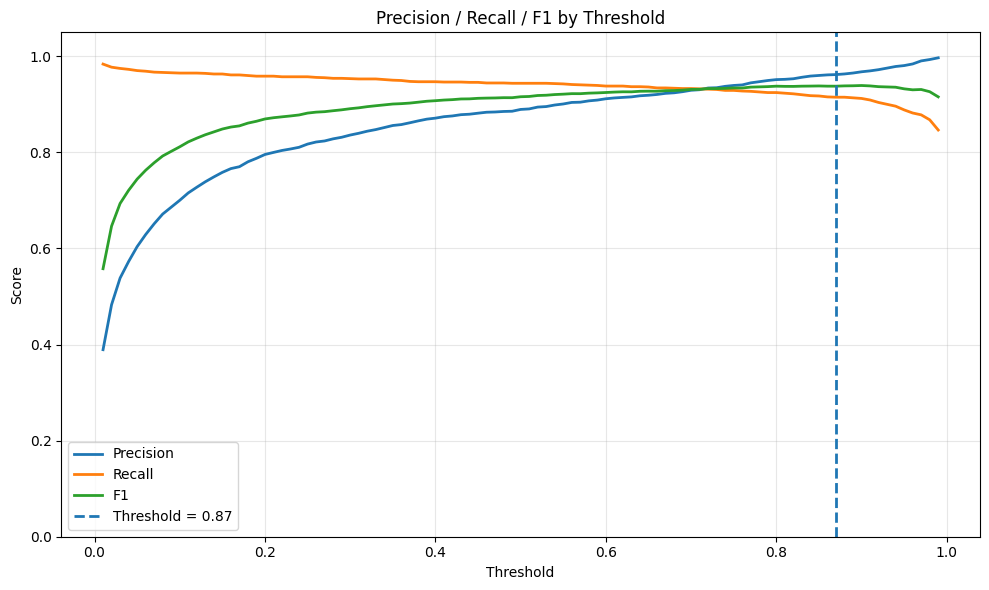

In [ ]:
# ============================================================
# ④ Threshold에 따른 Precision / Recall 변화
# ============================================================

thresholds = np.linspace(
    0.01,
    0.99,
    99
)

precision_list = []
recall_list = []
f1_list = []

for threshold in thresholds:

    pred = (
        y_val_prob >= threshold
    ).astype(int)

    precision_list.append(
        precision_score(
            y_val,
            pred,
            zero_division=0
        )
    )

    recall_list.append(
        recall_score(
            y_val,
            pred,
            zero_division=0
        )
    )

    f1_list.append(
        f1_score(
            y_val,
            pred,
            zero_division=0
        )
    )


plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precision_list,
    linewidth=2,
    label="Precision"
)

plt.plot(
    thresholds,
    recall_list,
    linewidth=2,
    label="Recall"
)

plt.plot(
    thresholds,
    f1_list,
    linewidth=2,
    label="F1"
)

# 현재 Threshold 표시
plt.axvline(
    THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {THRESHOLD}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 by Threshold")

plt.ylim(0, 1.05)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 최종 Validation 성능 평가
# Threshold = 0.87
# ============================================================

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

THRESHOLD = 0.87

# ------------------------------------------------------------
# 1. Validation 예측 확률
# ------------------------------------------------------------

y_val_prob = final_reduced_model.predict_proba(
    X_val_reduced
)[:, 1]


# ------------------------------------------------------------
# 2. Threshold 적용
# ------------------------------------------------------------

y_val_pred = (
    y_val_prob >= THRESHOLD
).astype(int)


# ------------------------------------------------------------
# 3. 성능 지표 계산
# ------------------------------------------------------------

pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

roc_auc = roc_auc_score(
    y_val,
    y_val_prob
)

precision = precision_score(
    y_val,
    y_val_pred
)

recall = recall_score(
    y_val,
    y_val_pred
)

f1 = f1_score(
    y_val,
    y_val_pred
)

accuracy = accuracy_score(
    y_val,
    y_val_pred
)

cm = confusion_matrix(
    y_val,
    y_val_pred
)


# ------------------------------------------------------------
# 4. 결과 출력
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("           ★ 최종 Validation 성능 ★")
print("=" * 55)

print(f"변수 수       : {X_val_reduced.shape[1]}")
print(f"Threshold     : {THRESHOLD}")
print(f"Best iteration: {final_reduced_model.best_iteration}")

print("\n---------------- 성능 지표 ----------------")

print(f"PR-AUC        : {pr_auc:.4f}")
print(f"ROC-AUC       : {roc_auc:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"Accuracy      : {accuracy:.4f}")

print("\n---------------- Confusion Matrix ----------------")

print(cm)

print("\nTN :", cm[0, 0])
print("FP :", cm[0, 1])
print("FN :", cm[1, 0])
print("TP :", cm[1, 1])

print("=" * 55)


           ★ 최종 Validation 성능 ★
변수 수       : 34
Threshold     : 0.87
Best iteration: 1757

---------------- 성능 지표 ----------------
PR-AUC        : 0.9719
ROC-AUC       : 0.9994
Precision     : 0.9621
Recall        : 0.9149
F1 Score      : 0.9379
Accuracy      : 0.9993

---------------- Confusion Matrix ----------------
[[257727     56]
 [   132   1420]]

TN : 257727
FP : 56
FN : 132
TP : 1420


In [ ]:
############################################shap사용###################################

In [ ]:
# ============================================================
# SHAP 분석용 Validation 샘플
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP_SAMPLE_SIZE = 10000

X_val_shap = X_val_reduced.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_val_reduced)),
    random_state=42
)

print("\n============================================")
print("        SHAP 분석 데이터")
print("============================================")
print("전체 Validation :", X_val_reduced.shape)
print("SHAP 분석용     :", X_val_shap.shape)


# ============================================================
# TreeExplainer
# ============================================================

explainer = shap.TreeExplainer(
    final_reduced_model
)

print("\nExplainer 생성 완료")


# ============================================================
# SHAP 계산
# ============================================================

shap_values = explainer.shap_values(
    X_val_shap
)

print("\n============================================")
print("           SHAP 계산 완료")
print("============================================")
print("SHAP shape :", shap_values.shape)
print("X shape    :", X_val_shap.shape)

SHAP version: 0.52.0

        SHAP 분석 데이터
전체 Validation : (259335, 34)
SHAP 분석용     : (10000, 34)


NotFittedError: need to call fit or load_model beforehand

In [ ]:
# ============================================================
# 3. 이상거래 탐지 6개 패턴 정의
# ============================================================

patterns = {

    "Pattern 1. 고객 기준 대비 비정상 고액 거래": [
        "amt",
        "customer_mean_amt",
        "amt_ratio_to_mean",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "amt_to_prior_median_ratio"
    ],

    "Pattern 2. 단시간 반복 및 집중 거래": [
        "rolling_sum_amt_1h",
        "recent_24h_high_amt_count"
    ],

    "Pattern 3. 고객 정상 활동 시간 이탈": [
        "trans_hour",
        "risk_time_22_04",
        "outside_trans_hours_80"
    ],

    "Pattern 4. 비정상 이동 패턴": [
        "speed_2"
    ],

    "Pattern 5. 위험 업종 및 복합 행동": [
        "category_recent_fraud_rate",
        "category_recent_fraud_rate_missing",
        "interact_repeat_category",
        "recent_24h_high_amt_count",

        # Category One-Hot
        "category_food_dining",
        "category_gas_transport",
        "category_grocery_net",
        "category_grocery_pos",
        "category_health_fitness",
        "category_home",
        "category_kids_pets",
        "category_misc_net",
        "category_misc_pos",
        "category_personal_care",
        "category_shopping_net",
        "category_shopping_pos",
        "category_travel"
    ],

    "Pattern 6. 온라인 카드 도용 패턴": [
        "is_online",
        "is_high_amt",
        "merchant_change_count"
    ]
}

In [ ]:
# ============================================================
# 4. Pattern별 SHAP 기여도
# ============================================================

pattern_results = []

for pattern_name, features in patterns.items():

    # 현재 모델에 실제 존재하는 변수만 사용
    valid_features = [
        f for f in features
        if f in X_val_shap.columns
    ]

    if len(valid_features) == 0:
        continue

    # 해당 변수들의 column index
    indices = [
        X_val_shap.columns.get_loc(f)
        for f in valid_features
    ]

    # 해당 Pattern의 SHAP 절댓값 합
    pattern_shap = np.abs(
        shap_values[:, indices]
    ).sum(axis=1)

    pattern_results.append({
        "Pattern": pattern_name,
        "변수수": len(valid_features),
        "평균_SHAP": pattern_shap.mean()
    })


pattern_df = pd.DataFrame(pattern_results)

# 전체 SHAP 기여도
total_shap = np.abs(shap_values).sum(axis=1).mean()

# 전체 대비 비중
pattern_df["전체_SHAP_대비_비중(%)"] = (
    pattern_df["평균_SHAP"]
    / total_shap
    * 100
)

pattern_df = pattern_df.sort_values(
    "평균_SHAP",
    ascending=False
).reset_index(drop=True)


print("\n============================================")
print("        ★ Pattern별 SHAP 기여도")
print("============================================")

print(
    pattern_df.to_string(
        index=False,
        formatters={
            "평균_SHAP": "{:.6f}".format,
            "전체_SHAP_대비_비중(%)": "{:.2f}%".format
        }
    )
)


        ★ Pattern별 SHAP 기여도
                      Pattern  변수수  평균_SHAP 전체_SHAP_대비_비중(%)
Pattern 1. 고객 기준 대비 비정상 고액 거래    6 6.387080           38.16%
     Pattern 5. 위험 업종 및 복합 행동   17 3.783061           22.60%
    Pattern 2. 단시간 반복 및 집중 거래    2 3.237710           19.34%
    Pattern 3. 고객 정상 활동 시간 이탈    3 1.882806           11.25%
         Pattern 4. 비정상 이동 패턴    1 0.742771            4.44%
      Pattern 6. 온라인 카드 도용 패턴    3 0.049809            0.30%


In [ ]:
# ============================================================
# ★ SHAP 중요도 테이블 생성
# ============================================================

shap_importance = pd.DataFrame({
    "feature": X_val_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

print("\n============================================")
print("        ★ SHAP Feature Importance")
print("============================================")

print(
    shap_importance.to_string(
        index=False,
        formatters={
            "mean_abs_shap": "{:.6f}".format
        }
    )
)


        ★ SHAP Feature Importance
                           feature mean_abs_shap
                               amt      2.962931
                rolling_sum_amt_1h      2.221283
                   risk_time_22_04      1.171524
         recent_24h_high_amt_count      1.016425
        customer_transaction_count      0.915688
           prior_normal_median_amt      0.847264
         amt_to_prior_median_ratio      0.808659
                           speed_2      0.742770
                               age      0.736492
                 customer_mean_amt      0.685704
                        trans_hour      0.661221
        category_recent_fraud_rate      0.587141
                 amt_ratio_to_mean      0.562047
                   amt_zscore_card      0.520475
            category_gas_transport      0.304878
          interact_repeat_category      0.288740
             category_shopping_pos      0.262086
              category_food_dining      0.170929
                 category_misc_net

In [ ]:
# ============================================================
# 5. Pattern 내부 변수별 SHAP 중요도
# ============================================================

for pattern_name, features in patterns.items():

    valid_features = [
        f for f in features
        if f in X_val_shap.columns
    ]

    if len(valid_features) == 0:
        continue

    result = shap_importance[
        shap_importance["feature"].isin(valid_features)
    ].copy()

    result = result.sort_values(
        "mean_abs_shap",
        ascending=False
    )

    print("\n" + "=" * 75)
    print(pattern_name)
    print("=" * 75)

    print(
        result.to_string(
            index=False,
            formatters={
                "mean_abs_shap": "{:.6f}".format
            }
        )
    )


Pattern 1. 고객 기준 대비 비정상 고액 거래
                  feature mean_abs_shap
                      amt      2.962931
  prior_normal_median_amt      0.847264
amt_to_prior_median_ratio      0.808659
        customer_mean_amt      0.685704
        amt_ratio_to_mean      0.562047
          amt_zscore_card      0.520475

Pattern 2. 단시간 반복 및 집중 거래
                  feature mean_abs_shap
       rolling_sum_amt_1h      2.221283
recent_24h_high_amt_count      1.016425

Pattern 3. 고객 정상 활동 시간 이탈
               feature mean_abs_shap
       risk_time_22_04      1.171524
            trans_hour      0.661221
outside_trans_hours_80      0.050065

Pattern 4. 비정상 이동 패턴
feature mean_abs_shap
speed_2      0.742770

Pattern 5. 위험 업종 및 복합 행동
                           feature mean_abs_shap
         recent_24h_high_amt_count      1.016425
        category_recent_fraud_rate      0.587141
            category_gas_transport      0.304878
          interact_repeat_category      0.288740
             category_shopping

In [ ]:
########################################제거대상후본변수들 오탐최적화인가 여부 확인 ###############33

In [ ]:
# ============================================================
# ★ 제거 후보 변수의 정상거래(오탐 방지) 영향 분석
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. 제거 후보 변수
# ------------------------------------------------------------

candidate_features = [
    "category_recent_fraud_rate_missing",
    "merchant_change_count",
    "is_high_amt",
    "outside_trans_hours_80",
    "is_online"
]

# ------------------------------------------------------------
# 2. SHAP 분석 샘플에 대응하는 y값
# ------------------------------------------------------------

y_val_shap = y_val.loc[X_val_shap.index]

# 정상거래만 선택
normal_mask = (y_val_shap.values == 0)

print("\n============================================")
print("★ 정상거래 SHAP 분석")
print("============================================")

print("전체 SHAP 샘플 :", len(X_val_shap))
print("정상거래      :", normal_mask.sum())
print("사기거래      :", (~normal_mask).sum())


# ------------------------------------------------------------
# 3. 변수별 정상거래 SHAP 분석
# ------------------------------------------------------------

normal_results = []

for feature in candidate_features:

    if feature not in X_val_shap.columns:
        print(f"⚠️ {feature} : X_val_shap에 없음")
        continue

    feature_idx = X_val_shap.columns.get_loc(feature)

    # 해당 변수의 정상거래 SHAP
    normal_shap = shap_values[normal_mask, feature_idx]

    # 절대값 SHAP
    normal_abs_shap = np.abs(normal_shap)

    # 양수 SHAP = 사기 방향
    positive_ratio = (normal_shap > 0).mean() * 100

    # 음수 SHAP = 정상 방향
    negative_ratio = (normal_shap < 0).mean() * 100

    # 평균 SHAP
    mean_shap = normal_shap.mean()

    # 평균 절대 SHAP
    mean_abs_shap = normal_abs_shap.mean()

    # 사기 방향으로 작용한 평균 크기
    positive_mean = (
        normal_shap[normal_shap > 0].mean()
        if (normal_shap > 0).any()
        else 0
    )

    # 정상 방향으로 작용한 평균 크기
    negative_mean = (
        normal_shap[normal_shap < 0].mean()
        if (normal_shap < 0).any()
        else 0
    )

    normal_results.append({
        "feature": feature,
        "mean_SHAP": mean_shap,
        "mean_abs_SHAP": mean_abs_shap,
        "정상방향_SHAP비율(%)": negative_ratio,
        "사기방향_SHAP비율(%)": positive_ratio,
        "정상방향_평균SHAP": negative_mean,
        "사기방향_평균SHAP": positive_mean
    })


normal_shap_df = pd.DataFrame(normal_results)

# 평균 SHAP 기준으로 정렬
normal_shap_df = normal_shap_df.sort_values(
    "mean_abs_SHAP",
    ascending=False
).reset_index(drop=True)


print("\n============================================")
print("★ 제거 후보 변수 - 정상거래 SHAP 결과")
print("============================================")

print(
    normal_shap_df.to_string(
        index=False,
        formatters={
            "mean_SHAP": "{:.6f}".format,
            "mean_abs_SHAP": "{:.6f}".format,
            "정상방향_SHAP비율(%)": "{:.2f}".format,
            "사기방향_SHAP비율(%)": "{:.2f}".format,
            "정상방향_평균SHAP": "{:.6f}".format,
            "사기방향_평균SHAP": "{:.6f}".format
        }
    )
)


★ 정상거래 SHAP 분석
전체 SHAP 샘플 : 10000
정상거래      : 9930
사기거래      : 70


NameError: name 'shap_values' is not defined

In [ ]:
#####################################오탐 찾기###########################################

In [ ]:
# ============================================================
# ★ Validation 전체에서 False Positive 찾기
# ============================================================

THRESHOLD = 0.87

# Validation 전체 예측확률
val_pred_prob = final_reduced_model.predict_proba(
    X_val_reduced
)[:, 1]

# 예측
val_pred = (val_pred_prob >= THRESHOLD).astype(int)

# False Positive
fp_mask_full = (
    (y_val.values == 0) &
    (val_pred == 1)
)

print("\n============================================")
print("★ Validation False Positive")
print("============================================")

print("Validation 전체 :", len(X_val_reduced))
print("정상거래        :", (y_val == 0).sum())
print("실제 사기       :", (y_val == 1).sum())
print("False Positive  :", fp_mask_full.sum())

print("\nThreshold :", THRESHOLD)


★ Validation False Positive
Validation 전체 : 259335
정상거래        : 257783
실제 사기       : 1552
False Positive  : 56

Threshold : 0.87


In [ ]:
# ============================================================
# ★ False Positive 거래 추출
# ============================================================

X_fp = X_val_reduced.loc[fp_mask_full].copy()

print("\nFP 데이터 shape :", X_fp.shape)


FP 데이터 shape : (56, 34)


In [ ]:
# ============================================================
# ★ False Positive 전용 SHAP
# ============================================================

shap_values_fp = explainer.shap_values(
    X_fp
)

print("\n============================================")
print("★ False Positive SHAP 계산 완료")
print("============================================")

print("FP 데이터 :", X_fp.shape)
print("SHAP shape:", shap_values_fp.shape)


★ False Positive SHAP 계산 완료
FP 데이터 : (56, 34)
SHAP shape: (56, 34)


In [ ]:
# ============================================================
# ★ 제거 후보 변수의 FP SHAP 분석
# ============================================================

candidate_features = [
    "category_recent_fraud_rate_missing",
    "merchant_change_count",
    "is_high_amt",
    "outside_trans_hours_80",
    "is_online"
]

fp_results = []

for feature in candidate_features:

    if feature not in X_fp.columns:
        continue

    feature_idx = X_fp.columns.get_loc(feature)

    feature_shap = shap_values_fp[:, feature_idx]

    fp_results.append({
        "feature": feature,
        "평균_SHAP": feature_shap.mean(),
        "평균_abs_SHAP": np.abs(feature_shap).mean(),
        "사기방향비율(%)": (feature_shap > 0).mean() * 100,
        "정상방향비율(%)": (feature_shap < 0).mean() * 100
    })


fp_shap_df = pd.DataFrame(fp_results)

# ============================================================
# ★ 빈 결과 방지
# ============================================================

if len(fp_shap_df) == 0:

    print("\n⚠️ 분석 가능한 FP 변수가 없습니다.")

else:

    fp_shap_df = fp_shap_df.sort_values(
        "평균_abs_SHAP",
        ascending=False
    ).reset_index(drop=True)

    print("\n============================================")
    print("★ False Positive 거래에서 제거 후보 변수 영향")
    print("============================================")

    print(
        fp_shap_df.to_string(
            index=False,
            formatters={
                "평균_SHAP": "{:.6f}".format,
                "평균_abs_SHAP": "{:.6f}".format,
                "사기방향비율(%)": "{:.2f}".format,
                "정상방향비율(%)": "{:.2f}".format
            }
        )
    )


★ False Positive 거래에서 제거 후보 변수 영향
                           feature   평균_SHAP 평균_abs_SHAP 사기방향비율(%) 정상방향비율(%)
            outside_trans_hours_80 -0.022429    0.061248     46.43     53.57
                         is_online -0.010956    0.042080     64.29     35.71
                       is_high_amt  0.003106    0.019578     37.50     62.50
             merchant_change_count -0.001399    0.001399      0.00    100.00
category_recent_fraud_rate_missing  0.000000    0.000000      0.00      0.00


In [ ]:
########################################변수제거 후 다시 모델학습 #################

In [ ]:
# ============================================================
# ★ 32개 변수 모델
# 제거 변수:
# 1. category_recent_fraud_rate_missing
# 2. merchant_change_count
# ============================================================

import numpy as np
import pandas as pd
from xgboost import XGBClassifier


# ============================================================
# 1. 제거할 변수 지정
# ============================================================

remove_features = [
    "category_recent_fraud_rate_missing",
    "merchant_change_count"
]

print("\n============================================")
print("★ 변수 제거")
print("============================================")

print("제거 변수:")
for feature in remove_features:
    print(" -", feature)


# ============================================================
# 2. 34개 → 32개 변수
# ============================================================

X_32 = X.drop(
    columns=remove_features
).copy()

print("\n기존 변수 개수 :", X.shape[1])
print("제거 후 변수 개수 :", X_32.shape[1])

print("\n제거 후 변수 목록")
for i, feature in enumerate(X_32.columns, 1):
    print(f"{i:2d}. {feature}")


# ============================================================
# 3. 시간 순서 기준 Train / Validation 분할
# ============================================================

split_idx = int(len(X_32) * 0.8)

X_train_32 = X_32.iloc[:split_idx].copy()
X_val_32 = X_32.iloc[split_idx:].copy()

y_train_32 = y.iloc[:split_idx].copy()
y_val_32 = y.iloc[split_idx:].copy()


print("\n============================================")
print("★ Train / Validation 분할")
print("============================================")

print("X_train :", X_train_32.shape)
print("X_val   :", X_val_32.shape)
print("y_train :", y_train_32.shape)
print("y_val   :", y_val_32.shape)


# ============================================================
# 4. 클래스 불균형 가중치
# ============================================================

scale_pos_weight_32 = (
    (y_train_32 == 0).sum() /
    (y_train_32 == 1).sum()
)

print("\n============================================")
print("★ 클래스 불균형 가중치")
print("============================================")

print("scale_pos_weight :", scale_pos_weight_32)


# ============================================================
# 5. 32개 변수 XGBoost 모델
# 기존 34개 모델과 동일한 설정
# ============================================================

final_32_model = XGBClassifier(

    # Early Stopping
    n_estimators=3000,

    # 하이퍼파라미터
    max_depth=6,
    min_child_weight=1,

    learning_rate=0.03,

    subsample=0.7,
    colsample_bytree=0.8,

    gamma=0.1,

    reg_alpha=0.5,
    reg_lambda=5,

    # 클래스 불균형
    scale_pos_weight=scale_pos_weight_32,

    # 목적함수
    objective="binary:logistic",

    # 이상거래 탐지
    eval_metric="aucpr",

    random_state=42,

    tree_method="hist",

    # Early Stopping
    early_stopping_rounds=60
)


# ============================================================
# 6. 모델 학습
# ============================================================

print("\n============================================")
print("★ 32개 변수 XGBoost 모델 학습 시작")
print("============================================")

final_32_model.fit(
    X_train_32,
    y_train_32,

    eval_set=[
        (X_val_32, y_val_32)
    ],

    verbose=100
)


# ============================================================
# 7. Early Stopping 결과
# ============================================================

print("\n============================================")
print("★ 32개 변수 모델 학습 완료")
print("============================================")

print("Best iteration :", final_32_model.best_iteration)
print("Best validation PR-AUC :", final_32_model.best_score)


★ 변수 제거
제거 변수:
 - category_recent_fraud_rate_missing
 - merchant_change_count

기존 변수 개수 : 34
제거 후 변수 개수 : 32

제거 후 변수 목록
 1. amt
 2. is_online
 3. is_high_amt
 4. trans_hour
 5. risk_time_22_04
 6. rolling_sum_amt_1h
 7. speed_2
 8. customer_mean_amt
 9. amt_ratio_to_mean
10. amt_zscore_card
11. customer_transaction_count
12. category_recent_fraud_rate
13. recent_24h_high_amt_count
14. interact_repeat_category
15. has_prior_normal_transaction
16. outside_trans_hours_80
17. prior_normal_median_amt
18. amt_to_prior_median_ratio
19. age
20. category_food_dining
21. category_gas_transport
22. category_grocery_net
23. category_grocery_pos
24. category_health_fitness
25. category_home
26. category_kids_pets
27. category_misc_net
28. category_misc_pos
29. category_personal_care
30. category_shopping_net
31. category_shopping_pos
32. category_travel

★ Train / Validation 분할
X_train : (1037340, 32)
X_val   : (259335, 32)
y_train : (1037340,)
y_val   : (259335,)

★ 클래스 불균형 가중치
scale_pos_weight 

In [ ]:
# ============================================================
# ★ 32개 변수 모델 평가
# Threshold = 0.87
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

THRESHOLD = 0.87

# ------------------------------------------------------------
# 1. Validation 예측확률
# ------------------------------------------------------------

y_val_prob_32 = final_32_model.predict_proba(
    X_val_32
)[:, 1]

# ------------------------------------------------------------
# 2. Threshold 0.87 적용
# ------------------------------------------------------------

y_val_pred_32 = (
    y_val_prob_32 >= THRESHOLD
).astype(int)


# ------------------------------------------------------------
# 3. 성능 평가
# ------------------------------------------------------------

accuracy_32 = accuracy_score(
    y_val_32,
    y_val_pred_32
)

precision_32 = precision_score(
    y_val_32,
    y_val_pred_32,
    zero_division=0
)

recall_32 = recall_score(
    y_val_32,
    y_val_pred_32,
    zero_division=0
)

f1_32 = f1_score(
    y_val_32,
    y_val_pred_32,
    zero_division=0
)

roc_auc_32 = roc_auc_score(
    y_val_32,
    y_val_prob_32
)

pr_auc_32 = average_precision_score(
    y_val_32,
    y_val_prob_32
)

cm_32 = confusion_matrix(
    y_val_32,
    y_val_pred_32
)

tn_32, fp_32, fn_32, tp_32 = cm_32.ravel()


# ============================================================
# 결과 출력
# ============================================================

print("\n============================================")
print("★ 32개 변수 XGBoost 최종 평가")
print("============================================")

print("Threshold :", THRESHOLD)

print("\nAccuracy  :", accuracy_32)
print("Precision :", precision_32)
print("Recall    :", recall_32)
print("F1 Score  :", f1_32)
print("ROC-AUC   :", roc_auc_32)
print("PR-AUC    :", pr_auc_32)

print("\n============================================")
print("★ Confusion Matrix")
print("============================================")

print(cm_32)

print("\nTN :", tn_32)
print("FP :", fp_32)
print("FN :", fn_32)
print("TP :", tp_32)


★ 32개 변수 XGBoost 최종 평가
Threshold : 0.87

Accuracy  : 0.9992442207954961
Precision : 0.9550335570469799
Recall    : 0.916881443298969
F1 Score  : 0.9355687047994741
ROC-AUC   : 0.9993839969932355
PR-AUC    : 0.9713352689589888

★ Confusion Matrix
[[257716     67]
 [   129   1423]]

TN : 257716
FP : 67
FN : 129
TP : 1423


In [ ]:
######################카테고리원핫코딩세부분석########################

In [ ]:
# ============================================================
# ★ 카테고리 원핫 변수 SHAP + FP 분석
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. 카테고리 원핫 변수 목록
# ------------------------------------------------------------

category_features = [
    "category_food_dining",
    "category_gas_transport",
    "category_grocery_net",
    "category_grocery_pos",
    "category_health_fitness",
    "category_home",
    "category_kids_pets",
    "category_misc_net",
    "category_misc_pos",
    "category_personal_care",
    "category_shopping_net",
    "category_shopping_pos",
    "category_travel"
]

# 실제 X_32에 존재하는 변수만 사용
category_features = [
    f for f in category_features
    if f in X_32.columns
]

print("카테고리 변수 수 :", len(category_features))
print(category_features)


# ============================================================
# 2. 32개 모델 Validation SHAP 계산
# ============================================================

explainer_32 = shap.TreeExplainer(
    final_32_model
)

shap_values_32 = explainer_32.shap_values(
    X_val_32
)

print("\nSHAP shape :", shap_values_32.shape)


# ============================================================
# 3. Validation 전체 카테고리 SHAP
# ============================================================

category_results = []

for feature in category_features:

    idx = X_val_32.columns.get_loc(feature)

    values = shap_values_32[:, idx]

    category_results.append({
        "feature": feature,
        "평균_SHAP": values.mean(),
        "평균_abs_SHAP": np.abs(values).mean(),
        "사기방향비율(%)": (values > 0).mean() * 100,
        "정상방향비율(%)": (values < 0).mean() * 100
    })


category_shap_df = pd.DataFrame(category_results)

category_shap_df = category_shap_df.sort_values(
    "평균_abs_SHAP",
    ascending=False
).reset_index(drop=True)


print("\n============================================")
print("★ 카테고리 원핫 변수 전체 SHAP")
print("============================================")

print(
    category_shap_df.to_string(
        index=False,
        formatters={
            "평균_SHAP": "{:.6f}".format,
            "평균_abs_SHAP": "{:.6f}".format,
            "사기방향비율(%)": "{:.2f}".format,
            "정상방향비율(%)": "{:.2f}".format
        }
    )
)

카테고리 변수 수 : 13
['category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']

SHAP shape : (259335, 32)

★ 카테고리 원핫 변수 전체 SHAP
                feature   평균_SHAP 평균_abs_SHAP 사기방향비율(%) 정상방향비율(%)
 category_gas_transport -0.186859    0.328292      9.78     90.22
  category_shopping_pos -0.103493    0.272266     90.82      9.18
   category_food_dining -0.146122    0.163912     16.47     83.53
      category_misc_net  0.004904    0.153527     95.09      4.91
          category_home -0.132479    0.153152     50.98     49.02
   category_grocery_net -0.113147    0.140481      3.64     96.36
  category_shopping_net -0.056688    0.139176     92.12      7.88
      category_misc_pos -0.100615    0.118017     12.81     87.19
   category_grocery_pos -0.055275    0.1

In [ ]:
# ============================================================
# ★ False Positive 추출
# ============================================================

THRESHOLD = 0.87

y_val_prob_32 = final_32_model.predict_proba(
    X_val_32
)[:, 1]

y_val_pred_32 = (
    y_val_prob_32 >= THRESHOLD
).astype(int)

fp_mask_32 = (
    (y_val_32.values == 0) &
    (y_val_pred_32 == 1)
)

X_fp_32 = X_val_32.loc[fp_mask_32].copy()

print("\n============================================")
print("★ False Positive")
print("============================================")

print("FP 수 :", len(X_fp_32))


★ False Positive
FP 수 : 67


In [ ]:
# ============================================================
# ★ 카테고리 원핫 변수의 FP SHAP
# ============================================================

shap_values_fp_32 = explainer_32.shap_values(
    X_fp_32
)

fp_category_results = []

for feature in category_features:

    idx = X_fp_32.columns.get_loc(feature)

    values = shap_values_fp_32[:, idx]

    fp_category_results.append({
        "feature": feature,
        "FP_평균_SHAP": values.mean(),
        "FP_평균_abs_SHAP": np.abs(values).mean(),
        "FP_사기방향비율(%)": (values > 0).mean() * 100,
        "FP_정상방향비율(%)": (values < 0).mean() * 100
    })


fp_category_shap_df = pd.DataFrame(
    fp_category_results
)

fp_category_shap_df = fp_category_shap_df.sort_values(
    "FP_평균_abs_SHAP",
    ascending=False
).reset_index(drop=True)


print("\n============================================")
print("★ 카테고리 원핫 변수 - False Positive SHAP")
print("============================================")

print(
    fp_category_shap_df.to_string(
        index=False,
        formatters={
            "FP_평균_SHAP": "{:.6f}".format,
            "FP_평균_abs_SHAP": "{:.6f}".format,
            "FP_사기방향비율(%)": "{:.2f}".format,
            "FP_정상방향비율(%)": "{:.2f}".format
        }
    )
)


★ 카테고리 원핫 변수 - False Positive SHAP
                feature FP_평균_SHAP FP_평균_abs_SHAP FP_사기방향비율(%) FP_정상방향비율(%)
 category_gas_transport   0.614052       0.939955        13.43        86.57
   category_grocery_net   0.141269       0.275331         5.97        94.03
   category_grocery_pos  -0.045255       0.255803         5.97        94.03
      category_misc_net  -0.061531       0.214538        89.55        10.45
  category_shopping_pos  -0.018375       0.206946        91.04         8.96
  category_shopping_net  -0.044755       0.125198        74.63        25.37
      category_misc_pos  -0.039555       0.078042        58.21        41.79
        category_travel  -0.018625       0.070346        53.73        46.27
          category_home  -0.007447       0.065294        55.22        44.78
   category_food_dining  -0.005357       0.058515        29.85        70.15
category_health_fitness  -0.035180       0.058155        61.19        38.81
 category_personal_care   0.015818       0.054987   

In [ ]:
# ============================================================
# ★ FP 카테고리별 거래 건수 + FP 비율 + 평균 SHAP
# ============================================================

import numpy as np
import pandas as pd

THRESHOLD = 0.87


# ============================================================
# 1. Validation 예측
# ============================================================

y_val_prob_32 = final_32_model.predict_proba(
    X_val_32
)[:, 1]

y_val_pred_32 = (
    y_val_prob_32 >= THRESHOLD
).astype(int)


# ============================================================
# 2. False Positive 추출
# ============================================================

fp_mask = (
    (y_val_32.values == 0) &
    (y_val_pred_32 == 1)
)

X_fp = X_val_32.loc[fp_mask].copy()

print("============================================")
print("★ False Positive")
print("============================================")
print("FP 수 :", len(X_fp))


# ============================================================
# 3. 카테고리 원핫 변수
# ============================================================

category_features = [
    "category_food_dining",
    "category_gas_transport",
    "category_grocery_net",
    "category_grocery_pos",
    "category_health_fitness",
    "category_home",
    "category_kids_pets",
    "category_misc_net",
    "category_misc_pos",
    "category_personal_care",
    "category_shopping_net",
    "category_shopping_pos",
    "category_travel"
]

category_features = [
    f for f in category_features
    if f in X_val_32.columns
]


# ============================================================
# 4. SHAP 계산
# ============================================================

explainer_32 = shap.TreeExplainer(
    final_32_model
)

shap_values_fp = explainer_32.shap_values(
    X_fp
)


# ============================================================
# 5. 카테고리별 분석
# ============================================================

results = []

total_fp = len(X_fp)

for feature in category_features:

    idx = X_fp.columns.get_loc(feature)

    # 해당 카테고리 거래만 추출
    category_mask = X_fp[feature] == 1

    category_count = category_mask.sum()

    # FP 전체에서 해당 카테고리가 차지하는 비율
    fp_ratio = (
        category_count / total_fp * 100
        if total_fp > 0
        else 0
    )

    # 해당 카테고리 거래의 SHAP
    category_shap = shap_values_fp[
        category_mask.values,
        idx
    ]

    if len(category_shap) > 0:

        mean_shap = category_shap.mean()
        mean_abs_shap = np.abs(category_shap).mean()

    else:

        mean_shap = 0
        mean_abs_shap = 0


    results.append({

        "category": feature,

        "FP_거래수": category_count,

        "FP_비율(%)": fp_ratio,

        "FP_평균_SHAP": mean_shap,

        "FP_평균_abs_SHAP": mean_abs_shap
    })


# ============================================================
# 6. 결과 DataFrame
# ============================================================

fp_category_summary = pd.DataFrame(results)


# FP 거래가 많은 순서
fp_category_summary = fp_category_summary.sort_values(
    "FP_거래수",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 7. 결과 출력
# ============================================================

print("\n============================================")
print("★ FP 카테고리별 분석")
print("============================================")

print(
    fp_category_summary.to_string(
        index=False,
        formatters={
            "FP_비율(%)": "{:.2f}".format,
            "FP_평균_SHAP": "{:.6f}".format,
            "FP_평균_abs_SHAP": "{:.6f}".format
        }
    )
)

★ False Positive
FP 수 : 67

★ FP 카테고리별 분석
               category  FP_거래수 FP_비율(%) FP_평균_SHAP FP_평균_abs_SHAP
 category_gas_transport       9    13.43   5.784362       5.784362
  category_shopping_net       9    13.43  -0.596443       0.596443
      category_misc_net       7    10.45  -1.321187       1.321187
 category_personal_care       7    10.45   0.196962       0.268936
  category_shopping_pos       6     8.96  -1.258040       1.258040
     category_kids_pets       5     7.46  -0.248632       0.299862
   category_grocery_net       4     5.97   3.489022       3.489022
   category_grocery_pos       3     4.48   2.349232       2.349232
category_health_fitness       3     4.48  -0.717677       0.717677
   category_food_dining       2     2.99   0.784813       0.784813
          category_home       2     2.99   0.274468       0.274468
      category_misc_pos       2     2.99  -0.872796       0.872796
        category_travel       2     2.99  -0.929683       0.929683


In [ ]:
# ============================================================
# ★ FP 67건 개별 거래 SHAP 분석
# 32개 변수 모델 / Threshold = 0.87
# ============================================================

import shap
import numpy as np
import pandas as pd

THRESHOLD = 0.87

# ============================================================
# 1. Validation 예측확률
# ============================================================

y_val_prob = final_32_model.predict_proba(
    X_val_32
)[:, 1]

y_val_pred = (
    y_val_prob >= THRESHOLD
).astype(int)


# ============================================================
# 2. False Positive 추출
# ============================================================

fp_mask = (
    (y_val_32.values == 0) &
    (y_val_pred == 1)
)

X_fp = X_val_32.loc[fp_mask].copy()

fp_prob = y_val_prob[fp_mask]

print("============================================")
print("★ False Positive 분석")
print("============================================")
print("Threshold :", THRESHOLD)
print("FP 수     :", len(X_fp))


# ============================================================
# 3. SHAP 계산
# ============================================================

explainer_32 = shap.TreeExplainer(
    final_32_model
)

shap_values_fp = explainer_32.shap_values(
    X_fp
)

print("SHAP shape :", shap_values_fp.shape)


# ============================================================
# 4. 각 FP 거래별 Top 5 사기 방향 변수
# ============================================================

fp_transaction_results = []

feature_names = X_fp.columns.tolist()

for i in range(len(X_fp)):

    shap_row = shap_values_fp[i]

    # --------------------------------------------------------
    # 양수 SHAP = 사기 방향
    # --------------------------------------------------------

    positive_idx = np.where(shap_row > 0)[0]

    # 사기 방향 영향력이 큰 순서
    positive_idx = positive_idx[
        np.argsort(
            shap_row[positive_idx]
        )[::-1]
    ]

    # Top 5
    top_idx = positive_idx[:5]

    top_features = []

    for idx in top_idx:

        feature = feature_names[idx]

        shap_value = shap_row[idx]

        feature_value = X_fp.iloc[i, idx]

        top_features.append(
            f"{feature}={feature_value:.3f} "
            f"(SHAP={shap_value:+.3f})"
        )

    # --------------------------------------------------------
    # 가장 강한 사기 방향 변수
    # --------------------------------------------------------

    if len(top_features) == 0:
        top_features = ["없음"]

    fp_transaction_results.append({

        "거래번호": X_fp.index[i],

        "예측확률": fp_prob[i],

        "Top1": top_features[0]
            if len(top_features) > 0 else "",

        "Top2": top_features[1]
            if len(top_features) > 1 else "",

        "Top3": top_features[2]
            if len(top_features) > 2 else "",

        "Top4": top_features[3]
            if len(top_features) > 3 else "",

        "Top5": top_features[4]
            if len(top_features) > 4 else ""
    })


# ============================================================
# 5. DataFrame 생성
# ============================================================

fp_transaction_df = pd.DataFrame(
    fp_transaction_results
)


# ============================================================
# 6. 예측확률 높은 순서
# ============================================================

fp_transaction_df = fp_transaction_df.sort_values(
    "예측확률",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 7. 출력
# ============================================================

print("\n============================================")
print("★ FP 개별 거래별 SHAP Top 5")
print("============================================")

pd.set_option(
    "display.max_colwidth",
    150
)

print(
    fp_transaction_df.to_string(
        index=False
    )
)

★ False Positive 분석
Threshold : 0.87
FP 수     : 67
SHAP shape : (67, 32)

★ FP 개별 거래별 SHAP Top 5
   거래번호     예측확률                                          Top1                                              Top2                                          Top3                                             Top4                                             Top5
1109863 0.998569 recent_24h_high_amt_count=2.000 (SHAP=+7.047)               risk_time_22_04=1.000 (SHAP=+1.147)  interact_repeat_category=0.003 (SHAP=+1.095)                         amt=20.590 (SHAP=+0.829)       category_personal_care=1.000 (SHAP=+0.174)
1128173 0.997773     rolling_sum_amt_1h=1076.280 (SHAP=+3.918)      prior_normal_median_amt=75.630 (SHAP=+3.598)                    amt=1076.280 (SHAP=+2.225)              amt_zscore_card=8.097 (SHAP=+0.381)  customer_transaction_count=95.000 (SHAP=+0.337)
1042142 0.993564    category_gas_transport=1.000 (SHAP=+5.834)                          amt=21.920 (SHAP=+1.278)           risk_time

In [ ]:
# ============================================================
# ★ FP 67건에서 반복적으로 등장하는 사기방향 SHAP 변수
# ============================================================

top_feature_count = {}

TOP_N = 5

for i in range(len(X_fp)):

    shap_row = shap_values_fp[i]

    positive_idx = np.where(shap_row > 0)[0]

    positive_idx = positive_idx[
        np.argsort(
            shap_row[positive_idx]
        )[::-1]
    ]

    top_idx = positive_idx[:TOP_N]

    for idx in top_idx:

        feature = feature_names[idx]

        if feature not in top_feature_count:
            top_feature_count[feature] = 0

        top_feature_count[feature] += 1


fp_top_feature_df = pd.DataFrame(
    list(top_feature_count.items()),
    columns=[
        "feature",
        "FP에서_Top5_사기방향으로_등장한_횟수"
    ]
)

fp_top_feature_df = fp_top_feature_df.sort_values(
    "FP에서_Top5_사기방향으로_등장한_횟수",
    ascending=False
).reset_index(drop=True)


print("\n============================================")
print("★ FP 67건 주요 사기방향 변수")
print("============================================")

print(
    fp_top_feature_df.to_string(
        index=False
    )
)


★ FP 67건 주요 사기방향 변수
                   feature  FP에서_Top5_사기방향으로_등장한_횟수
           risk_time_22_04                       50
                       amt                       46
        rolling_sum_amt_1h                       37
 recent_24h_high_amt_count                       34
  interact_repeat_category                       30
                trans_hour                       20
         amt_ratio_to_mean                       16
                   speed_2                       15
     category_shopping_pos                       15
         category_misc_net                       11
customer_transaction_count                       10
    category_gas_transport                        9
   prior_normal_median_amt                        8
         customer_mean_amt                        5
 amt_to_prior_median_ratio                        5
           amt_zscore_card                        4
      category_grocery_net                        4
    category_personal_care                 

In [ ]:
# ============================================================
# ★ Threshold 변화에 따른 FP / FN / Precision / Recall
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

threshold_results = []

thresholds = [
    0.80,
    0.82,
    0.84,
    0.85,
    0.86,
    0.87,
    0.88,
    0.89,
    0.90,
    0.92,
    0.94,
    0.95
]

for threshold in thresholds:

    pred = (
        y_val_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_32,
        pred
    ).ravel()

    precision = precision_score(
        y_val_32,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_32,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_32,
        pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_val_32,
        pred
    )

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "FP": fp,

        "FN": fn,

        "TP": tp,

        "TN": tn
    })


threshold_df = pd.DataFrame(
    threshold_results
)


print("\n============================================")
print("★ Threshold 비교")
print("============================================")

print(
    threshold_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1": "{:.4f}".format
        }
    )
)


★ Threshold 비교
 Threshold Accuracy Precision Recall     F1  FP  FN   TP     TN
      0.80   0.9992    0.9381 0.9272 0.9326  95 113 1439 257688
      0.82   0.9992    0.9454 0.9253 0.9352  83 116 1436 257700
      0.84   0.9993    0.9509 0.9227 0.9366  74 120 1432 257709
      0.85   0.9993    0.9521 0.9214 0.9365  72 122 1430 257711
      0.86   0.9992    0.9532 0.9195 0.9360  70 125 1427 257713
      0.87   0.9992    0.9550 0.9169 0.9356  67 129 1423 257716
      0.88   0.9993    0.9575 0.9156 0.9361  63 131 1421 257720
      0.89   0.9992    0.9587 0.9130 0.9353  61 135 1417 257722
      0.90   0.9993    0.9613 0.9117 0.9358  57 137 1415 257726
      0.92   0.9992    0.9657 0.9066 0.9352  50 145 1407 257733
      0.94   0.9992    0.9728 0.8976 0.9336  39 159 1393 257744
      0.95   0.9992    0.9774 0.8924 0.9330  32 167 1385 257751


In [ ]:
##############찐막!!!!!!!!!!!!!!!!!!!!!변수제거 마지막 #################

In [ ]:
# ============================================================
# ★ is_high_amt 제거 → 31개 변수 XGBoost 모델
# ============================================================

# 제거할 변수
remove_feature = "is_high_amt"

# ------------------------------------------------------------
# 1. 변수 제거
# ------------------------------------------------------------

X_31 = X.drop(columns=[remove_feature]).copy()

print("\n============================================")
print("★ is_high_amt 제거")
print("============================================")
print("제거 변수 :", remove_feature)
print("기존 변수 수 :", X.shape[1])
print("현재 변수 수 :", X_31.shape[1])

print("\n현재 변수 목록")
for i, col in enumerate(X_31.columns, 1):
    print(f"{i}. {col}")


# ============================================================
# 2. Train / Validation 시간순 분할
# ============================================================

split_idx = int(len(X_31) * 0.8)

X_train_31 = X_31.iloc[:split_idx].copy()
X_val_31   = X_31.iloc[split_idx:].copy()

y_train_31 = y.iloc[:split_idx].copy()
y_val_31   = y.iloc[split_idx:].copy()

print("\n============================================")
print("★ Train / Validation 분할")
print("============================================")

print("X_train :", X_train_31.shape)
print("X_val   :", X_val_31.shape)
print("y_train :", y_train_31.shape)
print("y_val   :", y_val_31.shape)


# ============================================================
# 3. 클래스 불균형 가중치
# ============================================================

scale_pos_weight_31 = (
    (y_train_31 == 0).sum() /
    (y_train_31 == 1).sum()
)

print("\n============================================")
print("★ 클래스 불균형 가중치")
print("============================================")

print("scale_pos_weight :", scale_pos_weight_31)


# ============================================================
# 4. 31개 변수 XGBoost
#    기존 32개 모델과 동일한 조건
# ============================================================

final_31_model = XGBClassifier(

    # Early Stopping
    n_estimators=2000,

    # 하이퍼파라미터
    max_depth=6,
    min_child_weight=1,

    learning_rate=0.03,

    subsample=0.7,
    colsample_bytree=0.8,

    gamma=0.1,

    reg_alpha=0.5,
    reg_lambda=5,

    # 클래스 불균형
    scale_pos_weight=scale_pos_weight_31,

    # 목적함수
    objective="binary:logistic",

    # 이상거래 탐지 → PR-AUC
    eval_metric="aucpr",

    random_state=42,

    tree_method="hist",

    # Early Stopping
    early_stopping_rounds=60
)


# ============================================================
# 5. 모델 학습
# ============================================================

print("\n============================================")
print("★ 31개 변수 XGBoost 모델 학습 시작")
print("============================================")

final_31_model.fit(
    X_train_31,
    y_train_31,

    eval_set=[
        (X_val_31, y_val_31)
    ],

    verbose=100
)


# ============================================================
# 6. 학습 결과
# ============================================================

print("\n============================================")
print("★ 31개 변수 XGBoost 모델 학습 완료")
print("============================================")

print("Best iteration :", final_31_model.best_iteration)
print("Best validation PR-AUC :", final_31_model.best_score)


★ is_high_amt 제거
제거 변수 : is_high_amt
기존 변수 수 : 34
현재 변수 수 : 33

현재 변수 목록
1. amt
2. is_online
3. merchant_change_count
4. trans_hour
5. risk_time_22_04
6. rolling_sum_amt_1h
7. speed_2
8. customer_mean_amt
9. amt_ratio_to_mean
10. amt_zscore_card
11. customer_transaction_count
12. category_recent_fraud_rate
13. category_recent_fraud_rate_missing
14. recent_24h_high_amt_count
15. interact_repeat_category
16. has_prior_normal_transaction
17. outside_trans_hours_80
18. prior_normal_median_amt
19. amt_to_prior_median_ratio
20. age
21. category_food_dining
22. category_gas_transport
23. category_grocery_net
24. category_grocery_pos
25. category_health_fitness
26. category_home
27. category_kids_pets
28. category_misc_net
29. category_misc_pos
30. category_personal_care
31. category_shopping_net
32. category_shopping_pos
33. category_travel

★ Train / Validation 분할
X_train : (1037340, 33)
X_val   : (259335, 33)
y_train : (1037340,)
y_val   : (259335,)

★ 클래스 불균형 가중치
scale_pos_weight : 173.22

In [ ]:
# ============================================================
# ★ 31개 변수 XGBoost Validation 평가
# ★ Threshold 비교
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
import pandas as pd
import numpy as np

# ============================================================
# 1. Validation 예측 확률
# ============================================================

y_val_pred_proba_31 = final_31_model.predict_proba(
    X_val_31
)[:, 1]

print("\n============================================")
print("★ 31개 변수 Validation 예측 완료")
print("============================================")


# ============================================================
# 2. ROC-AUC / PR-AUC
#    Threshold와 무관한 모델 자체 성능
# ============================================================

roc_auc_31 = roc_auc_score(
    y_val_31,
    y_val_pred_proba_31
)

pr_auc_31 = average_precision_score(
    y_val_31,
    y_val_pred_proba_31
)

print("\n============================================")
print("★ 31개 변수 모델 기본 성능")
print("============================================")

print(f"ROC-AUC : {roc_auc_31:.6f}")
print(f"PR-AUC  : {pr_auc_31:.6f}")


# ============================================================
# 3. Threshold별 성능 비교
# ============================================================

thresholds = [
    0.80,
    0.82,
    0.84,
    0.85,
    0.86,
    0.87,
    0.88,
    0.89,
    0.90,
    0.92,
    0.94,
    0.95
]

results_31 = []

for threshold in thresholds:

    y_pred = (
        y_val_pred_proba_31 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_31,
        y_pred
    ).ravel()

    accuracy = accuracy_score(
        y_val_31,
        y_pred
    )

    precision = precision_score(
        y_val_31,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_31,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_31,
        y_pred,
        zero_division=0
    )

    results_31.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })


threshold_df_31 = pd.DataFrame(
    results_31
)


# ============================================================
# 4. 결과 출력
# ============================================================

print("\n============================================")
print("★ 31개 변수 Threshold 비교")
print("============================================")

print(
    threshold_df_31.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1": "{:.4f}".format
        }
    )
)


# ============================================================
# 5. Recall ≥ 91% 조건에서 FP 최소 Threshold
# ============================================================

candidate_31 = threshold_df_31[
    threshold_df_31["Recall"] >= 0.91
].copy()

candidate_31 = candidate_31.sort_values(
    by=["FP", "F1"],
    ascending=[True, False]
)

print("\n============================================")
print("★ 최종 Threshold 후보")
print("조건 : Recall ≥ 91%")
print("기준 : FP 최소 → F1 높은 순")
print("============================================")

print(
    candidate_31.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1": "{:.4f}".format
        }
    )
)

# 가장 첫 번째 행 = 기준상 최적 Threshold
best_threshold_31 = candidate_31.iloc[0]["Threshold"]

print("\n★ 추천 Threshold :", best_threshold_31)


★ 31개 변수 Validation 예측 완료

★ 31개 변수 모델 기본 성능
ROC-AUC : 0.999324
PR-AUC  : 0.972071

★ 31개 변수 Threshold 비교
 Threshold Accuracy Precision Recall     F1  FP  FN   TP     TN
      0.80   0.9993    0.9497 0.9246 0.9370  76 117 1435 257707
      0.82   0.9993    0.9527 0.9220 0.9371  71 121 1431 257712
      0.84   0.9993    0.9565 0.9214 0.9386  65 122 1430 257718
      0.85   0.9993    0.9577 0.9195 0.9382  63 125 1427 257720
      0.86   0.9993    0.9582 0.9169 0.9371  62 129 1423 257721
      0.87   0.9993    0.9608 0.9156 0.9376  58 131 1421 257725
      0.88   0.9993    0.9620 0.9130 0.9369  56 135 1417 257727
      0.89   0.9993    0.9645 0.9104 0.9367  52 139 1413 257731
      0.90   0.9993    0.9677 0.9085 0.9372  47 142 1410 257736
      0.92   0.9993    0.9750 0.9034 0.9378  36 150 1402 257747
      0.94   0.9993    0.9803 0.8956 0.9360  28 162 1390 257755
      0.95   0.9993    0.9816 0.8937 0.9356  26 165 1387 257757

★ 최종 Threshold 후보
조건 : Recall ≥ 91%
기준 : FP 최소 → F1 높은 순
 Th

In [ ]:
X_val_31.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259335 entries, 1037340 to 1296674
Data columns (total 33 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   amt                                 259335 non-null  float64
 1   is_online                           259335 non-null  bool   
 2   merchant_change_count               259335 non-null  int64  
 3   trans_hour                          259335 non-null  int32  
 4   risk_time_22_04                     259335 non-null  int64  
 5   rolling_sum_amt_1h                  259335 non-null  float64
 6   speed_2                             259335 non-null  float64
 7   customer_mean_amt                   259335 non-null  float64
 8   amt_ratio_to_mean                   259335 non-null  float64
 9   amt_zscore_card                     259335 non-null  float64
 10  customer_transaction_count          259335 non-null  float64
 11  category_recent_fra

In [ ]:
#################################또또또또또변수제거##############

In [ ]:
# ============================================================
# ★ 최종 제거 대상 3개 변수
# ============================================================

remove_features = [
    "is_high_amt",
    "merchant_change_count",
    "category_recent_fraud_rate_missing"
]

# ============================================================
# 1. 변수 제거
# ============================================================

X_31_final = X.drop(
    columns=remove_features,
    errors="ignore"
).copy()

print("\n============================================")
print("★ 3개 변수 제거")
print("============================================")

print("제거 대상 :", remove_features)
print("기존 변수 수 :", X.shape[1])
print("현재 변수 수 :", X_31_final.shape[1])

print("\n현재 변수 목록")
for i, col in enumerate(X_31_final.columns, 1):
    print(f"{i}. {col}")


# ============================================================
# 2. Train / Validation 시간순 분할
# ============================================================

split_idx = int(len(X_31_final) * 0.8)

X_train_31_final = X_31_final.iloc[:split_idx].copy()
X_val_31_final   = X_31_final.iloc[split_idx:].copy()

y_train_31_final = y.iloc[:split_idx].copy()
y_val_31_final   = y.iloc[split_idx:].copy()

print("\n============================================")
print("★ Train / Validation 분할")
print("============================================")

print("X_train :", X_train_31_final.shape)
print("X_val   :", X_val_31_final.shape)
print("y_train :", y_train_31_final.shape)
print("y_val   :", y_val_31_final.shape)


# ============================================================
# 3. 클래스 불균형 가중치
# ============================================================

scale_pos_weight_31_final = (
    (y_train_31_final == 0).sum() /
    (y_train_31_final == 1).sum()
)

print("\n============================================")
print("★ 클래스 불균형 가중치")
print("============================================")

print(
    "scale_pos_weight :",
    scale_pos_weight_31_final
)


# ============================================================
# 4. 31개 변수 XGBoost 모델
# ============================================================

final_31_model = XGBClassifier(

    n_estimators=3000,

    max_depth=6,
    min_child_weight=1,

    learning_rate=0.03,

    subsample=0.7,
    colsample_bytree=0.8,

    gamma=0.1,

    reg_alpha=0.5,
    reg_lambda=5,

    scale_pos_weight=scale_pos_weight_31_final,

    objective="binary:logistic",

    eval_metric="aucpr",

    random_state=42,

    tree_method="hist",

    early_stopping_rounds=60
)


# ============================================================
# 5. 모델 학습
# ============================================================

print("\n============================================")
print("★ 31개 변수 XGBoost 모델 학습 시작")
print("============================================")

final_31_model.fit(
    X_train_31_final,
    y_train_31_final,

    eval_set=[
        (X_val_31_final, y_val_31_final)
    ],

    verbose=100
)


# ============================================================
# 6. 학습 결과
# ============================================================

print("\n============================================")
print("★ 31개 변수 XGBoost 모델 학습 완료")
print("============================================")

print(
    "Best iteration :",
    final_31_model.best_iteration
)

print(
    "Best validation PR-AUC :",
    final_31_model.best_score
)


★ 3개 변수 제거
제거 대상 : ['is_high_amt', 'merchant_change_count', 'category_recent_fraud_rate_missing']
기존 변수 수 : 34
현재 변수 수 : 31

현재 변수 목록
1. amt
2. is_online
3. trans_hour
4. risk_time_22_04
5. rolling_sum_amt_1h
6. speed_2
7. customer_mean_amt
8. amt_ratio_to_mean
9. amt_zscore_card
10. customer_transaction_count
11. category_recent_fraud_rate
12. recent_24h_high_amt_count
13. interact_repeat_category
14. has_prior_normal_transaction
15. outside_trans_hours_80
16. prior_normal_median_amt
17. amt_to_prior_median_ratio
18. age
19. category_food_dining
20. category_gas_transport
21. category_grocery_net
22. category_grocery_pos
23. category_health_fitness
24. category_home
25. category_kids_pets
26. category_misc_net
27. category_misc_pos
28. category_personal_care
29. category_shopping_net
30. category_shopping_pos
31. category_travel

★ Train / Validation 분할
X_train : (1037340, 31)
X_val   : (259335, 31)
y_train : (1037340,)
y_val   : (259335,)

★ 클래스 불균형 가중치
scale_pos_weight : 173.225730

In [ ]:
# ============================================================
# ★ 31개 변수 최종 후보 모델 Validation 평가
# ★ PR-AUC + Threshold 최적화
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
import pandas as pd
import numpy as np


# ============================================================
# 1. Validation 예측 확률
# ============================================================

y_val_pred_proba_31 = final_31_model.predict_proba(
    X_val_31_final
)[:, 1]

print("\n============================================")
print("★ 31개 변수 Validation 예측 완료")
print("============================================")


# ============================================================
# 2. ROC-AUC / PR-AUC
# ============================================================

roc_auc_31 = roc_auc_score(
    y_val_31_final,
    y_val_pred_proba_31
)

pr_auc_31 = average_precision_score(
    y_val_31_final,
    y_val_pred_proba_31
)

print("\n============================================")
print("★ 31개 변수 모델 기본 성능")
print("============================================")

print(f"ROC-AUC : {roc_auc_31:.6f}")
print(f"PR-AUC  : {pr_auc_31:.6f}")


# ============================================================
# 3. Threshold별 성능 계산
# ============================================================

thresholds = [
    0.80,
    0.82,
    0.84,
    0.85,
    0.86,
    0.87,
    0.88,
    0.89,
    0.90,
    0.92,
    0.94,
    0.95
]

results_31 = []

for threshold in thresholds:

    y_pred = (
        y_val_pred_proba_31 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_31_final,
        y_pred
    ).ravel()

    accuracy = accuracy_score(
        y_val_31_final,
        y_pred
    )

    precision = precision_score(
        y_val_31_final,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_31_final,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_31_final,
        y_pred,
        zero_division=0
    )

    results_31.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })


threshold_df_31 = pd.DataFrame(results_31)


# ============================================================
# 4. 전체 Threshold 결과
# ============================================================

print("\n============================================")
print("★ 31개 변수 Threshold 비교")
print("============================================")

print(
    threshold_df_31.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1": "{:.4f}".format
        }
    )
)


# ============================================================
# ★ 기준 1
# F1이 가장 높은 Threshold
# ============================================================

best_f1_row = threshold_df_31.loc[
    threshold_df_31["F1"].idxmax()
]

print("\n============================================")
print("★ 기준 1 : F1 최적 Threshold")
print("============================================")

print(
    best_f1_row.to_string()
)


# ============================================================
# ★ 기준 2
# Recall ≥ 91%
# → 그중 Precision이 가장 높은 Threshold
# ============================================================

recall_candidates_31 = threshold_df_31[
    threshold_df_31["Recall"] >= 0.91
].copy()

best_recall_precision_row = (
    recall_candidates_31
    .sort_values(
        by=["Precision", "F1"],
        ascending=[False, False]
    )
    .iloc[0]
)

print("\n============================================")
print("★ 기준 2 : Recall ≥ 91%")
print("★ 조건 만족 → Precision 최우선")
print("============================================")

print(
    best_recall_precision_row.to_string()
)


# ============================================================
# ★ 최종 후보 2개
# ============================================================

print("\n============================================")
print("★ 최종 Threshold 후보 2개")
print("============================================")

print(
    f"""
[후보 1] F1 최우선
--------------------------------------------
Threshold : {best_f1_row['Threshold']:.2f}
Accuracy  : {best_f1_row['Accuracy']:.4f}
Precision : {best_f1_row['Precision']:.4f}
Recall    : {best_f1_row['Recall']:.4f}
F1        : {best_f1_row['F1']:.4f}
FP        : {int(best_f1_row['FP'])}
FN        : {int(best_f1_row['FN'])}
TP        : {int(best_f1_row['TP'])}
TN        : {int(best_f1_row['TN'])}


[후보 2] Recall ≥ 91% + Precision 최우선
--------------------------------------------
Threshold : {best_recall_precision_row['Threshold']:.2f}
Accuracy  : {best_recall_precision_row['Accuracy']:.4f}
Precision : {best_recall_precision_row['Precision']:.4f}
Recall    : {best_recall_precision_row['Recall']:.4f}
F1        : {best_recall_precision_row['F1']:.4f}
FP        : {int(best_recall_precision_row['FP'])}
FN        : {int(best_recall_precision_row['FN'])}
TP        : {int(best_recall_precision_row['TP'])}
TN        : {int(best_recall_precision_row['TN'])}
"""
)


★ 31개 변수 Validation 예측 완료

★ 31개 변수 모델 기본 성능
ROC-AUC : 0.999391
PR-AUC  : 0.971723

★ 31개 변수 Threshold 비교
 Threshold Accuracy Precision Recall     F1  FP  FN   TP     TN
      0.80   0.9992    0.9401 0.9298 0.9349  92 109 1443 257691
      0.82   0.9992    0.9479 0.9253 0.9364  79 116 1436 257704
      0.84   0.9992    0.9502 0.9227 0.9363  75 120 1432 257708
      0.85   0.9993    0.9515 0.9220 0.9365  73 121 1431 257710
      0.86   0.9993    0.9539 0.9207 0.9370  69 123 1429 257714
      0.87   0.9993    0.9558 0.9188 0.9369  66 126 1426 257717
      0.88   0.9993    0.9570 0.9169 0.9365  64 129 1423 257719
      0.89   0.9993    0.9602 0.9162 0.9377  59 130 1422 257724
      0.90   0.9993    0.9620 0.9137 0.9372  56 134 1418 257727
      0.92   0.9993    0.9685 0.9104 0.9386  46 139 1413 257737
      0.94   0.9992    0.9748 0.8976 0.9346  36 159 1393 257747
      0.95   0.9992    0.9788 0.8937 0.9343  30 165 1387 257753

★ 기준 1 : F1 최적 Threshold
Threshold         0.920000
Accuracy

In [ ]:
###################################예전모델코드(수정전)###############################################

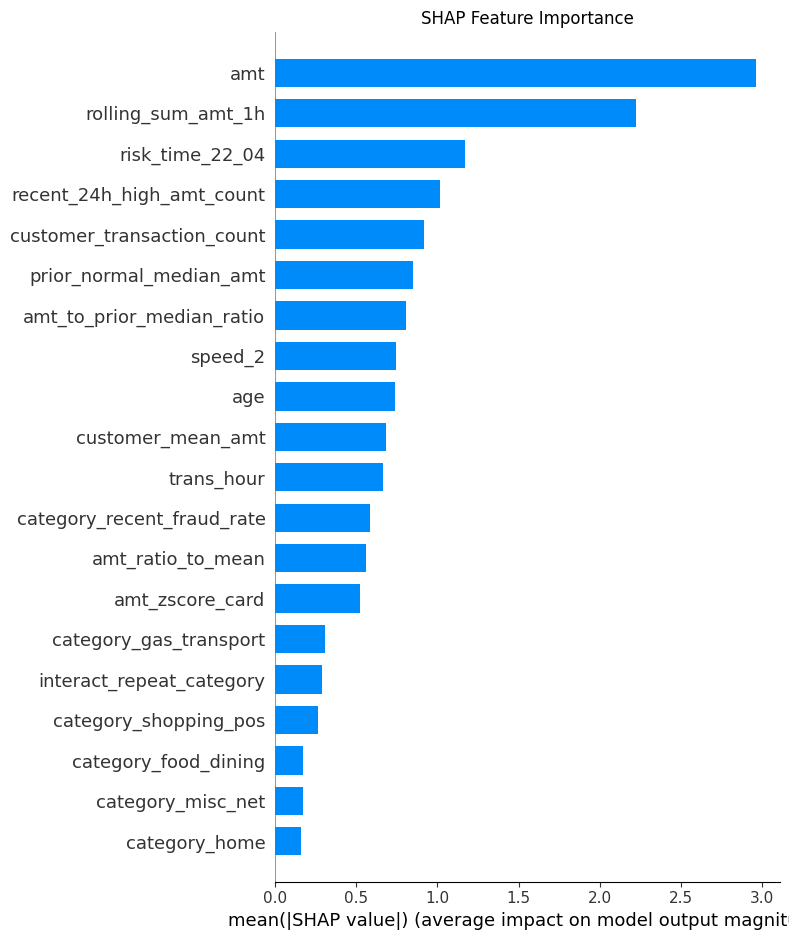

In [ ]:
# ============================================================
# ① SHAP Feature Importance
# ============================================================

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_val_shap,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

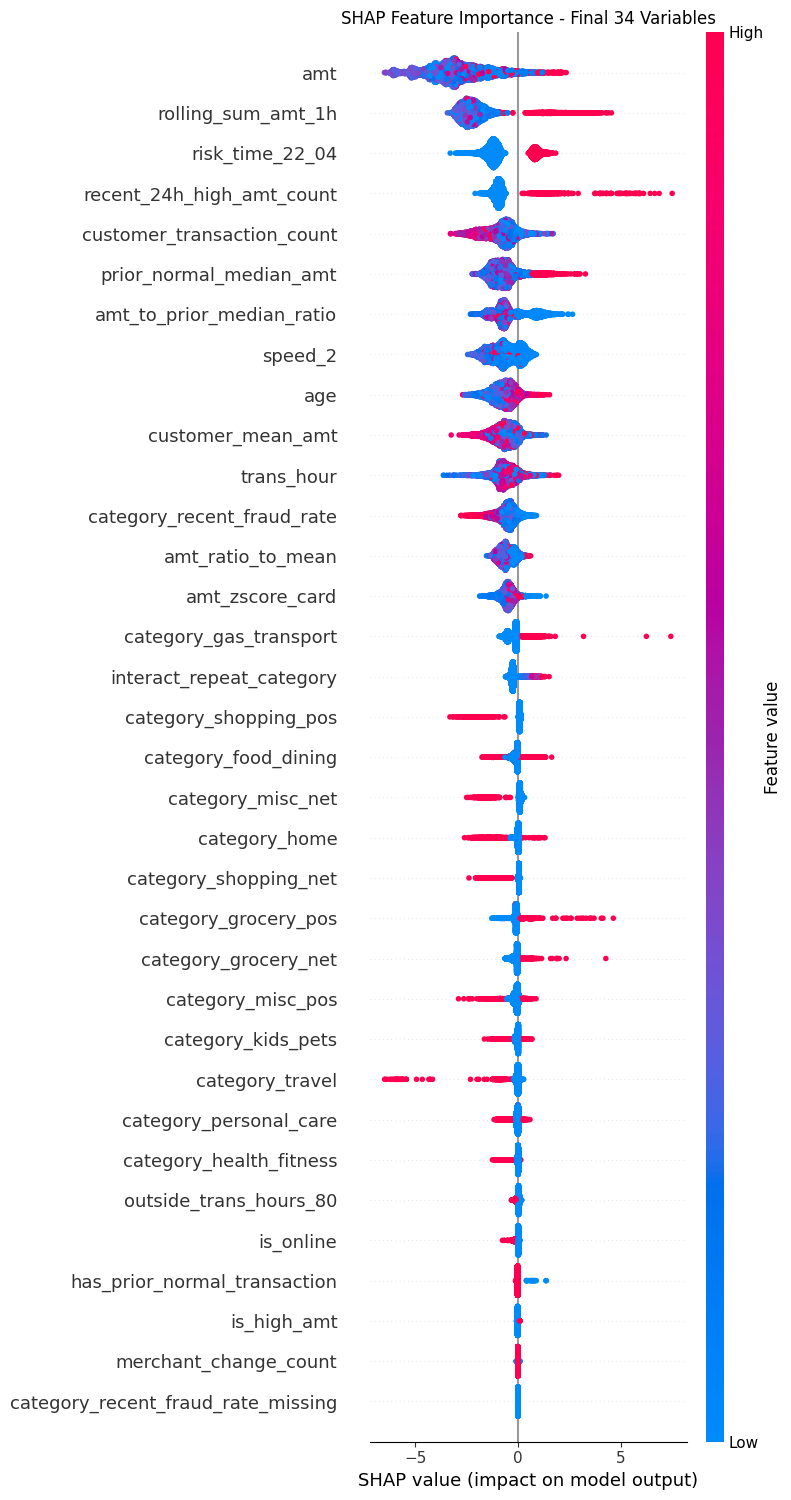

In [ ]:
# ============================================================
# 2. SHAP Summary Plot
# ============================================================

plt.figure(figsize=(10, 12))

shap.summary_plot(
    shap_values,
    X_val_shap,
    max_display=34,
    show=False
)

plt.title("SHAP Feature Importance - Final 34 Variables")
plt.tight_layout()
plt.show()

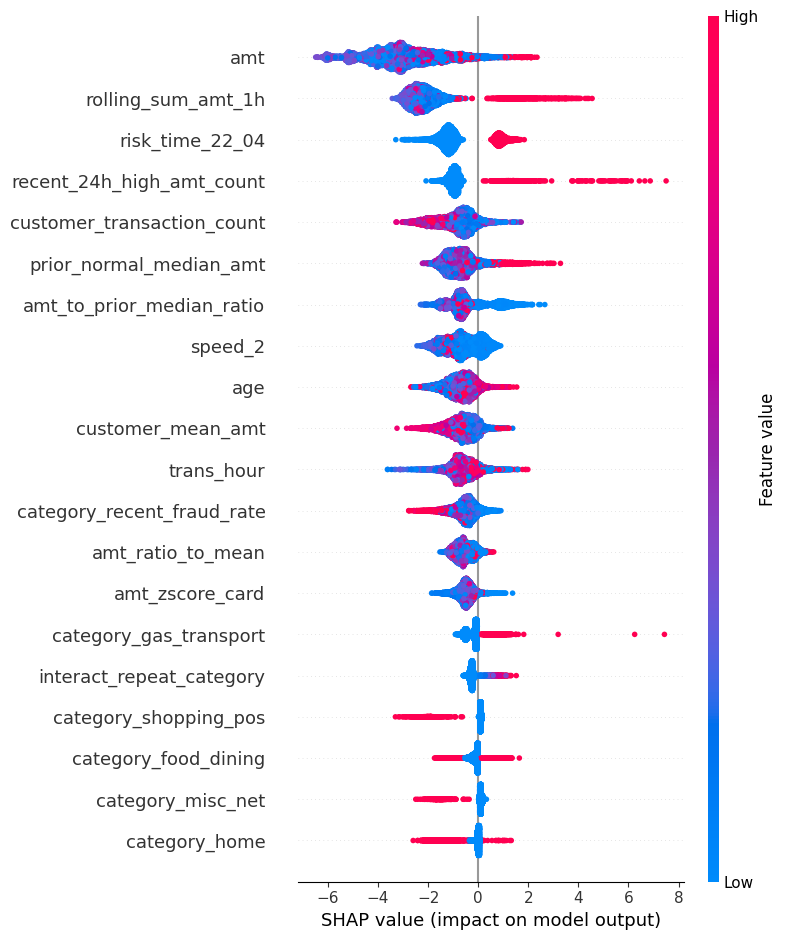

In [ ]:
# ============================================================
# ② SHAP Summary Plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_val_shap,
    max_display=20
)

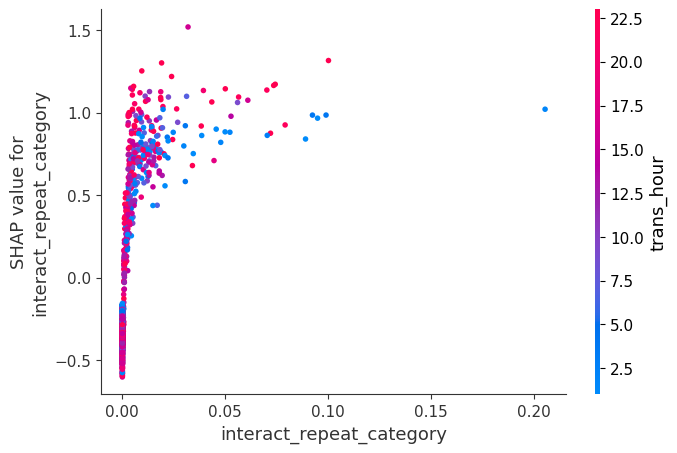

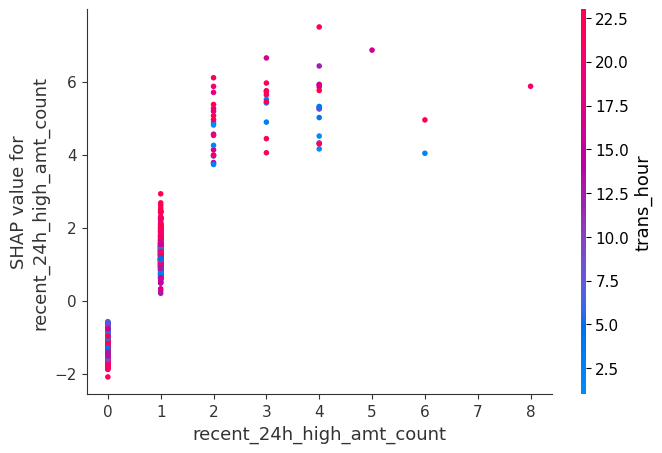

In [ ]:
# ============================================================
# ③ SHAP Dependence Plot
# ============================================================

shap.dependence_plot(
    "interact_repeat_category",
    shap_values,
    X_val_shap
)
shap.dependence_plot(
    "recent_24h_high_amt_count",
    shap_values,
    X_val_shap
)


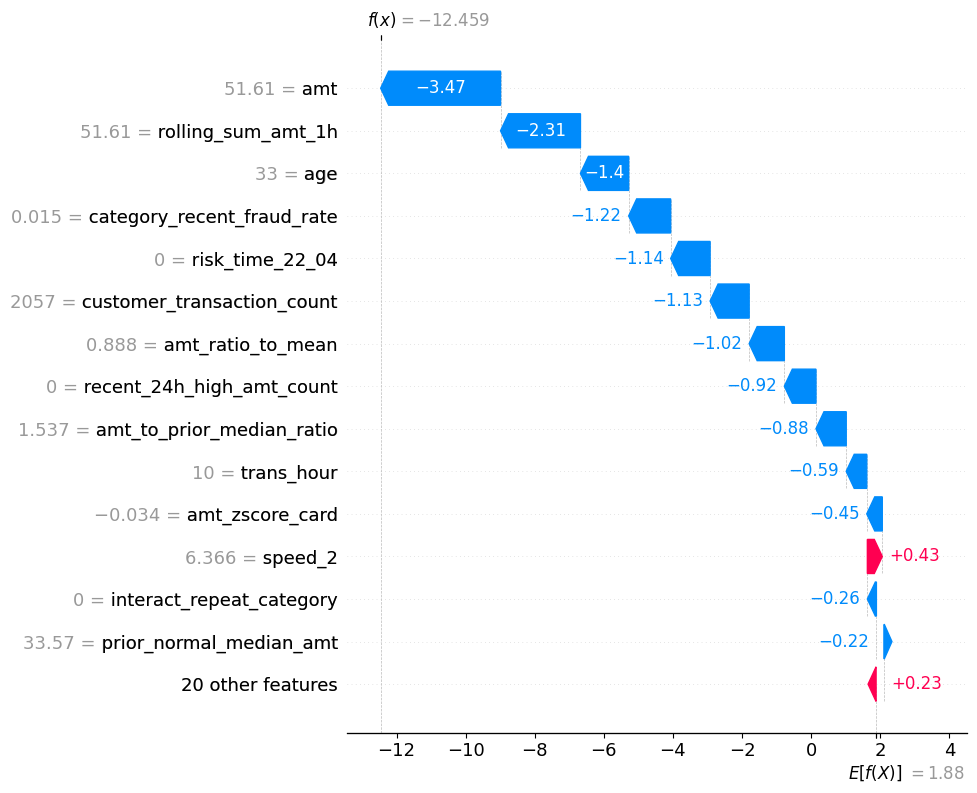

In [ ]:
# ============================================================
# ④ SHAP Waterfall Plot
# ============================================================

sample_idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_val_shap.iloc[sample_idx],
        feature_names=X_val_shap.columns
    ),
    max_display=15
)


★ SHAP 분석 시작


In [ ]:
# =====================================================
# 1. Feature 선정
# =====================================================



features = [
    'amt',
    'category',
    'is_online',
    'is_high_amt',
    'merchant_change_count',
    'trans_hour',
    'risk_time_22_04',
    'count_30min',
    'Repeat3',
    'rolling_sum_amt_1h',
    'speed_2',
    'high_speed',
    'customer_mean_amt',
    'amt_ratio_to_mean',
    'amt_zscore_card',
    'customer_transaction_count',
    'category_recent_fraud_rate',
    'category_recent_fraud_rate_missing',
    'recent_24h_high_amt_count',
    'interact_repeat_category',
    'has_prior_normal_transaction',
    'outside_trans_hours_80',
    'prior_normal_median_amt',
    'amt_to_prior_median_ratio',
    'is_10x_prior_median',
    'age'
]

target = 'is_fraud'


# =====================================================
# 2. 데이터 준비
# =====================================================

X = df[features].copy()
y = df[target].copy()


# =====================================================
# 3. category 원-핫 인코딩
# =====================================================

X['category'] = X['category'].astype(str)

X = pd.get_dummies(
    X,
    columns=['category'],
    drop_first=True,
    dtype=int
)

print("원-핫 인코딩 후 X shape:", X.shape)

원-핫 인코딩 후 X shape: (1296675, 38)


In [ ]:

# =====================================================
# 3. 시간순 Train / Validation Split
# =====================================================

split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_val = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_val = y.iloc[split_idx:].copy()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)


# =====================================================
# 4. 클래스 불균형 처리
# =====================================================

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print(
    "scale_pos_weight:",
    scale_pos_weight
)



Train: (1037340, 38)
Validation: (259335, 38)
scale_pos_weight: 173.22573060127644


In [ ]:
from xgboost import XGBClassifier

In [ ]:
# =====================================================
# XGBoost 기본 모델 + Early Stopping
# =====================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(

    n_estimators=500,

    max_depth=6,
    learning_rate=0.05,

    min_child_weight=1,
    gamma=0,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0,
    reg_lambda=1,

    scale_pos_weight=scale_pos_weight,

    eval_metric='aucpr',

    early_stopping_rounds=20,

    random_state=42,

    tree_method='hist',

    n_jobs=-1
)


xgb_model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_val, y_val)
    ],

    verbose=False
)


print("================================")
print("학습 완료")
print("================================")

print(
    "Best iteration:",
    xgb_model.best_iteration
)

print(
    "Best validation PR-AUC:",
    xgb_model.best_score
)

학습 완료
Best iteration: 499
Best validation PR-AUC: 0.9683478301382302


In [ ]:
# =====================================================
# 6. max_depth 비교
# =====================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

depth_results = []

for depth in [4, 6, 8]:

    print(f"\n▶ max_depth = {depth} 학습 중...")

    model = XGBClassifier(

        n_estimators=700,

        max_depth=depth,
        learning_rate=0.05,

        min_child_weight=1,
        gamma=0,

        subsample=0.8,
        colsample_bytree=0.8,

        reg_alpha=0,
        reg_lambda=1,

        scale_pos_weight=scale_pos_weight,

        eval_metric='aucpr',
        early_stopping_rounds=20,

        random_state=42,
        tree_method='hist',
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,

        eval_set=[
            (X_val, y_val)
        ],

        verbose=False
    )

    # Validation 확률
    val_prob = model.predict_proba(
        X_val
    )[:, 1]

    # Threshold = 0.9
    val_pred = (
        val_prob >= 0.90
    ).astype(int)

    # 결과 저장
    depth_results.append({

        'max_depth': depth,

        'PR-AUC':
            average_precision_score(
                y_val,
                val_prob
            ),

        'Precision':
            precision_score(
                y_val,
                val_pred,
                zero_division=0
            ),

        'Recall':
            recall_score(
                y_val,
                val_pred,
                zero_division=0
            ),

        'F1':
            f1_score(
                y_val,
                val_pred,
                zero_division=0
            ),

        'Best_iteration':
            model.best_iteration
    })

    print(
        f"  Best iteration: {model.best_iteration}"
    )

    print(
        f"  PR-AUC: {average_precision_score(y_val, val_prob):.4f}"
    )

    print(
        f"  Precision: {precision_score(y_val, val_pred, zero_division=0):.4f}"
    )

    print(
        f"  Recall: {recall_score(y_val, val_pred, zero_division=0):.4f}"
    )

    print(
        f"  F1: {f1_score(y_val, val_pred, zero_division=0):.4f}"
    )


# =====================================================
# 결과 정리
# =====================================================

depth_df = pd.DataFrame(depth_results)

depth_df = depth_df.sort_values(
    'PR-AUC',
    ascending=False
)

print("\n")
print("=" * 70)
print("max_depth 비교 결과")
print("=" * 70)

print(
    depth_df.round(4).to_string(index=False)
)


▶ max_depth = 4 학습 중...
  Best iteration: 697
  PR-AUC: 0.9635
  Precision: 0.8646
  Recall: 0.9336
  F1: 0.8978

▶ max_depth = 6 학습 중...
  Best iteration: 699
  PR-AUC: 0.9704
  Precision: 0.9588
  Recall: 0.9149
  F1: 0.9364

▶ max_depth = 8 학습 중...
  Best iteration: 634
  PR-AUC: 0.9705
  Precision: 0.9776
  Recall: 0.8982
  F1: 0.9362


max_depth 비교 결과
 max_depth  PR-AUC  Precision  Recall     F1  Best_iteration
         8  0.9705     0.9776  0.8982 0.9362             634
         6  0.9704     0.9588  0.9149 0.9364             699
         4  0.9635     0.8646  0.9336 0.8978             697


In [ ]:
min_child_results = []

for min_child in [1]:

    print(f"▶ min_child_weight = {min_child} 학습 중...")

    model = XGBClassifier(
        n_estimators=1500,
        max_depth=6,
        learning_rate=0.03,

        min_child_weight=min_child,
        gamma=0,

        subsample=0.8,
        colsample_bytree=0.8,

        reg_alpha=0,
        reg_lambda=1,

        scale_pos_weight=scale_pos_weight,

        eval_metric='aucpr',
        early_stopping_rounds=80,

        random_state=42,
        tree_method='hist',
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    result = evaluate_model(
        model,
        X_val,
        y_val,
        threshold=0.90
    )

    result['min_child_weight'] = min_child
    result['best_iteration'] = model.best_iteration
    result['best_validation_pr_auc'] = model.best_score

    min_child_results.append(result)

    print(
        f"  Best iteration: {model.best_iteration}"
        f" | PR-AUC: {model.best_score:.4f}"
        f" | Precision: {result['Precision']:.4f}"
        f" | Recall: {result['Recall']:.4f}"
        f" | F1: {result['F1']:.4f}"
    )


min_child_df = pd.DataFrame(min_child_results)

min_child_df = min_child_df.sort_values(
    'best_validation_pr_auc',
    ascending=False
)

print("\n===== min_child_weight 결과 =====")
print(min_child_df.round(4))

▶ min_child_weight = 1 학습 중...
  Best iteration: 1499 | PR-AUC: 0.9719 | Precision: 0.9718 | Recall: 0.9098 | F1: 0.9398

===== min_child_weight 결과 =====
   PR-AUC  ROC-AUC  Precision  Recall      F1  Accuracy  Best_iteration  \
0  0.9719   0.9994     0.9718  0.9098  0.9398    0.9993            1499   

   min_child_weight  best_iteration  best_validation_pr_auc  
0                 1            1499                  0.9719  


In [ ]:
model = XGBClassifier(
    n_estimators=2000,

    max_depth=6,
    learning_rate=0.03,

    min_child_weight=1,
    gamma=0,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0,
    reg_lambda=1,

    scale_pos_weight=scale_pos_weight,

    eval_metric='aucpr',
    early_stopping_rounds=100,

    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

result = evaluate_model(
    model,
    X_val,
    y_val,
    threshold=0.90
)

print(f"Best iteration: {model.best_iteration}")
print(f"PR-AUC: {model.best_score:.4f}")
print(f"Precision: {result['Precision']:.4f}")
print(f"Recall: {result['Recall']:.4f}")
print(f"F1: {result['F1']:.4f}")

Best iteration: 1931
PR-AUC: 0.9725
Precision: 0.9770
Recall: 0.9046
F1: 0.9394


In [ ]:
#######현재확정값####
#max_depth = 6
####min_child_weight = 1
#333333learning_rate = 0.03
########Best iteration ≈ 1931

In [ ]:
sampling_results = []

# 대표 조합만 빠르게 비교
sampling_combinations = [
    (0.7, 0.8),
    (0.8, 0.8),   # 현재 기준
    (0.9, 0.8),
    (0.8, 0.7),
    (0.8, 0.9)
]

for subsample, colsample in sampling_combinations:

    print(
        f"▶ subsample={subsample}, "
        f"colsample_bytree={colsample} 학습 중..."
    )

    model = XGBClassifier(
        n_estimators=2000,

        max_depth=6,
        learning_rate=0.03,
        min_child_weight=1,

        gamma=0,

        subsample=subsample,
        colsample_bytree=colsample,

        reg_alpha=0,
        reg_lambda=1,

        scale_pos_weight=scale_pos_weight,

       eval_metric='aucpr',
       early_stopping_rounds=30,
       random_state=42,
       tree_method='hist',
       n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    result = evaluate_model(
        model,
        X_val,
        y_val,
        threshold=0.90
    )

    result['subsample'] = subsample
    result['colsample_bytree'] = colsample
    result['best_iteration'] = model.best_iteration
    result['best_validation_pr_auc'] = model.best_score

    sampling_results.append(result)

    print(
        f"  Best iteration: {model.best_iteration}"
        f" | PR-AUC: {model.best_score:.4f}"
        f" | Precision: {result['Precision']:.4f}"
        f" | Recall: {result['Recall']:.4f}"
        f" | F1: {result['F1']:.4f}"
    )


sampling_df = pd.DataFrame(sampling_results)

sampling_df = sampling_df.sort_values(
    'best_validation_pr_auc',
    ascending=False
)

print("\n===== subsample + colsample_bytree 결과 =====")
print(sampling_df.round(4))

▶ subsample=0.7, colsample_bytree=0.8 학습 중...
  Best iteration: 1341 | PR-AUC: 0.9713 | Precision: 0.9631 | Recall: 0.9085 | F1: 0.9350
▶ subsample=0.8, colsample_bytree=0.8 학습 중...
  Best iteration: 1070 | PR-AUC: 0.9707 | Precision: 0.9556 | Recall: 0.9162 | F1: 0.9355
▶ subsample=0.9, colsample_bytree=0.8 학습 중...
  Best iteration: 868 | PR-AUC: 0.9693 | Precision: 0.9420 | Recall: 0.9207 | F1: 0.9312
▶ subsample=0.8, colsample_bytree=0.7 학습 중...
  Best iteration: 1136 | PR-AUC: 0.9712 | Precision: 0.9549 | Recall: 0.9137 | F1: 0.9338
▶ subsample=0.8, colsample_bytree=0.9 학습 중...
  Best iteration: 880 | PR-AUC: 0.9696 | Precision: 0.9426 | Recall: 0.9201 | F1: 0.9312

===== subsample + colsample_bytree 결과 =====
   PR-AUC  ROC-AUC  Precision  Recall      F1  Accuracy  Best_iteration  \
0  0.9713   0.9994     0.9631  0.9085  0.9350    0.9992            1341   
3  0.9712   0.9994     0.9549  0.9137  0.9338    0.9992            1136   
1  0.9707   0.9993     0.9556  0.9162  0.9355    0.9

In [ ]:
reg_results = []

# 대표적인 규제 조합
reg_combinations = [
    (0,   0,   1),    # 현재 기준
    (0.1, 0.1, 1),
    (0.1, 0.5, 5),
    (0.5, 0.1, 5),
    (0.5, 0.5, 10),
    (1.0, 0.5, 10)
]

for gamma, reg_alpha, reg_lambda in reg_combinations:

    print(
        f"▶ gamma={gamma}, "
        f"reg_alpha={reg_alpha}, "
        f"reg_lambda={reg_lambda} 학습 중..."
    )

    model = XGBClassifier(
        n_estimators=2000,

        max_depth=6,
        learning_rate=0.03,
        min_child_weight=1,

        gamma=gamma,

        subsample=0.7,
        colsample_bytree=0.8,

        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,

        scale_pos_weight=scale_pos_weight,

        eval_metric='aucpr',
        early_stopping_rounds=30,

        random_state=42,
        tree_method='hist',
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    result = evaluate_model(
        model,
        X_val,
        y_val,
        threshold=0.90
    )

    result['gamma'] = gamma
    result['reg_alpha'] = reg_alpha
    result['reg_lambda'] = reg_lambda
    result['best_iteration'] = model.best_iteration
    result['best_validation_pr_auc'] = model.best_score

    reg_results.append(result)

    print(
        f"  Best iteration: {model.best_iteration}"
        f" | PR-AUC: {model.best_score:.4f}"
        f" | Precision: {result['Precision']:.4f}"
        f" | Recall: {result['Recall']:.4f}"
        f" | F1: {result['F1']:.4f}"
    )


reg_df = pd.DataFrame(reg_results)

reg_df = reg_df.sort_values(
    'best_validation_pr_auc',
    ascending=False
)

print("\n===== 규제 파라미터 결과 =====")
print(reg_df.round(4))

▶ gamma=0, reg_alpha=0, reg_lambda=1 학습 중...
  Best iteration: 1341 | PR-AUC: 0.9713 | Precision: 0.9631 | Recall: 0.9085 | F1: 0.9350
▶ gamma=0.1, reg_alpha=0.1, reg_lambda=1 학습 중...
  Best iteration: 856 | PR-AUC: 0.9690 | Precision: 0.9340 | Recall: 0.9214 | F1: 0.9277
▶ gamma=0.1, reg_alpha=0.5, reg_lambda=5 학습 중...
  Best iteration: 1335 | PR-AUC: 0.9719 | Precision: 0.9538 | Recall: 0.9169 | F1: 0.9350
▶ gamma=0.5, reg_alpha=0.1, reg_lambda=5 학습 중...
  Best iteration: 1445 | PR-AUC: 0.9718 | Precision: 0.9600 | Recall: 0.9117 | F1: 0.9352
▶ gamma=0.5, reg_alpha=0.5, reg_lambda=10 학습 중...


KeyboardInterrupt: 

In [ ]:
###########
#gamma=0, reg_alpha=0, reg_lambda=1 학습 중...
  #Best iteration: 1341 | PR-AUC: 0.9713 | Precision: 0.9631 | Recall: 0.9085 | F1: 0.9350
#▶ gamma=0.1, reg_alpha=0.1, reg_lambda=1 학습 중...
 # Best iteration: 856 | PR-AUC: 0.9690 | Precision: 0.9340 | Recall: 0.9214 | F1: 0.9277
#▶ gamma=0.1, reg_alpha=0.5, reg_lambda=5 학습 중...
 # Best iteration: 1335 | PR-AUC: 0.9719 | Precision: 0.9538 | Recall: 0.9169 | F1: 0.9350
#▶ gamma=0.5, reg_alpha=0.1, reg_lambda=5 학습 중...
 # Best iteration: 1445 | PR-AUC: 0.9718 | Precision: 0.9600 | Recall: 0.9117 | F1: 0.9352

In [ ]:
# ============================================
# 최종 XGBoost 모델 - Early Stopping
# ============================================

final_model = XGBClassifier(
    n_estimators=2500,

    max_depth=6,
    learning_rate=0.03,
    min_child_weight=1,

    gamma=0.1,

    subsample=0.7,
    colsample_bytree=0.8,

    reg_alpha=0.5,
    reg_lambda=5,

    scale_pos_weight=scale_pos_weight,

    eval_metric='aucpr',
    early_stopping_rounds=60,

    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

print("▶ 최종 XGBoost 학습 시작...")

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("\n================ 최종 Early Stopping 결과 ================")
print(f"Best iteration : {final_model.best_iteration}")
print(f"Best PR-AUC    : {final_model.best_score:.4f}")

▶ 최종 XGBoost 학습 시작...

================ 최종 Early Stopping 결과 ================
Best iteration : 1762
Best PR-AUC    : 0.9724


In [ ]:
final_result_090 = evaluate_model(
    final_model,
    X_val,
    y_val,
    threshold=0.90
)

print("\n================ Threshold 0.90 결과 ================")
print(pd.Series(final_result_090).round(4))


================ Threshold 0.90 결과 ================
PR-AUC               0.9724
ROC-AUC              0.9994
Precision            0.9697
Recall               0.9066
F1                   0.9371
Accuracy             0.9993
Best_iteration    1762.0000
dtype: float64


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# 최종 모델의 이상거래 확률
y_prob = final_model.predict_proba(X_val)[:, 1]

threshold_results = []

for threshold in np.arange(0.80, 1.00, 0.01):

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    threshold_results.append({
        'Threshold': round(threshold, 2),
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })


threshold_df = pd.DataFrame(threshold_results)

# F1 기준 내림차순
threshold_df = threshold_df.sort_values(
    'F1',
    ascending=False
)

print("\n================ Threshold 0.80~0.99 결과 ================")
print(threshold_df.round(4).to_string(index=False))


================ Threshold 0.80~0.99 결과 ================
 Threshold  Precision  Recall     F1
      0.83     0.9547  0.9240 0.9391
      0.84     0.9559  0.9220 0.9387
      0.82     0.9535  0.9240 0.9385
      0.81     0.9504  0.9259 0.9380
      0.89     0.9678  0.9091 0.9375
      0.85     0.9570  0.9188 0.9375
      0.87     0.9627  0.9137 0.9375
      0.80     0.9491  0.9259 0.9374
      0.86     0.9595  0.9162 0.9374
      0.88     0.9658  0.9104 0.9373
      0.90     0.9697  0.9066 0.9371
      0.91     0.9716  0.9027 0.9359
      0.92     0.9735  0.9008 0.9357
      0.93     0.9762  0.8976 0.9352
      0.95     0.9822  0.8898 0.9337
      0.94     0.9781  0.8924 0.9333
      0.96     0.9849  0.8847 0.9321
      0.97     0.9877  0.8789 0.9301
      0.98     0.9919  0.8660 0.9247
      0.99     0.9962  0.8486 0.9165


In [ ]:
# F1 기준 최적 Threshold
best_threshold_row = threshold_df.iloc[0]

print("\n================ 최적 Threshold ================")
print(
    f"Threshold : {best_threshold_row['Threshold']:.2f}"
)
print(
    f"Precision : {best_threshold_row['Precision']:.4f}"
)
print(
    f"Recall    : {best_threshold_row['Recall']:.4f}"
)
print(
    f"F1        : {best_threshold_row['F1']:.4f}"
)


# 기존 Threshold 0.90
threshold_090 = threshold_df[
    threshold_df['Threshold'] == 0.90
].iloc[0]

print("\n================ 0.90 vs 최적 Threshold ================")

comparison = pd.DataFrame({
    'Threshold 0.90': [
        threshold_090['Precision'],
        threshold_090['Recall'],
        threshold_090['F1']
    ],
    'Optimal Threshold': [
        best_threshold_row['Precision'],
        best_threshold_row['Recall'],
        best_threshold_row['F1']
    ]
}, index=['Precision', 'Recall', 'F1'])

print(comparison.round(4))


================ 최적 Threshold ================
Threshold : 0.83
Precision : 0.9547
Recall    : 0.9240
F1        : 0.9391

================ 0.90 vs 최적 Threshold ================
           Threshold 0.90  Optimal Threshold
Precision          0.9697             0.9547
Recall             0.9066             0.9240
F1                 0.9371             0.9391


In [ ]:
import shap
import pandas as pd
import numpy as np

# SHAP TreeExplainer
explainer = shap.TreeExplainer(final_model)

# 데이터가 너무 크므로 일부만 사용 → 속도 개선
X_shap = X_val.sample(
    n=min(10000, len(X_val)),
    random_state=42
)

shap_values = explainer.shap_values(X_shap)

# 평균 |SHAP| 중요도
shap_importance = pd.DataFrame({
    'Feature': X_shap.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values(
    'Mean_SHAP',
    ascending=False
)

print("========== SHAP 중요도 ==========")
print(shap_importance.to_string(index=False))

========== SHAP 중요도 ==========
                           Feature  Mean_SHAP
                               amt   2.990690
                rolling_sum_amt_1h   2.260780
                   risk_time_22_04   1.158430
         recent_24h_high_amt_count   1.026892
        customer_transaction_count   0.895968
         amt_to_prior_median_ratio   0.813725
           prior_normal_median_amt   0.806588
                               age   0.775361
                           speed_2   0.734767
                 customer_mean_amt   0.679774
                        trans_hour   0.670721
        category_recent_fraud_rate   0.612732
                 amt_ratio_to_mean   0.557706
                   amt_zscore_card   0.485960
            category_gas_transport   0.311282
          interact_repeat_category   0.278828
             category_shopping_pos   0.270320
              category_food_dining   0.176142
                 category_misc_net   0.166748
             category_shopping_net   0.149732
   

In [ ]:
# 비교할 변수
compare_features = [
    'customer_mean_amt',
    'amt_ratio_to_mean',
    'amt_zscore_card',

    'prior_normal_median_amt',
    'amt_to_prior_median_ratio',
    'is_10x_prior_median',

    'speed_2',
    'high_speed',

    'count_30min',
    'Repeat3'
]

removal_results = []

# 현재 모델 성능
base_pred = final_model.predict_proba(X_val)[:, 1]
base_pred_class = (base_pred >= 0.83).astype(int)

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

removal_results.append({
    'Removed': 'None (현재 모델)',
    'PR-AUC': average_precision_score(y_val, base_pred),
    'Precision': precision_score(y_val, base_pred_class),
    'Recall': recall_score(y_val, base_pred_class),
    'F1': f1_score(y_val, base_pred_class)
})


# 변수 하나씩 제거한 모델의 예측
for feature in compare_features:

    print(f"▶ {feature} 제거 효과 확인 중...")

    # 해당 변수 제거
    X_train_drop = X_train.drop(columns=[feature])
    X_val_drop = X_val.drop(columns=[feature])

    # 현재 최종 설정 그대로 사용
    test_model = XGBClassifier(
        n_estimators=1763,

        max_depth=6,
        learning_rate=0.03,
        min_child_weight=1,

        gamma=0.1,

        subsample=0.7,
        colsample_bytree=0.8,

        reg_alpha=0.5,
        reg_lambda=5,

        scale_pos_weight=scale_pos_weight,

        eval_metric='aucpr',

        random_state=42,
        tree_method='hist',
        n_jobs=-1
    )

    test_model.fit(
        X_train_drop,
        y_train,
        verbose=False
    )

    pred = test_model.predict_proba(X_val_drop)[:, 1]
    pred_class = (pred >= 0.83).astype(int)

    removal_results.append({
        'Removed': feature,
        'PR-AUC': average_precision_score(y_val, pred),
        'Precision': precision_score(y_val, pred_class),
        'Recall': recall_score(y_val, pred_class),
        'F1': f1_score(y_val, pred_class)
    })


removal_df = pd.DataFrame(removal_results)

print("\n========== 변수 제거 효과 ==========")
print(removal_df.round(4).to_string(index=False))

▶ customer_mean_amt 제거 효과 확인 중...
▶ amt_ratio_to_mean 제거 효과 확인 중...
▶ amt_zscore_card 제거 효과 확인 중...
▶ prior_normal_median_amt 제거 효과 확인 중...
▶ amt_to_prior_median_ratio 제거 효과 확인 중...
▶ is_10x_prior_median 제거 효과 확인 중...
▶ speed_2 제거 효과 확인 중...
▶ high_speed 제거 효과 확인 중...
▶ count_30min 제거 효과 확인 중...
▶ Repeat3 제거 효과 확인 중...

========== 변수 제거 효과 ==========
                  Removed  PR-AUC  Precision  Recall     F1
             None (현재 모델)  0.9724     0.9547  0.9240 0.9391
        customer_mean_amt  0.9718     0.9462  0.9175 0.9316
        amt_ratio_to_mean  0.9712     0.9551  0.9188 0.9366
          amt_zscore_card  0.9716     0.9500  0.9188 0.9342
  prior_normal_median_amt  0.9691     0.9384  0.9227 0.9305
amt_to_prior_median_ratio  0.9712     0.9507  0.9188 0.9345
      is_10x_prior_median  0.9719     0.9527  0.9207 0.9364
                  speed_2  0.9702     0.9526  0.9201 0.9361
               high_speed  0.9714     0.9539  0.9195 0.9364
              count_30min  0.9720     0.9545  0

In [ ]:
######################변수제거 및 하이퍼파라미터 임계값 확정 ###################

In [ ]:
###############여기서부터 실행 ###########

In [ ]:
# ============================================
# 4개 변수 제거 후 최종 후보 모델
# ============================================

drop_features = [
    'high_speed',
    'is_10x_prior_median',
    'Repeat3',
    'count_30min'
]

X_train_reduced = X_train.drop(columns=drop_features)
X_val_reduced = X_val.drop(columns=drop_features)

In [ ]:
#############################################################

print("제거 변수:", drop_features)
print("기존 변수 수:", X_train.shape[1])
print("제거 후 변수 수:", X_train_reduced.shape[1])


# ============================================
# 빠른 재학습
# ============================================

reduced_model = XGBClassifier(
    n_estimators=1800,

    max_depth=6,
    learning_rate=0.03,
    min_child_weight=1,

    gamma=0.1,

    subsample=0.7,
    colsample_bytree=0.8,

    reg_alpha=0.5,
    reg_lambda=5,

    scale_pos_weight=scale_pos_weight,

    eval_metric='aucpr',
    early_stopping_rounds=40,

    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

print("\n▶ 4개 변수 제거 모델 학습 시작...")

reduced_model.fit(
    X_train_reduced,
    y_train,
    eval_set=[(X_val_reduced, y_val)],
    verbose=False
)


# ============================================
# Validation 평가
# ============================================

y_prob_reduced = reduced_model.predict_proba(
    X_val_reduced
)[:, 1]

y_pred_reduced = (
    y_prob_reduced >= 0.83
).astype(int)


from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print("\n================ 4개 변수 제거 결과 ================")

print(f"Best iteration : {reduced_model.best_iteration}")
print(f"PR-AUC        : {average_precision_score(y_val, y_prob_reduced):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_val, y_prob_reduced):.4f}")
print(f"Precision     : {precision_score(y_val, y_pred_reduced):.4f}")
print(f"Recall        : {recall_score(y_val, y_pred_reduced):.4f}")
print(f"F1            : {f1_score(y_val, y_pred_reduced):.4f}")
print(f"Accuracy      : {accuracy_score(y_val, y_pred_reduced):.4f}")

제거 변수: ['high_speed', 'is_10x_prior_median', 'Repeat3', 'count_30min']
기존 변수 수: 38
제거 후 변수 수: 34

▶ 4개 변수 제거 모델 학습 시작...


KeyboardInterrupt: 

In [ ]:
# ============================================
# 34개 변수 최종 후보 모델
# ============================================

final_features = X_train_reduced.columns

final_reduced_model = XGBClassifier(
    n_estimators=1700,

    max_depth=6,
    learning_rate=0.03,
    min_child_weight=1,

    gamma=0.1,

    subsample=0.7,
    colsample_bytree=0.8,

    reg_alpha=0.5,
    reg_lambda=5,

    scale_pos_weight=scale_pos_weight,

    eval_metric='aucpr',
    early_stopping_rounds=40,

    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

print("▶ 34개 변수 최종 모델 학습 시작...")

final_reduced_model.fit(
    X_train_reduced,
    y_train,
    eval_set=[(X_val_reduced, y_val)],
    verbose=False
)


# ============================================
# Validation 확률
# ============================================

y_prob_final = final_reduced_model.predict_proba(
    X_val_reduced
)[:, 1]


# ============================================
# 최종 Early Stopping 결과
# ============================================

from sklearn.metrics import average_precision_score

print("\n================ 최종 34개 변수 모델 ================")
print(f"Best iteration : {final_reduced_model.best_iteration}")
print(f"Best PR-AUC    : {final_reduced_model.best_score:.4f}")
print(f"PR-AUC         : {average_precision_score(y_val, y_prob_final):.4f}")

▶ 34개 변수 최종 모델 학습 시작...


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# 최종 34개 변수 모델의 확률
y_prob_final = final_reduced_model.predict_proba(
    X_val_reduced
)[:, 1]

threshold_results_final = []

for threshold in np.arange(0.80, 1.00, 0.01):

    y_pred = (y_prob_final >= threshold).astype(int)

    threshold_results_final.append({
        'Threshold': round(threshold, 2),
        'Precision': precision_score(
            y_val, y_pred, zero_division=0
        ),
        'Recall': recall_score(
            y_val, y_pred, zero_division=0
        ),
        'F1': f1_score(
            y_val, y_pred, zero_division=0
        )
    })

threshold_final_df = pd.DataFrame(
    threshold_results_final
)

# F1 높은 순
threshold_final_df = threshold_final_df.sort_values(
    'F1',
    ascending=False
)

print("\n========== 최종 34개 변수 Threshold 결과 ==========")
print(
    threshold_final_df
    .round(4)
    .to_string(index=False)
THRESHOLD = 0.87

# Validation 예측 확률
y_val_prob = final_reduced_model.predict_proba(
    X_val_reduced
)[:, 1]

# Threshold 적용
y_val_pred = (
    y_val_prob >= THRESHOLD
).astype(int)
)


========== 최종 34개 변수 Threshold 결과 ==========
 Threshold  Precision  Recall     F1
      0.87     0.9596  0.9182 0.9384
      0.94     0.9783  0.9008 0.9379
      0.86     0.9583  0.9182 0.9378
      0.90     0.9639  0.9130 0.9378
      0.91     0.9658  0.9111 0.9377
      0.92     0.9691  0.9079 0.9375
      0.88     0.9595  0.9162 0.9374
      0.85     0.9558  0.9195 0.9373
      0.83     0.9509  0.9240 0.9373
      0.89     0.9607  0.9143 0.9369
      0.84     0.9521  0.9220 0.9368
      0.82     0.9485  0.9253 0.9367
      0.93     0.9722  0.9027 0.9362
      0.81     0.9454  0.9253 0.9352
      0.95     0.9802  0.8924 0.9342
      0.80     0.9417  0.9259 0.9337
      0.96     0.9829  0.8866 0.9322
      0.97     0.9891  0.8789 0.9307
      0.98     0.9919  0.8692 0.9265
      0.99     0.9962  0.8466 0.9154


In [ ]:
# ============================================
# 최종 34개 변수 Validation 성능
# Threshold = 0.87
# ============================================

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

THRESHOLD = 0.87

# Validation 예측 확률
y_val_prob = final_reduced_model.predict_proba(
    X_val_reduced
)[:, 1]

# Threshold 적용
y_val_pred = (
    y_val_prob >= THRESHOLD
).astype(int)


# ============================================
# 최종 Validation 성능
# ============================================

print("\n" + "=" * 50)
print("       ★ 최종 Validation 성능 ★")
print("=" * 50)

print(f"변수 수   : {X_val_reduced.shape[1]}")
print(f"Threshold : {THRESHOLD}")
print(f"Best iter : {final_reduced_model.best_iteration}")

print(f"\nPR-AUC    : {average_precision_score(y_val, y_val_prob):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_val, y_val_prob):.4f}")
print(f"Precision : {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall    : {recall_score(y_val, y_val_pred):.4f}")
print(f"F1        : {f1_score(y_val, y_val_pred):.4f}")
print(f"Accuracy  : {accuracy_score(y_val, y_val_pred):.4f}")

print("\n========== Confusion Matrix ==========")
print(confusion_matrix(y_val, y_val_pred))

NotFittedError: need to call fit or load_model beforehand

In [ ]:
#####복구코드#############

In [ ]:
# ============================================
# 현재 메모리에 존재하는 변수 확인
# ============================================

print("X 관련 변수:")
print([name for name in globals() if name.startswith("X")])

print("\n모델 관련 변수:")
print([name for name in globals() if "model" in name.lower()])

X 관련 변수:
[]

모델 관련 변수:
[]


In [ ]:
#####################최종성능 + 하이퍼파라미터 최적화 + 임계값설정 + 변수제거 모두 완료 >>> shap해석단계 ############

In [ ]:


# ============================================
# SHAP 분석
# 최종 34개 변수 모델
# ============================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

# ============================================
# 1. SHAP 분석용 Validation 데이터 샘플링
# ============================================

SHAP_SAMPLE_SIZE = 5000

X_val_shap = X_val_reduced.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_val_reduced)),
    random_state=42
)

print("\n============================================")
print("        SHAP 분석 데이터")
print("============================================")
print("전체 Validation :", X_val_reduced.shape)
print("SHAP 분석용     :", X_val_shap.shape)


# ============================================
# 2. TreeExplainer 생성
# ============================================

explainer = shap.TreeExplainer(
    final_reduced_model
)


# ============================================
# 3. SHAP 값 계산
# ============================================

shap_values = explainer.shap_values(
    X_val
)

print("\nSHAP 계산 완료")
print("SHAP shape :", shap_values.shape)
print("X shape    :", X_val.shape)



SHAP version: 0.52.0


NameError: name 'X_val_reduced' is not defined

In [ ]:
# 현재 X로 시작하는 변수 확인
[x for x in globals() if x.startswith("x")]

[]

In [ ]:
# ============================================================
# 2. SHAP Summary Plot
# ============================================================

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_val,
    max_display=34,
    show=False
)

plt.title("SHAP Summary Plot - Validation", fontsize=14)
plt.tight_layout()
plt.show()

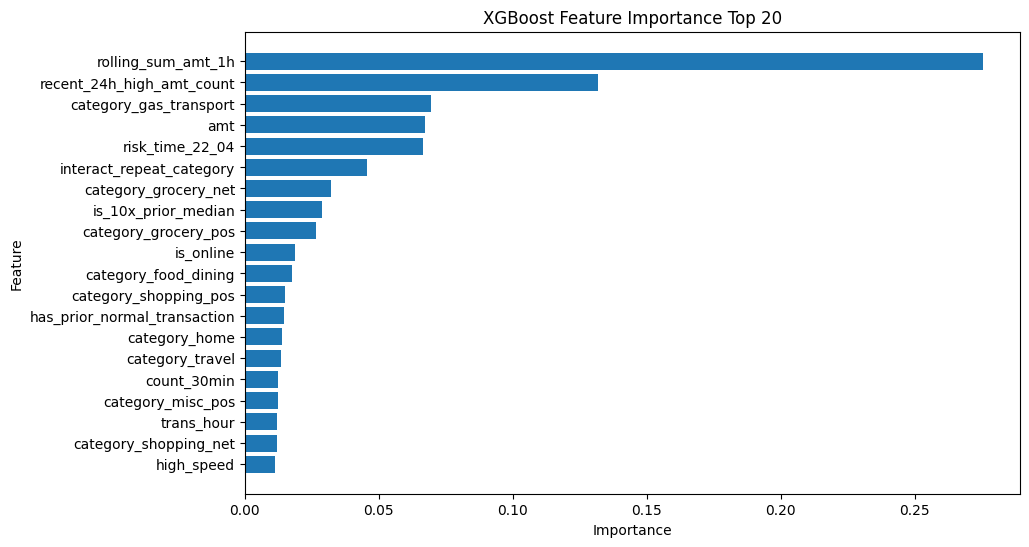

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb


# Feature importance 추출

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
})


importance = (
    importance
    .sort_values(
        'importance',
        ascending=False
    )
    .head(20)
)


plt.figure(figsize=(10,6))

plt.barh(
    importance['feature'][::-1],
    importance['importance'][::-1]
)

plt.title(
    "XGBoost Feature Importance Top 20"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.show()

<Figure size 500x400 with 0 Axes>

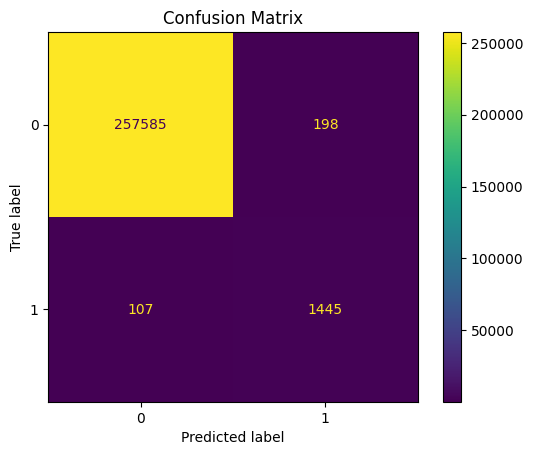

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


plt.figure(figsize=(5,4))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)


plt.title(
    "Confusion Matrix"
)


plt.show()

<Figure size 600x500 with 0 Axes>

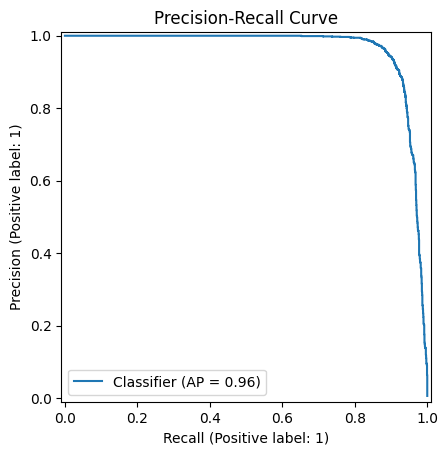

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay


plt.figure(figsize=(6,5))


PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)


plt.title(
    "Precision-Recall Curve"
)


plt.show()

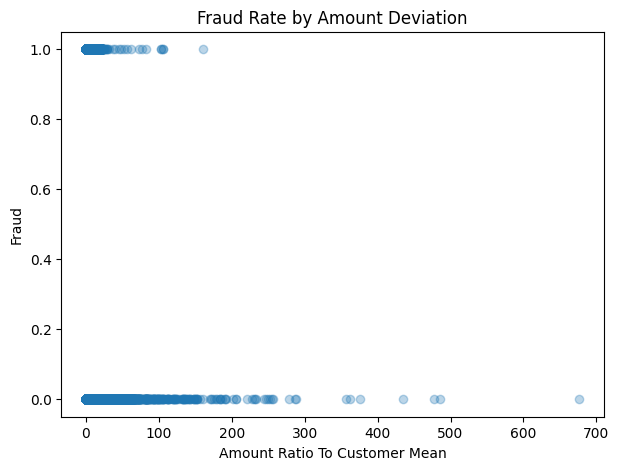

In [ ]:
plt.figure(figsize=(7,5))


plt.scatter(
    df['amt_ratio_to_mean'],
    df['is_fraud'],
    alpha=0.3
)


plt.xlabel(
    "Amount Ratio To Customer Mean"
)

plt.ylabel(
    "Fraud"
)

plt.title(
    "Fraud Rate by Amount Deviation"
)


plt.show()

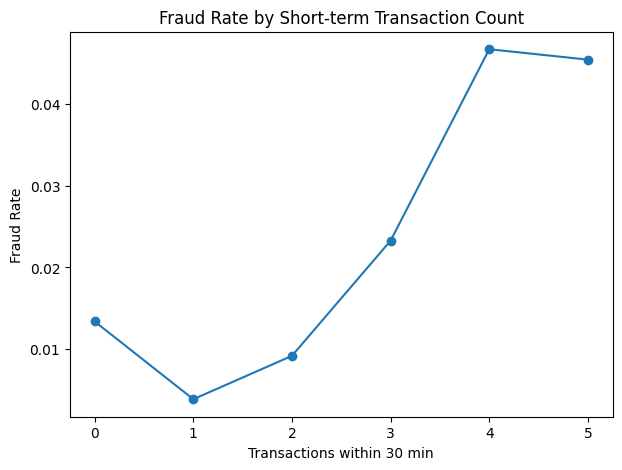

In [ ]:
fraud_repeat = (
    df.groupby('count_30min')
    ['is_fraud']
    .mean()
)


plt.figure(figsize=(7,5))


plt.plot(
    fraud_repeat.index,
    fraud_repeat.values,
    marker='o'
)


plt.xlabel(
    "Transactions within 30 min"
)

plt.ylabel(
    "Fraud Rate"
)


plt.title(
    "Fraud Rate by Short-term Transaction Count"
)


plt.show()

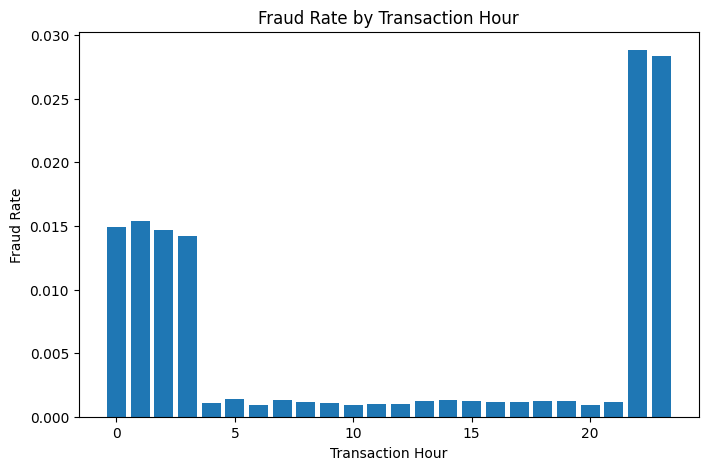

In [ ]:
hour_fraud = (
    df.groupby('trans_hour')
    ['is_fraud']
    .mean()
)


plt.figure(figsize=(8,5))


plt.bar(
    hour_fraud.index,
    hour_fraud.values
)


plt.xlabel(
    "Transaction Hour"
)

plt.ylabel(
    "Fraud Rate"
)


plt.title(
    "Fraud Rate by Transaction Hour"
)


plt.show()

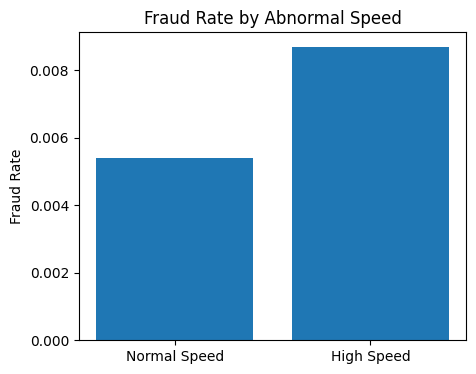

In [ ]:
speed_fraud = (
    df.groupby('high_speed')
    ['is_fraud']
    .mean()
)


plt.figure(figsize=(5,4))


plt.bar(
    speed_fraud.index.astype(str),
    speed_fraud.values
)


plt.xticks(
    [0,1],
    ['Normal Speed','High Speed']
)


plt.ylabel(
    "Fraud Rate"
)


plt.title(
    "Fraud Rate by Abnormal Speed"
)


plt.show()

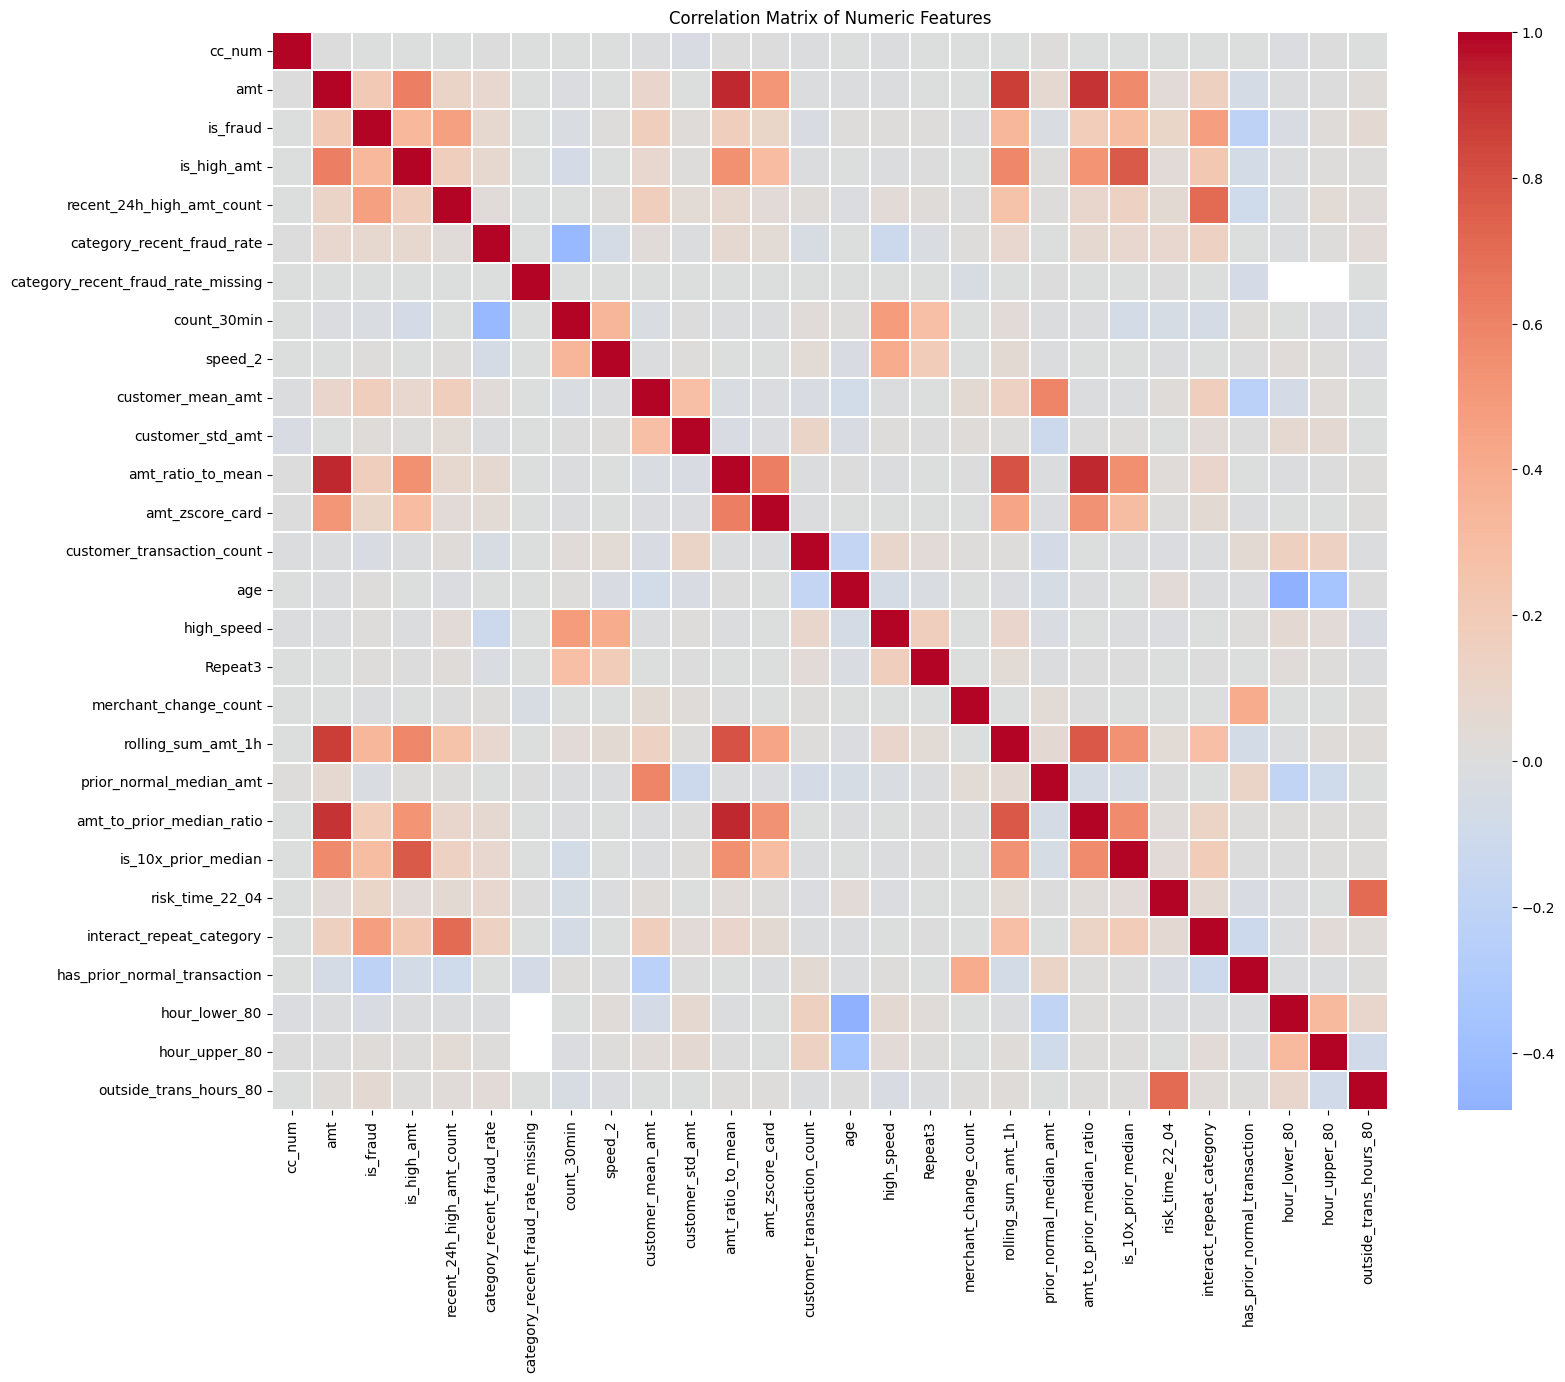

In [ ]:
# =====================================================
# 전체 수치형 변수 상관분석
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 수치형 변수만 선택
numeric_df = df.select_dtypes(
    include=['int64', 'float64']
)


# 상관계수 계산
corr_matrix = numeric_df.corr()


# 전체 상관관계 Heatmap

plt.figure(figsize=(18,14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3
)


plt.title(
    "Correlation Matrix of Numeric Features"
)

plt.show()

In [ ]:
# =====================================================
# 이상거래 여부와 변수별 상관관계
# =====================================================


fraud_corr = (
    corr_matrix['is_fraud']
    .sort_values(
        ascending=False
    )
)


print(fraud_corr)

is_fraud                              1.000000
interact_repeat_category              0.472549
recent_24h_high_amt_count             0.457853
rolling_sum_amt_1h                    0.337068
is_high_amt                           0.331393
is_10x_prior_median                   0.299074
amt                                   0.219404
amt_to_prior_median_ratio             0.180643
amt_ratio_to_mean                     0.169282
customer_mean_amt                     0.165777
risk_time_22_04                       0.110201
amt_zscore_card                       0.100315
category_recent_fraud_rate            0.071113
outside_trans_hours_80                0.058664
customer_std_amt                      0.023241
hour_upper_80                         0.022883
Repeat3                               0.016028
high_speed                            0.014203
age                                   0.012248
speed_2                               0.010374
category_recent_fraud_rate_missing   -0.000251
cc_num       

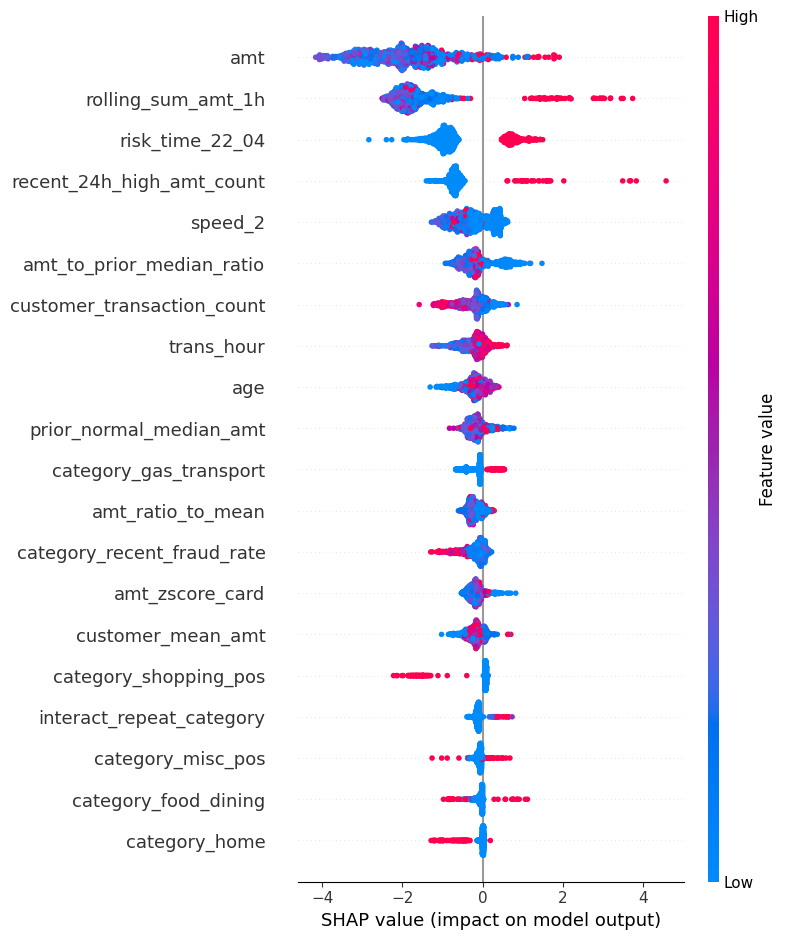

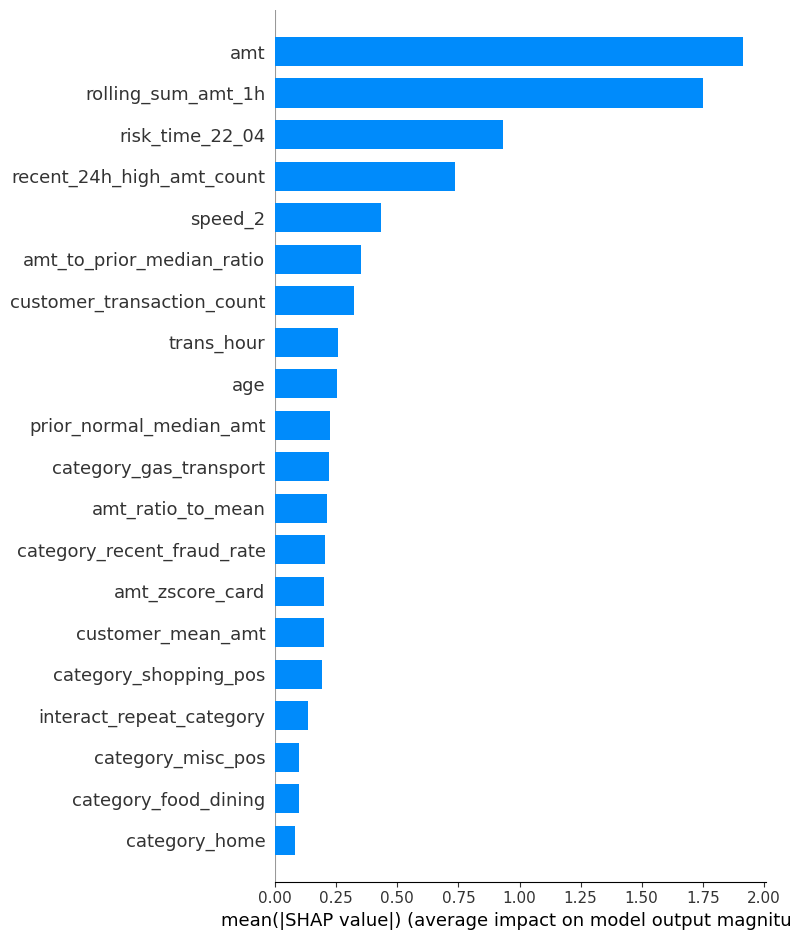

In [ ]:
# =====================================================
# SHAP 분석 (XGBoost)
# =====================================================

import shap
import matplotlib.pyplot as plt


# 1. SHAP 분석용 데이터 샘플링
# (전체 데이터가 크므로 일부 사용)
X_shap = X_test.sample(
    1000,
    random_state=42
)


# 2. TreeExplainer 생성
explainer = shap.TreeExplainer(
    xgb_model
)


# 3. SHAP 값 계산
shap_values = explainer.shap_values(
    X_shap
)


# =====================================================
# 4. SHAP Summary Plot
#    변수 영향 방향 + 중요도
# =====================================================

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20
)


# =====================================================
# 5. SHAP Feature Importance Bar Plot
#    변수 중요도 순위
# =====================================================

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=20
)

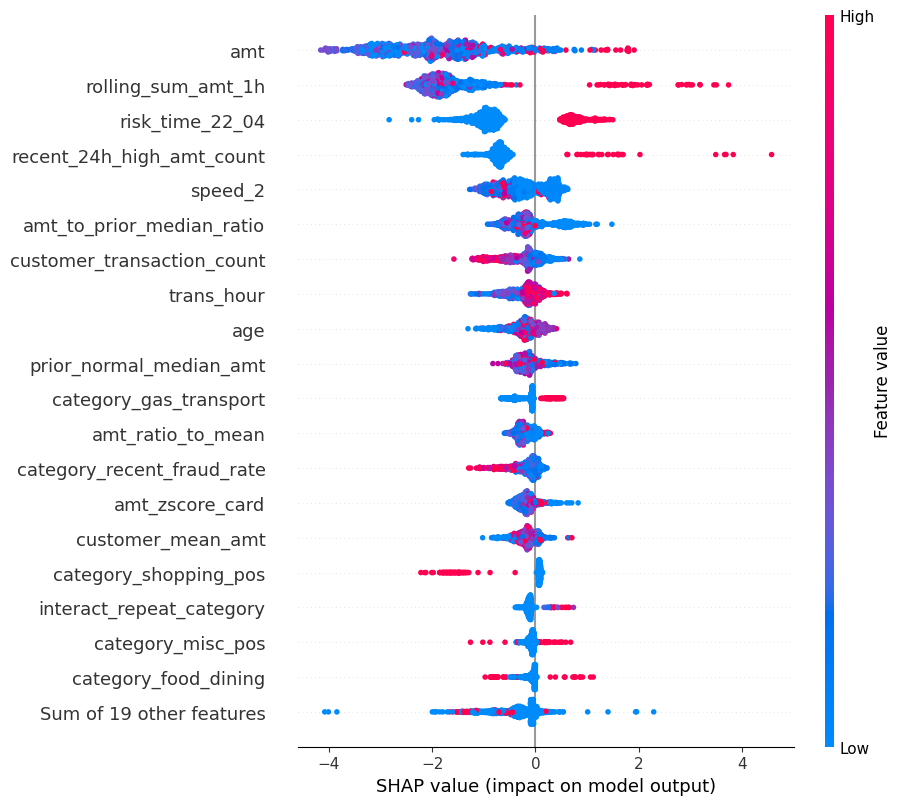

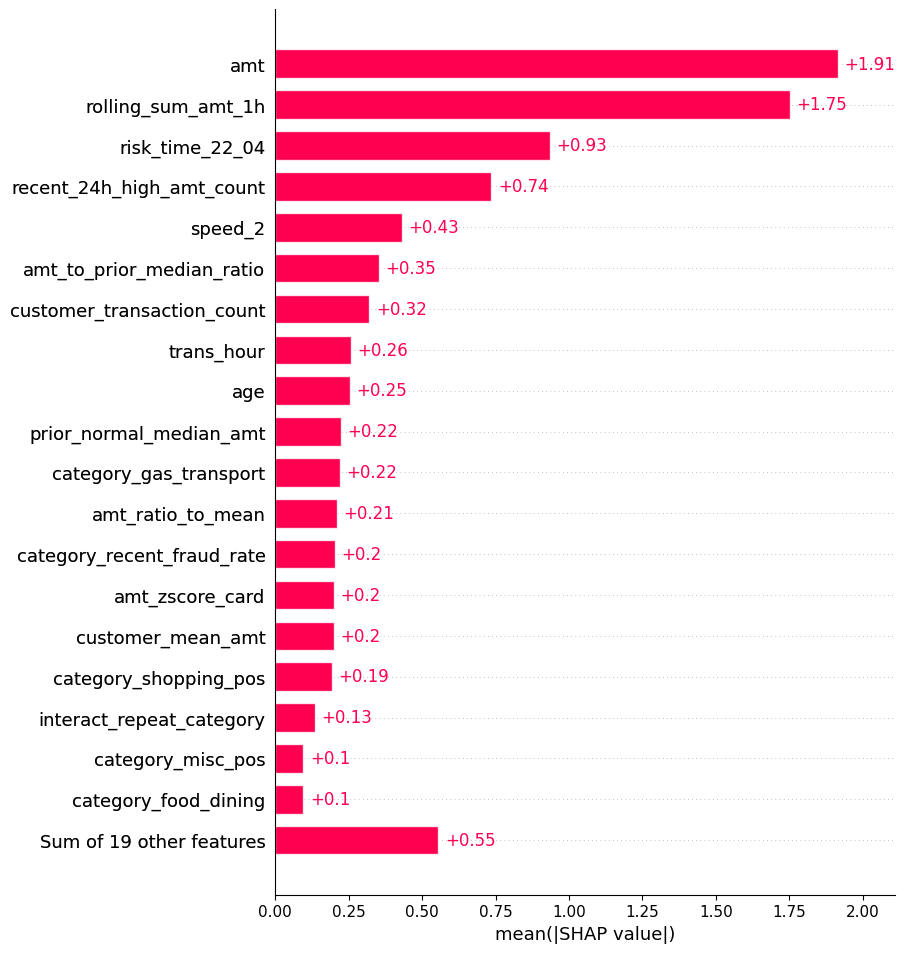

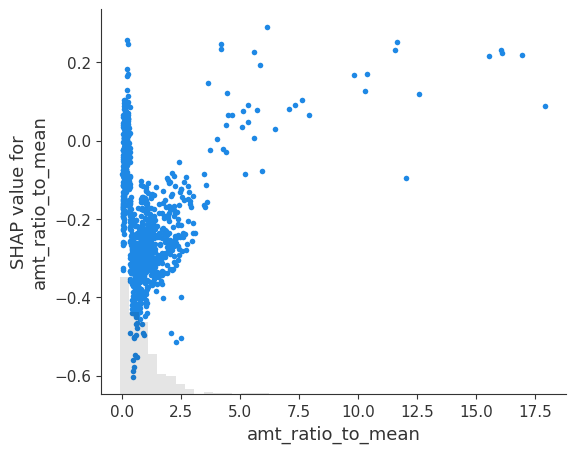

In [ ]:
# =====================================================
# SHAP 분석 (XGBoost + 최신 SHAP 버전)
# =====================================================

import shap
import matplotlib.pyplot as plt


# SHAP 분석용 데이터
X_shap = X_test.sample(
    1000,
    random_state=42
)


# =====================================================
# 1. Explainer 생성
# =====================================================
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer(
    X_shap
)




# =====================================================
# 3. SHAP Beeswarm Plot
#    변수 영향 방향 + 중요도
# =====================================================

shap.plots.beeswarm(
    shap_values,
    max_display=20
)


# =====================================================
# 4. SHAP Feature Importance
#    변수 중요도 순위
# =====================================================

shap.plots.bar(
    shap_values,
    max_display=20
)


# =====================================================
# 5. 특정 변수 영향 확인
#    (예: 금액 이상도)
# =====================================================

shap.plots.scatter(
    shap_values[:, "amt_ratio_to_mean"]
)

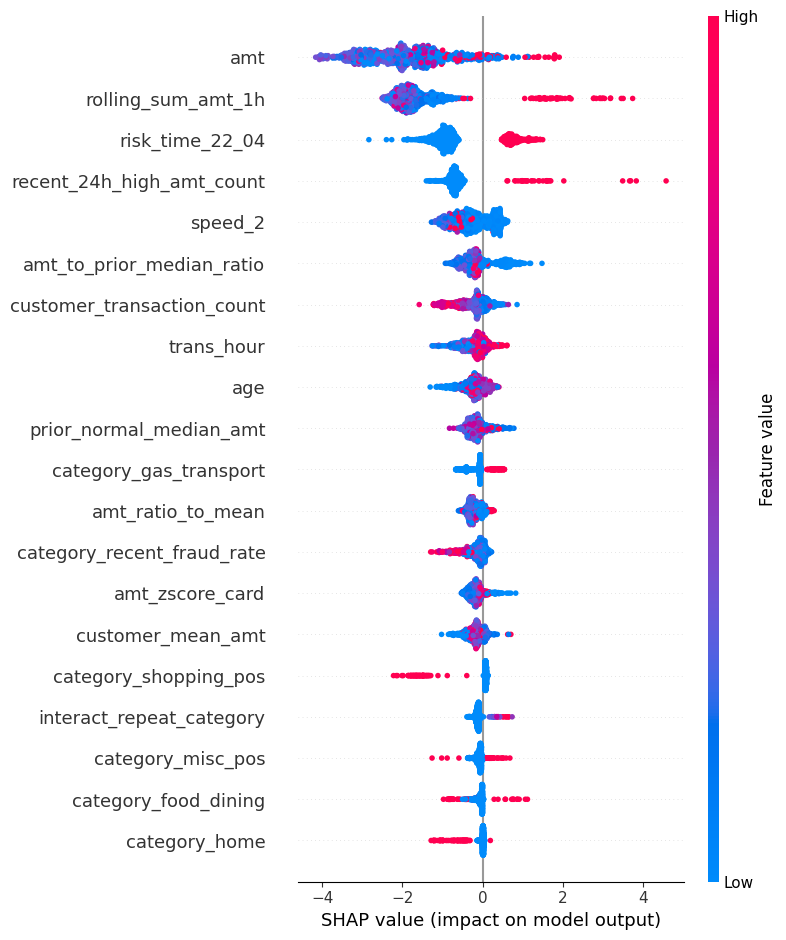

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20
)